# **FINTECH PROJECT - GROUP 13**

# **Risk-Based Recommender System for Active and Passive Portfolios Replicating**


### **Institution**: Politecnico di Milano
### **Coursework**:  FINTECH - A.Y. 2024-2025
### **Authors**:     Manfredi Giacomo, Pescotto Leonardo,Tarditi Andrea, Toia Nicolò, Torba Matteo

<br>


# Abstract

This project presents a comprehensive framework for a **Risk-Based Recommender System of Active and Passive Portfolios of Replica**, designed to personalize investment strategies while maintaining robust risk management. The solution combines two core elements: a **Recommender System** and a **Replica Portfolio Construction Engine**. The Recommender System uses supervised learning (Random Forests) to classify clients based on their profiles and investment objectives (Income or Accumulation), providing tailored portfolio suggestions. Parallelly, the Replica Engine constructs alternative investment strategies replicating benchmark indices (Equity, Bond, and LifeStrategy 80/20) using models such as **Equally Weighted portfolios, Elastic Net Regression (tuned via Optuna), Kalman Filters, and Ensemble Kalman Filters**.

A critical feature is the **Anomaly Detection module**, which separates two economically different signals: a **shock channel** based on returns / first differences and a complementary **level-regime channel** based on causal rolling level z-scores and drawdowns. Supervised (MLP and LSTM Classifiers) and one-class / semi-supervised (LSTM Autoencoder) models are used for the shock channel, while an Optuna-tuned MLP provides the level-regime signal. Signal-family selection is performed on validation data only. The selected risk signal overlays the replica strategies by moving risky positions to cash from the next executable period.

To bridge the gap between data science and practice, we developed a **web application** ([https://gm46.pythonanywhere.com/](https://gm46.pythonanywhere.com/)) that allows new clients to complete a brief questionnaire and receive real-time investment recommendations tailored to their risk profile and preferences.

Overall, this integrated approach demonstrates how machine learning, anomaly detection, and portfolio replication can be combined to create adaptive, personalized investment solutions. By uniting these methodologies, the project delivers a robust tool to support financial decision-making and align portfolio allocations with both market conditions and individual investor needs.

<br>
<br>


# Table of Contents

0. [Selection of the portfolio](#sec-0-ptf-sel)
1. [Introduction: Final Project – Group 13](#sec-1-introduction)
2. [Prediction](#sec-2-prediction)

    2.0 [Predictor Class Full Pipeline Overview](#sec-20-predictor-overview)

    2.1 [Setup and Data Loading and Dataset Preprocessing](#sec-21-predictor-setup)

    2.2 [Predictor Exploratory Data Analysis (EDA)](#sec-22-predictor-eda)

    2.3 [Predictor Joint Training & Evaluation](#sec-23-predictor-train)

    2.4 [Predictor Explanatory Part](#sec-24-predictor-expl)



3. [Replica](#sec-3-replica)

    3.0 [Replica Introduction - Data Loading and Preprocessing](#sec-30-replica-intro)

    3.1 [Portfolio Replica EDA](#sec-31-replica-eda)

    3.2 [Equally Weighted Portfolio Replication](#sec-32-replica-ewptf)

    3.3 [Elastic Net Portfolio Replication](#sec-33-replica-en)

    3.4 [Kalman Filter Portfolio Replication](#sec-34-replica-kf)

    3.5 [Ensemble Kalman Filter Portfolio Replication](#sec-35-replica-ekf)


4. [Anomaly Detection](#sec-4-anomaly-detection)

    4.0 [Anomaly Detection Introduction](#sec-40-anomaly-detection-introduction)

    4.1 [Anomaly Detection Dataloading and Preprocessing](#sec-41-anomaly-detection-dataloading-and-preprocessing)

    4.2 [Anomaly Detection EDA](#sec-42-anomaly-detection-eda)

    4.3 [MLP for Shock Anomaly Detection](#sec-43-mlp-for-anomaly-detection)

    4.3.1 [Simple MLP for Anomaly Detection](#sec-431-simple-mlp-for-anomaly-detection)

    4.3.2 [MLP with Optuna Hyperparameter Tuning for Anomaly Detection](#sec-432-mlp-with-optuna)
    
    4.4 [LSTM for Shock Anomaly Detection](#sec-44-lstm)

    4.4.1 [LSTM Autoencoder for One-Class / Semi-Supervised Anomaly Detection](#sec-441-lstm-autoencoder)

    4.4.2 [LSTM Classifier for Supervised Anomaly Detection](#sec-442-lstm-class)

    4.5 [Shock Detector Results Comparison](#sec-45-res-comp)

    4.6 [Complementary Level / Regime Anomaly Detection](#sec-46-level-regime)

5. [Replica and Anomaly Detection Combination - Active Risk Management](#sec-5-combination)

    5.1 [Discrete Approach](#sec-51-disc)

    5.2 [Fractional Weights](#sec-52-fw)


6. [Results](#sec-6-results)

7. [Conclusions](#sec-7-conclusions)

8. [Bibliography](#sec-8-bibliography)


---
<a id="sec-0-ptf-sel"></a>
# 0. Selection of the portfolio


Before building the predictor and the index replica, you must select the type of **target portfolio** to use in this study. This initial step is crucial as it determines the market segment and risk profile to be analyzed.

We offer three alternative portfolio configurations:

1) **Equity Portfolio**  
This configuration aims to replicate the performance of the `MXWO Index` (MSCI World Index). It represents a globally diversified basket of stocks, providing broad exposure to equity markets across various regions and sectors.

2) **Bond Portfolio**  
This portfolio replicates the `LEGATRUU Index`, a global bond index that reflects the performance of investment-grade fixed-income securities. It is suitable for investors seeking stability and lower risk compared to equity markets.

3)  **LifeStrategy 80/20 Portfolio**  
This balanced allocation combines 80% exposure to the `MXWO Index` and 20% exposure to the `LEGATRUU Index`, reflecting a traditional 80/20 equity-bond split (commonly referred to as LifeStrategy 80/20). It is designed to provide a moderate risk-return profile by blending growth from equities with the stability of bonds.

Use the interactive widgets below to select your desired portfolio configuration and confirm your choice. This will guide the subsequent data preparation, replication models, and performance analysis for your selected strategy.


In [1]:
# Install the required packages saved in requirements.txt
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import ipywidgets as widgets
from IPython.display import display

# Read the name of the selected portfolio
def get_selected_portfolio():
    selected_value = portfolio_selector.value
    if selected_value == 1:
        return "Portfolio Equity"
    elif selected_value == 2:
        return "Portfolio Bond"
    elif selected_value == 3:
        return "Portfolio LifeStrategy 80_20"
    elif selected_value == 0:
        portfolio_selector.value = 1  # Default to Portfolio Equity
        return "NOT A CHOICE"
    else:
        return None

# Create a small dropdown or radio‐button selector
opt = {
    "NOT A CHOICE": 0,
    "Portfolio Equity": 1,
    "Portfolio Bond": 2,
    "Portfolio LifeStrategy 80_20": 3,
}

# Radio buttons for portfolio selection
portfolio_selector = widgets.RadioButtons(
    options=[
        ("NOT A CHOICE", 0),
        ("Portfolio Equity", 1),
        ("Portfolio Bond", 2),
        ("Portfolio LifeStrategy", 3),
    ],
    description="Scegli:",
)

# Button to confirm the selection
submit_btn = widgets.Button(description="Conferma")

# Output widget to display the result
out = widgets.Output()

# Execute the code when the button is clicked
def on_submit(b):
    with out:
        selected_flag = portfolio_selector.value
        print(f"Current Selection:", get_selected_portfolio())

# Connect the button click event to the function
submit_btn.on_click(on_submit)

# Display all widgets
display(portfolio_selector, submit_btn, out)


RadioButtons(description='Scegli:', options=(('NOT A CHOICE', 0), ('Portfolio Equity', 1), ('Portfolio Bond', …

Button(description='Conferma', style=ButtonStyle())

Output()

In [3]:
from IPython.display import Javascript

selected_flag = portfolio_selector.value
print("Saved Flag:", get_selected_portfolio())

if selected_flag == 0:
    # Automatically select "Equity Portfolio"
    selected_flag = 1
    print(f"{get_selected_portfolio()} was automatically selected.")

    # Display a real browser alert window
    display(Javascript('''
        alert("Equity Portfolio was automatically selected. If you want to replicate other portfolios, express your selection in the dropdown menu below the sixth cell.");
    '''))


Saved Flag: NOT A CHOICE
Portfolio Equity was automatically selected.


<IPython.core.display.Javascript object>

---
<a id="sec-1-introduction"></a>
# 1. Introduction: Final Project – Group 13

This project centers on developing a comprehensive **Risk-Based Recommender System of Active Portfolios of Replica**, integrating modern data-driven methods to create robust and personalized investment strategies. The main idea combines two complementary components:

- The first component is a **Recommender System**, which classifies clients according to their demographic and behavioral profiles and identifies their primary investment needs - **Income** or **Accumulation**. This system uses supervised learning techniques, including Random Forest Classifiers, to predict the client’s preferred investment strategy and to map these preferences to suitable portfolios, balancing potential returns with the investor’s risk profile.

- The second component involves **Replica Portfolio Strategies** that seek to replicate the performance of selected target indices using a combination of derivative-based underlyings. We focus on three main portfolio archetypes - an Equity Portfolio replicating the MSCI World Index, a Bond Portfolio tracking the Bloomberg Global Aggregate Index (LEGATRUU), and a Balanced LifeStrategy 80/20 Portfolio. The replication strategies employ diverse methods: an **Equally Weighted baseline**, **Elastic Net Regression** (with Optuna hyperparameter tuning to optimize portfolio weights), and dynamic models like the **Kalman Filter** and **Ensemble Kalman Filter**. These methods ensure robust tracking of benchmark indices while minimizing tracking error and transaction costs.

    A key innovation in our project is the integration of a **Financial Anomaly Detection** layer with two complementary definitions of abnormality. The **shock channel** works on stationary market changes (log returns and yield differences), while the **level-regime channel** measures whether the current market state is unusually far from its recent causal history through rolling level z-scores and drawdowns. Supervised MLP/LSTM classifiers and a one-class / semi-supervised LSTM autoencoder are evaluated on the shock representation, and a tuned MLP is used as the complementary level-regime detector. Model and signal-family choices are made on validation data only. The selected signal is then used to move the replica to cash from the next executable period.

The synergy of these components enables an **integrated approach**: predictive models classify clients and select an appropriate portfolio replica strategy, while anomaly detection overlays an active risk management layer that adapts the portfolio’s allocation in real-time to evolving market conditions. This dynamic framework aims to deliver tailored investment solutions that combine personalization with robust risk control.

To enhance practical deployment, we developed a **web application** accessible at [https://gm46.pythonanywhere.com/](https://gm46.pythonanywhere.com/). This platform invites new clients to complete a brief questionnaire and immediately receive personalized investment recommendations generated by our system, bridging the gap between data science and real-world wealth management advisory.

In summary, our project demonstrates how combining **machine learning-based classification, index replication techniques, and anomaly detection** can create an advanced, risk-aware investment advisory tool. This integrated pipeline enables personalized portfolio strategies that respond dynamically to both investor needs and market stress events, supporting informed decision-making in modern financial markets.

<br>

<br>


---
<a id="sec-2-prediction"></a>
# 2. Prediction


<a id="sec-20-predictor-overview"></a>
## 2.0 Predictor Class Full Pipeline Overview

This section introduces the **Predictor Class**, the core of our **Recommender System** component. This class implements a robust supervised learning pipeline designed to identify two key financial investment needs for clients:  
- **AccumulationInvestment**  
- **IncomeInvestment**

The objective is to provide accurate, data-driven predictions that can be seamlessly integrated into the broader recommendation process. The pipeline is tailored for financial data, ensuring both **interpretability** for business use and **flexibility** for extension and future adaptation.

The Predictor Class begins with structured data sourced from an Excel workbook containing three primary sheets:  
- **Needs**: Client behavioral and demographic data along with binary investment need labels  
- **Products**: Metadata about available financial products  
- **Metadata**: Variable dictionary for readability and summary tables

In the **preprocessing phase**, transformations are applied to stabilize data distributions. These include a log transform for **Wealth** and a power transform for **Income**, followed by Min-Max normalization for numerical variables like **Age**, **FamilyMembers**, **RiskPropensity**, and the transformed income and wealth indicators.

The **Exploratory Data Analysis (EDA)** component of the class provides visualizations to understand class balance, variable distributions, correlations, and feature relationships. This helps build intuition about the data and ensures that subsequent models are built on solid ground.

Model training is split into two complementary tasks:  
- **Single target modeling** with hyperparameter tuning (using **Optuna**) for the best Random Forest configuration.  
- **Joint target modeling** using a MultiOutputClassifier to capture the potential overlap or divergence in predicting both investment needs simultaneously.

Custom evaluation metrics, including a penalty score reflecting the asymmetric costs of misclassification in financial contexts, are integrated to align model output with business objectives. Once trained, the model supports real-time predictions for new clients, with transformations and threshold tuning baked into the inference process.

The final **artifacts** include stored models, threshold dictionaries, and clean tables of validation and test metrics, ready for integration into the larger pipeline. The class design prioritizes modularity and scalability, supporting future experimentation or deployment as part of the personalized investment advisory system.



<!-- ## Goal
This module implements a comprehensive *supervised learning pipeline* to jointly predict two binary financial needs:
- *AccumulationInvestment*
- *IncomeInvestment*

The approach emphasizes business interpretability, robust preprocessing, customized evaluation, and flexible inference, all wrapped into a reusable Python class.

---

## 1. Data Input & Variable Overview
The class loads structured data from an Excel file containing three sheets:
- **Needs**: behavioral and demographic client features + binary labels
- **Products**: product metadata (descriptive only)
- **Metadata**: variable dictionary used for readable summaries

A profiler generates summary tables (mean, std, min, max, missing count, description) for both Needs and Products.

---

## 2. Feature Engineering
Two transformations are applied to numerical features to stabilize distributions:
- Wealth → *log1p* transform (to reduce right-skew)
- Income → *power transform* with exponent 0.3 (approximate Box-Cox)

Then, a *Min-Max normalization* is applied to all key numeric predictors:
- Age, FamilyMembers, RiskPropensity
- Log_Wealth, Power_Income_0.3

The original Wealth and Income features are dropped.

---

## 3. Exploratory Data Analysis (EDA)
The eda() method generates plots to understand:
- Class balance for both targets
- Distributional normality (histograms + Q-Q plots)
- Correlation heatmaps
- Boxplots and violin plots grouped by target
- Joint distributions of income and wealth
- Feature distributions across class labels

---

## 4. Custom Evaluation Metric
A *custom penalty score* is defined using a cost_map_single, which captures asymmetric misclassification costs tailored to the business context. This is computed for all model evaluations alongside standard metrics (accuracy, precision, recall, F1).

---

## 5. Model Training – Single Label
For individual target modeling:
- *Stratified train-test split* (default 80/20)
- *Optuna optimization* searches the best hyperparameters (RandomForest) using F1 as the CV objective
- *Cross-validation metrics* (5-fold) are collected
- *Threshold τ tuning* selects the decision threshold that maximizes F1 (or minimizes custom penalty)
- Final model is evaluated on the hold-out test set

---

## 6. Model Training – Joint Targets
The train_evaluate_joint() method:
- Trains a *MultiOutputClassifier* using the same base model
- Performs *K-fold CV* and collects *out-of-fold probabilities* for each label
- Tunes a separate *τ threshold per target* based on validation results
- Trains a final joint model on all training data
- Evaluates it on the test set and saves:
  - A summary report of mean ± std across folds
  - A test report with final metrics
  - Optimal thresholds (tau_dict)
  - The full model to disk via joblib

---

## 7. Prediction on New Clients
The class supports real-time prediction for new client records via:
- pred_new_client() → for a single target
- pred_new_client_joint() → for both targets simultaneously

These methods:
- Apply all saved transformations (log, power, scaling)
- Clip inputs to match training data bounds
- Output both the predicted label and its associated probability
- Use learned τ thresholds for final decision

---

## 8. Optuna Integration
study_optuna() handles:
- Hyperparameter tuning of the RandomForest using Stratified K-Fold CV
- F1 score as the target metric
- Persistent storage of the study in SQLite to resume or inspect
- Optional optimization history plot visualization

---

## 9. Output & Artifacts
- Clean CV and test set metric tables (print-ready with tabulate)
- Stored joint model (.joblib) and thresholds (tau_dict.json)
- Modular and scalable design for experimentation or deployment

<!-- ---

## Summary
This class combines preprocessing, feature engineering, model tuning, validation, evaluation, and explainability into a unified and reusable object-oriented structure. It is ready to be extended to:
- Additional targets
- Alternative models (e.g., XGBoost, LightGBM)
- Model interpretability tools (already partially integrated via SHAP/plot functions) -->

<br>

<br>


<a id="sec-21-predictor-setup"></a>
## 2.1 Setup and Data Loading and Dataset Preprocessing

- Imports the `Predictor` helper module and `PortfolioRecommender`.

- Initializes a **Random Forest Classifier** for prediction tasks. Random Forest Classifier is chosen for its **robustness**, ability to **handle high-dimensional data**, and **strong performance** on tabular datasets with mixed variable types. It reduces overfitting by aggregating predictions from multiple decision trees, leading to better generalization and more stable results.

- Loads the **Needs**, **Products**, and **Metadata** datasets from `Dataset2_Needs.xls`.

- **Preprocess** the dataset


In [4]:
# Helper module import
import sys
import os
import pandas as pd

# Get the current working directory
current_dir = os.getcwd()

# Define the relative path to the helper directory
helper_dir = os.path.join(current_dir, "Predictor")

# Add the helper directory to sys.path if not already there
if helper_dir not in sys.path:
    sys.path.append(helper_dir)

from Predictor import Predictor
from sklearn.ensemble import RandomForestClassifier
from nba import PortfolioRecommender


In [5]:
# Inizialize the Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)


In [6]:
# Import the dataset
# Dataset for Prediction
path_BC2 = 'Dataset2_Needs.xls'
# Get current working directory
current_dir = os.getcwd()
# Add the path to the dataset
file_path = os.path.join(current_dir, "Datasets", path_BC2)

# Load the dataset
needs_df = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')


### Preprocessing Steps in `Predictor` Initialization

- The `ID` column is removed from `needs_df` to exclude it from further processing.
- Summaries for `needs_df` and `products_df` are generated using `create_variable_summary()`, giving an overview of variable types and missing values.
- A **logarithmic transformation** is applied to `Wealth`, resulting in a new variable `Log_Wealth`.
- A **power transformation** (exponent 0.3) is applied to `Income`, generating `Power_Income_0.3`.
- Normality tests (Shapiro-Wilk and Kolmogorov-Smirnov) are performed on `Power_Income_0.3` to assess distribution.
- The original `Wealth` and `Income` columns are removed.
- Selected numerical variables (`Age`, `FamilyMembers`, `RiskPropensity`, `Log_Wealth`, `Power_Income_0.3`) are **Min-Max scaled** to [0, 1] range for uniformity.
- The transformed dataset is ready for modeling.


In [7]:
# Initialize the Predictor classs
pred = Predictor(model, needs_df, products_df, metadata_df)


NEEDS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
Age,"Age, in years",55.25,11.97,0,18.00,97.00
Gender,"Gender (Female = 1, Male = 0)",0.49,0.50,0,0.00,1.00
FamilyMembers,Number of components,2.51,0.76,0,1.00,5.00
FinancialEducation,Normalized level of Financial Education (estimate),0.42,0.15,0,0.04,0.90
RiskPropensity,Normalized Risk propensity from MIFID profile,0.36,0.15,0,0.02,0.88
Income,N/A,62.99,44.36,0,1.54,365.32
Wealth,Wealth (thousands of euros); sum of investments and cash accounts,93.81,105.47,0,1.06,2233.23
IncomeInvestment,Boolean variable for Income investment; 1 = High propensity,0.38,0.49,0,0.00,1.00
AccumulationInvestment,Boolean variable for Accumulation/growth investment; 1 = High propensity,0.51,0.50,0,0.00,1.00



PRODUCTS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
IDProduct,Product description,6.00,3.32,0,1.00,11.00
Type,"1 = Accumulation product, 0 = Income product",0.64,0.50,0,0.00,1.00
Risk,Normalized Synthetic Risk Indicator,0.43,0.24,0,0.12,0.88


Shapiro-Wilk test for Power_Income_0.3: Statistic=0.9988864806036369, p-value=0.0018805509981543013
Power_Income_0.3 does not follow a normal distribution (Shapiro-Wilk test).
KS test for Power_Income_0.3: Statistic=0.011124622387602326, p-value=0.5621823732270469
Power_Income_0.3 follows a normal distribution (KS test).

Shapiro-Wilk test for Power_Income_0.3: Statistic=0.9988864806036369, p-value=0.0018805509981543013


<a id="sec-22-predictor-eda"></a>
## 2.2 Predictor Exploratory Data Analysis (EDA)

This subsection performs exploratory data analysis on the **transformed dataset**, including:

- Histograms of categorical targets for class balance.
- Correlation matrix of normalized numeric variables.
- Histograms and QQ plots for log-transformed and power-transformed numeric features.
- Boxplots and violin plots to visualize numeric features by target categories.
- Joint distribution of key numeric variables (`Power_Income_0.3` and `Log_Wealth`).
- Multiple violin plots and QQ plots for each numeric feature.

These visualizations help understand variable distributions, correlations, and feature-target relationships.


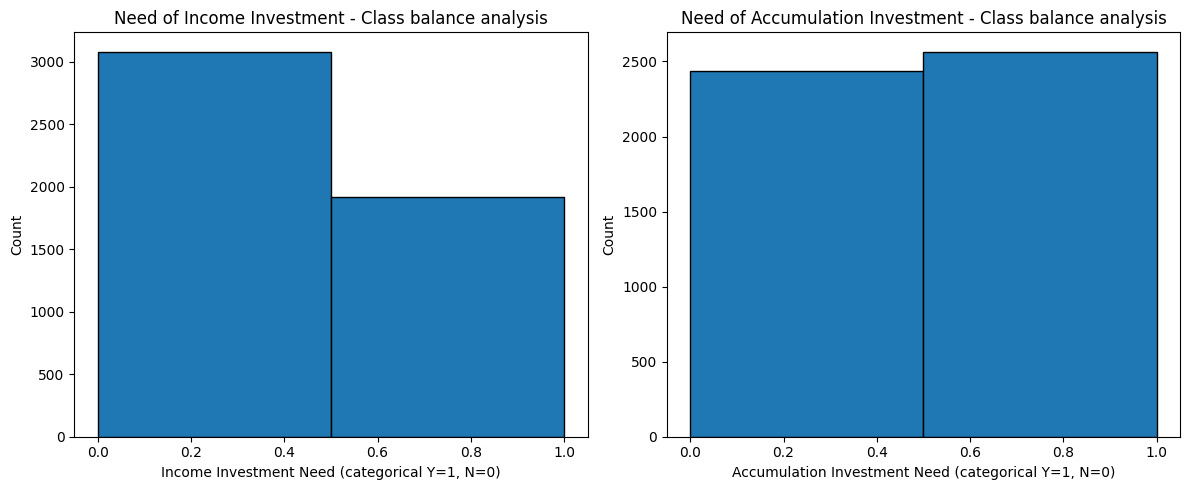

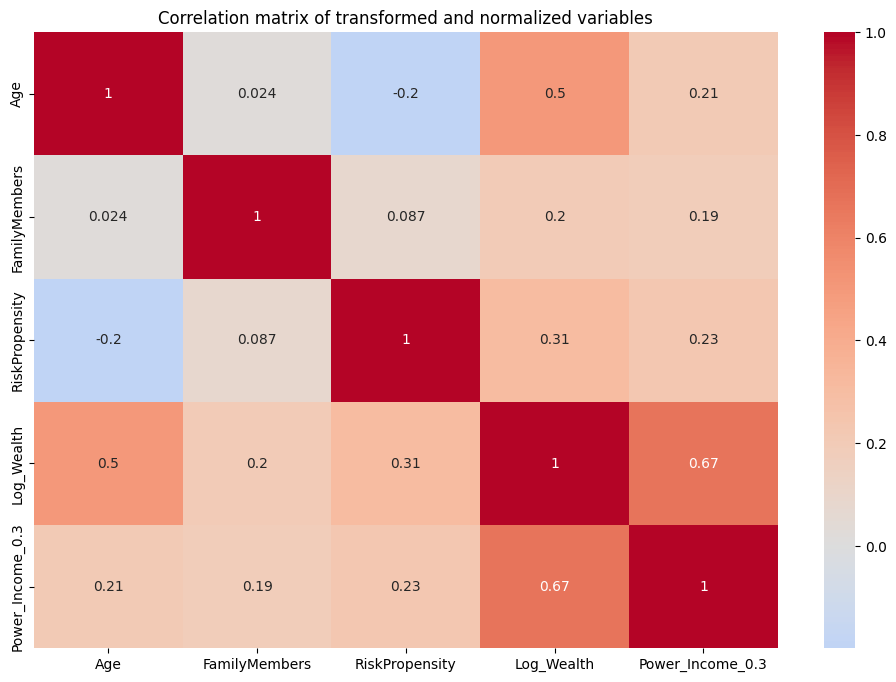

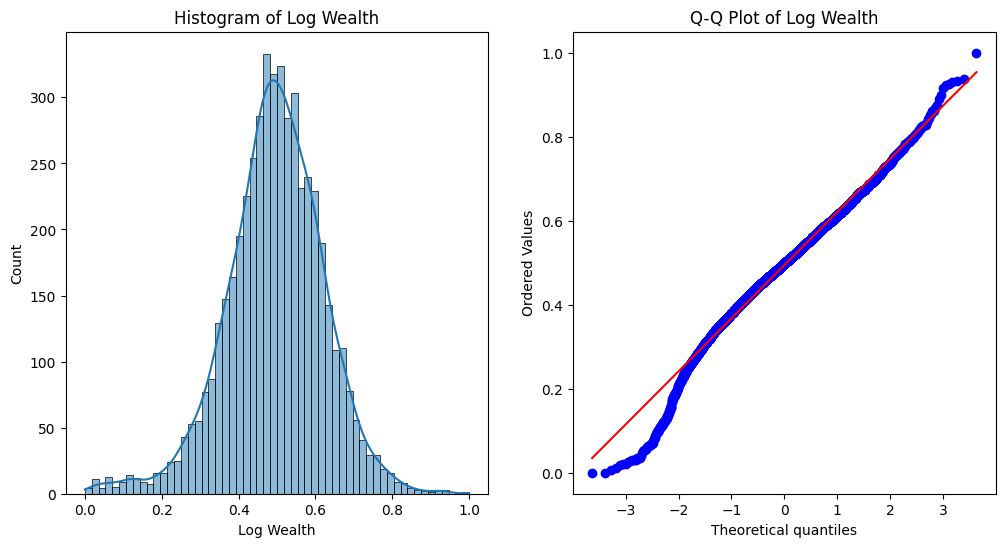

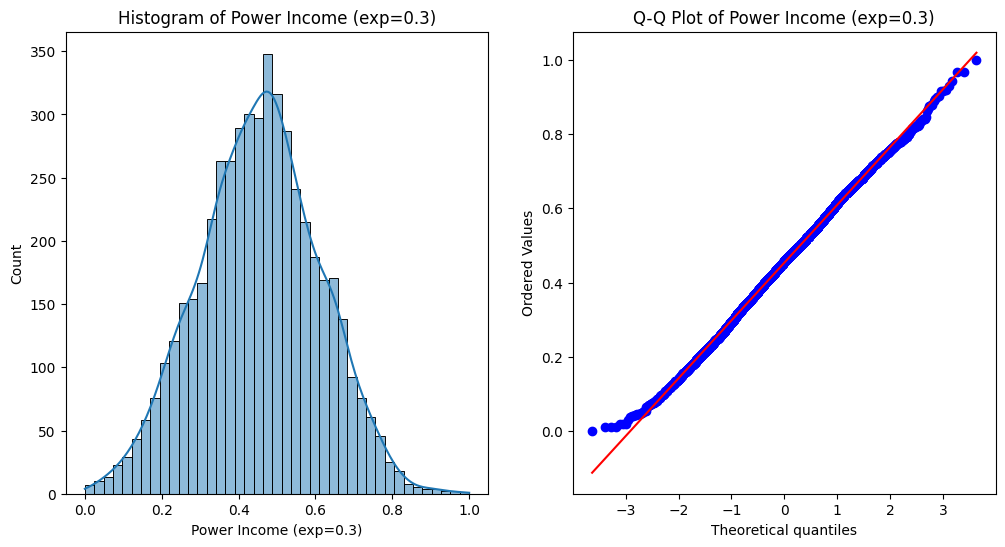

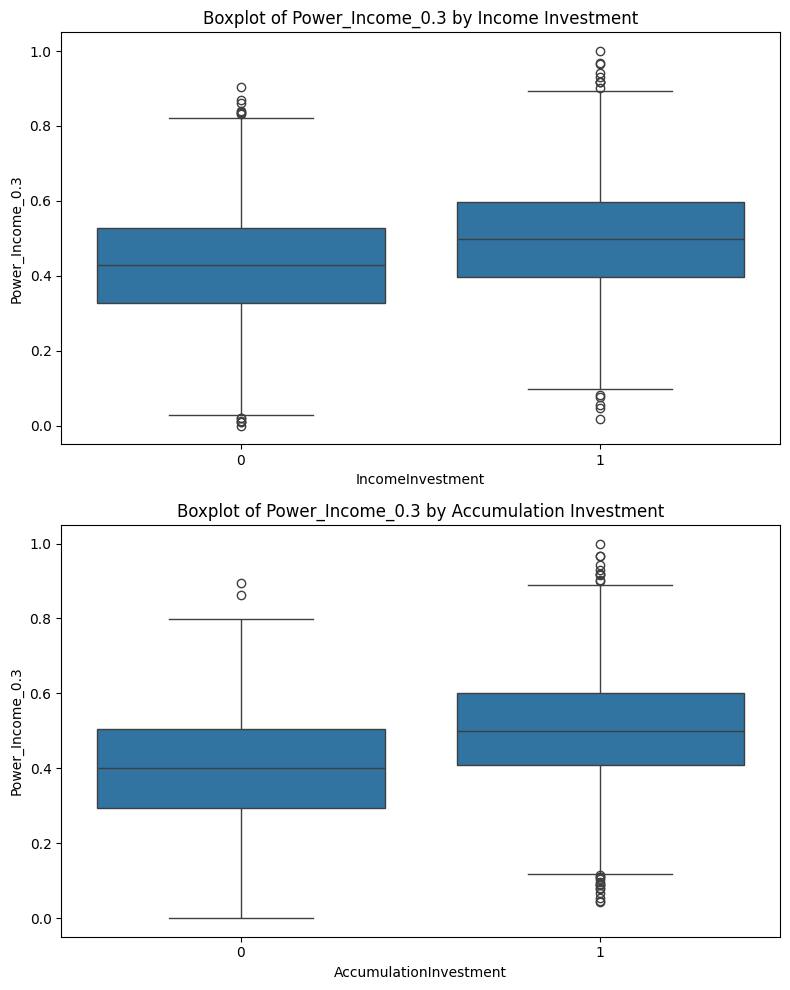

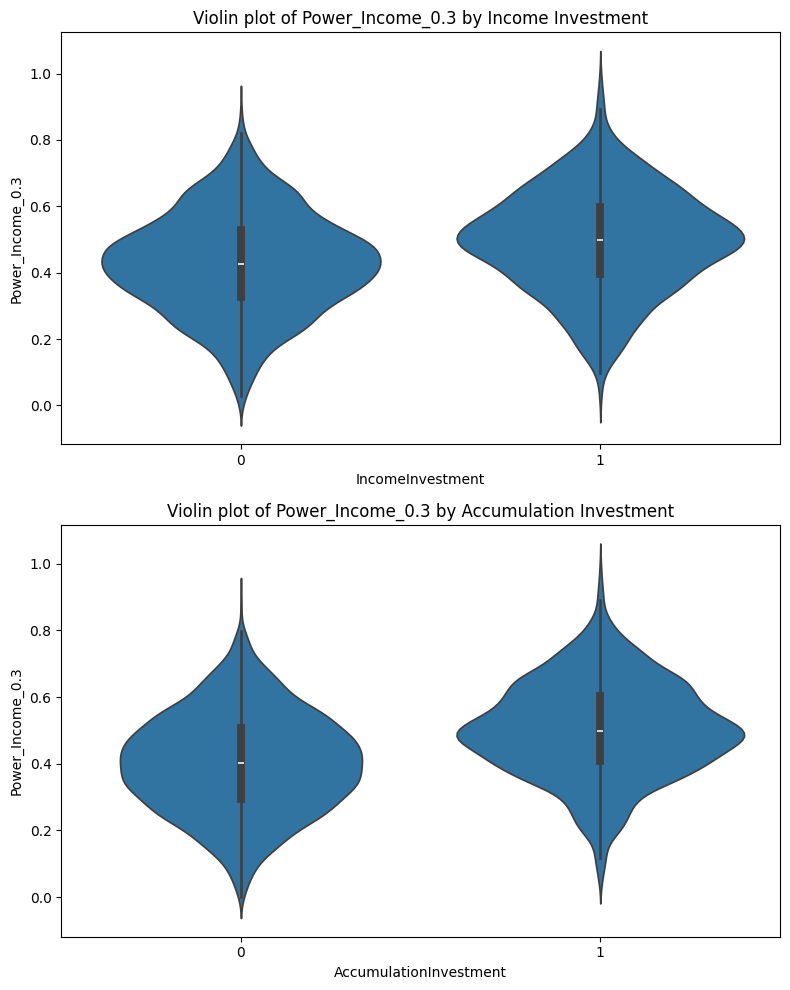

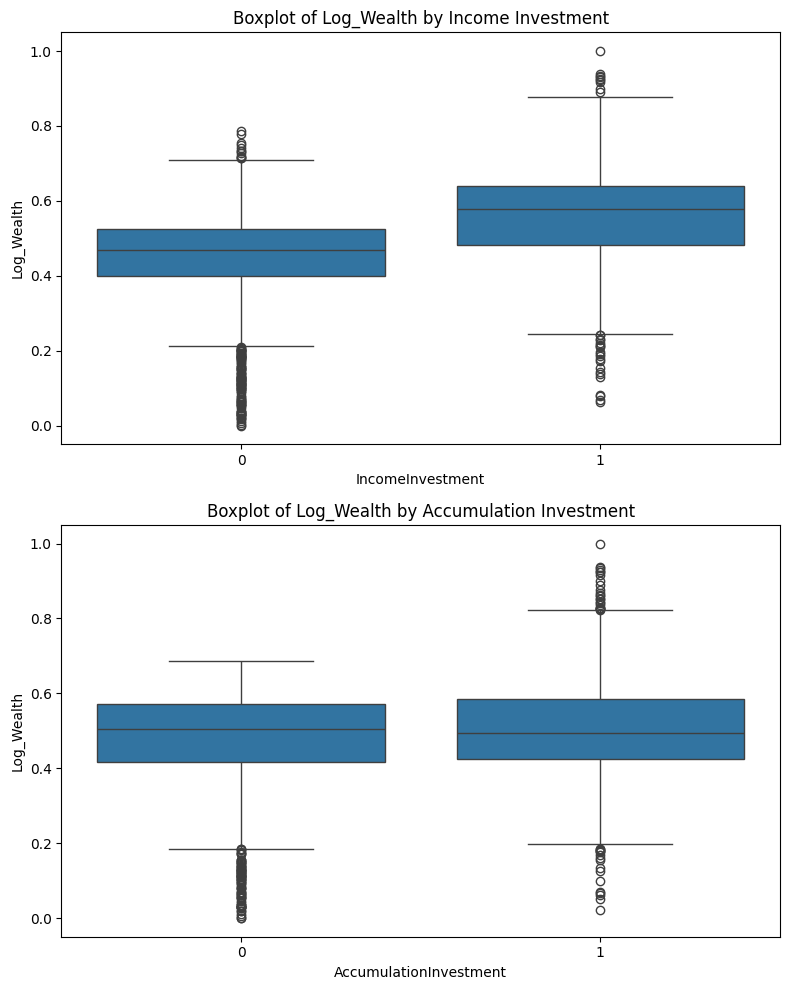

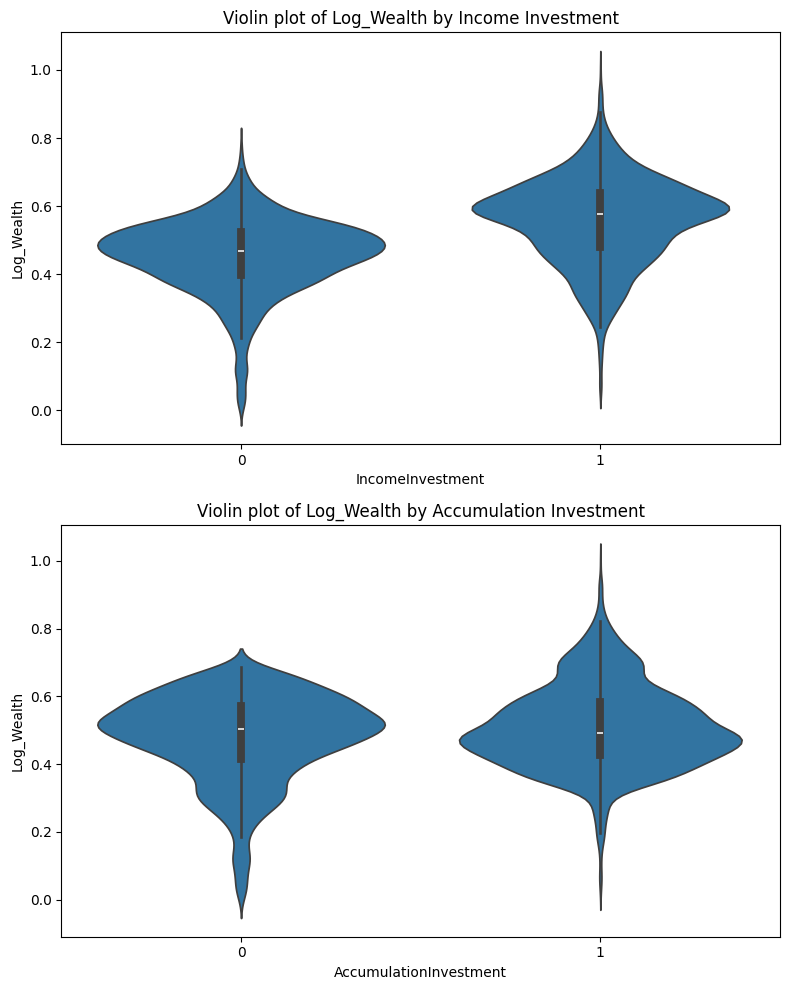

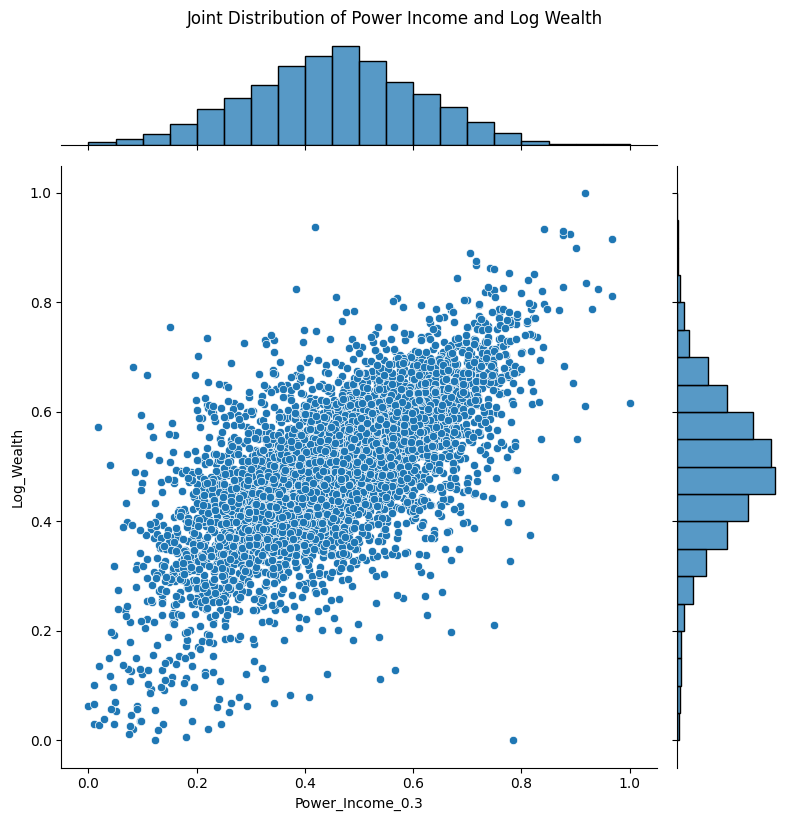

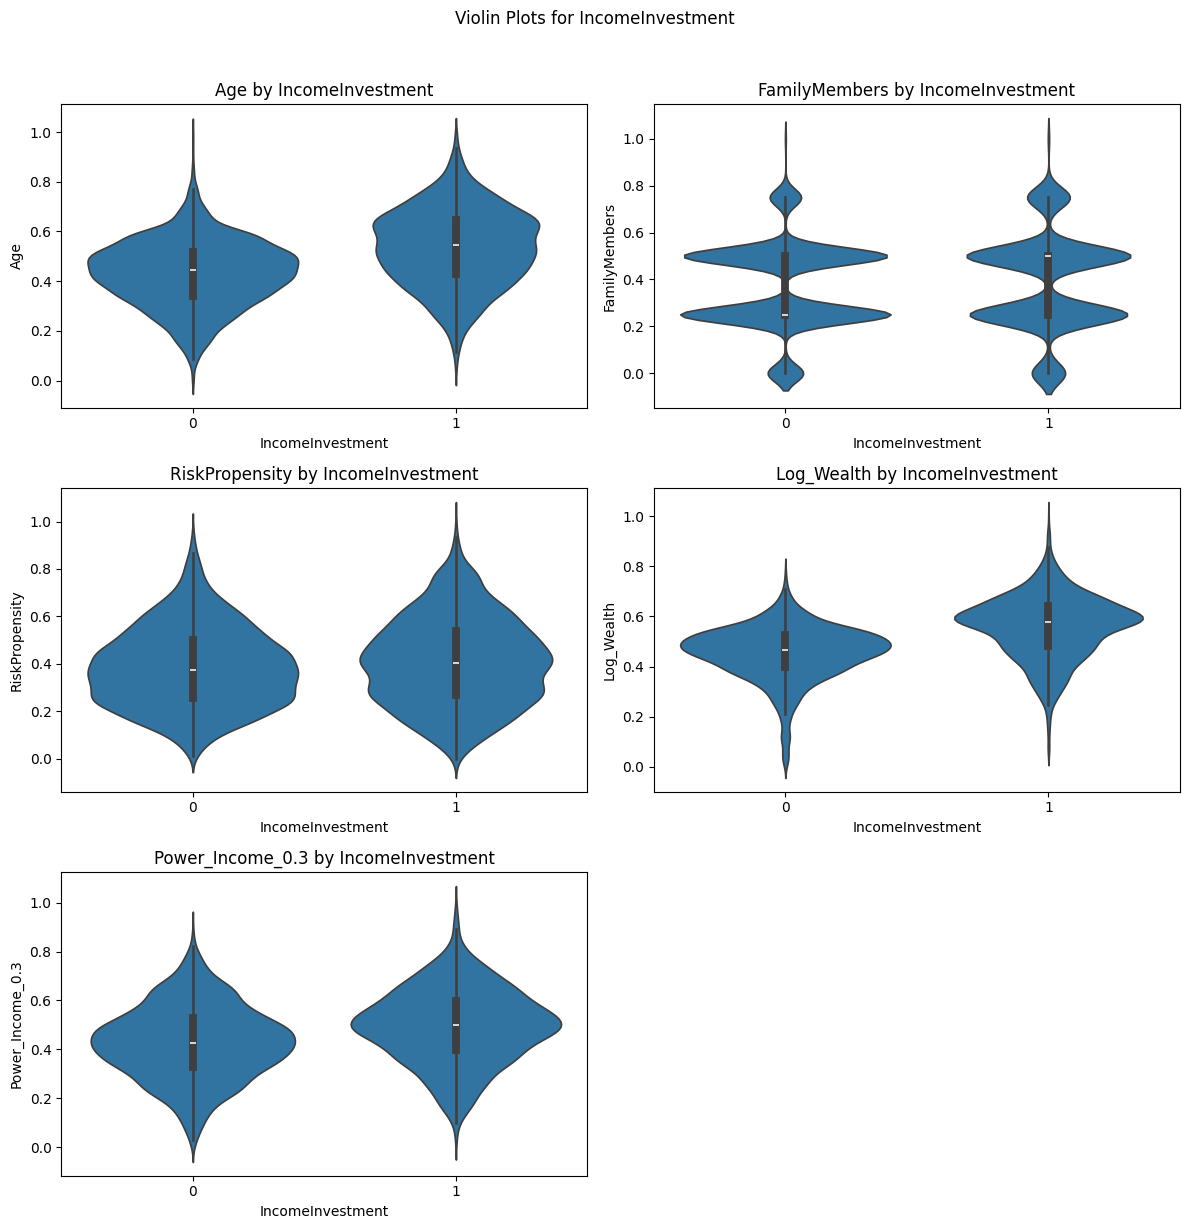

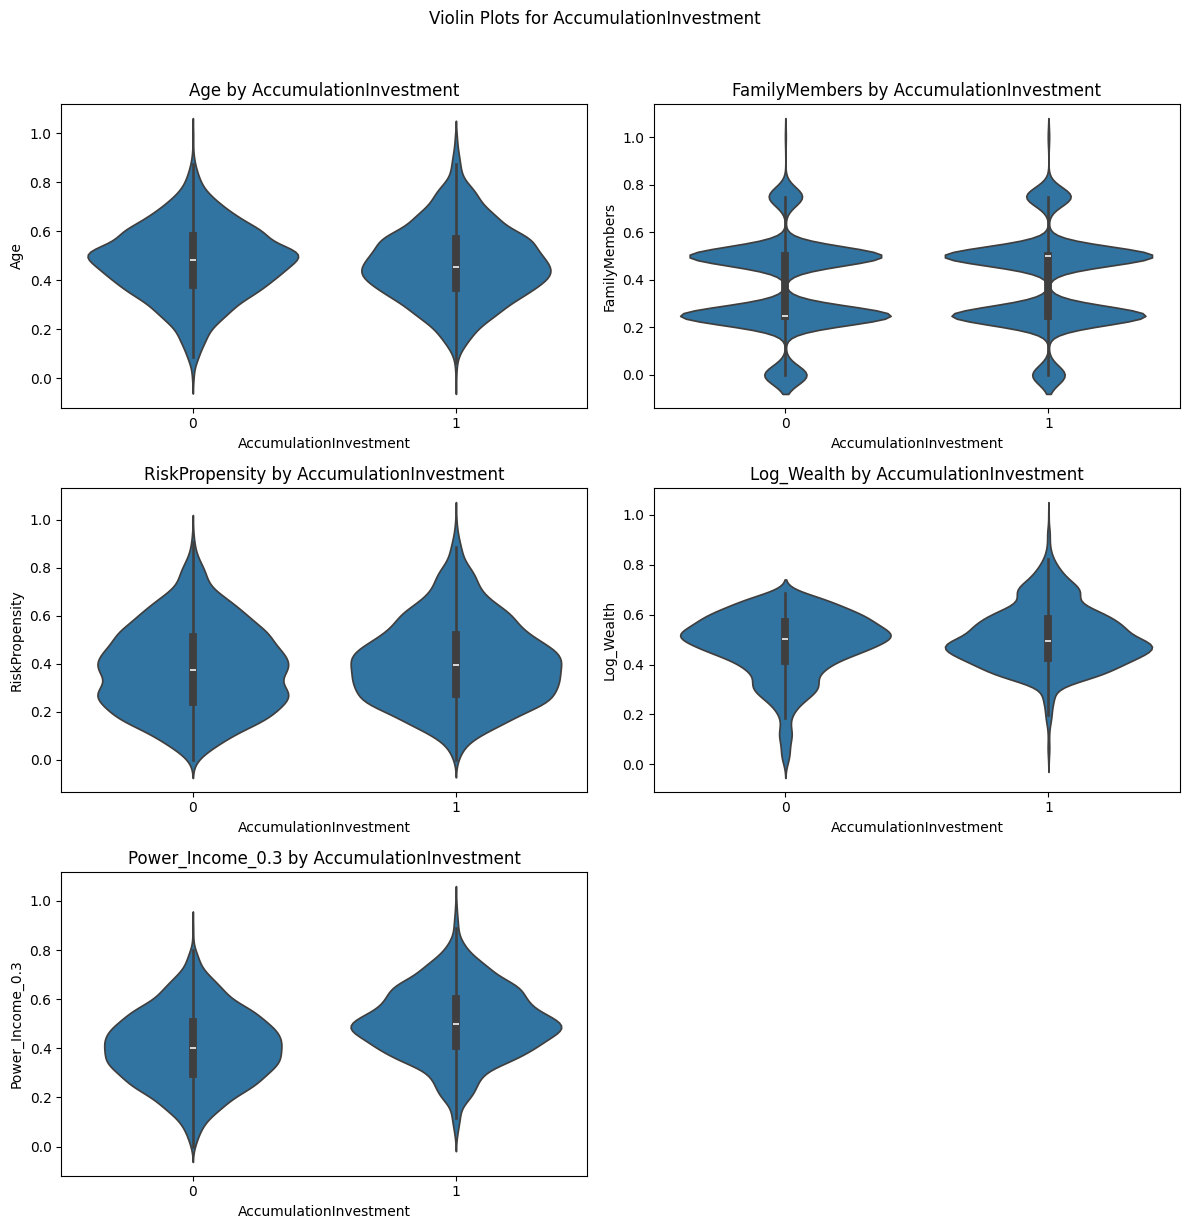

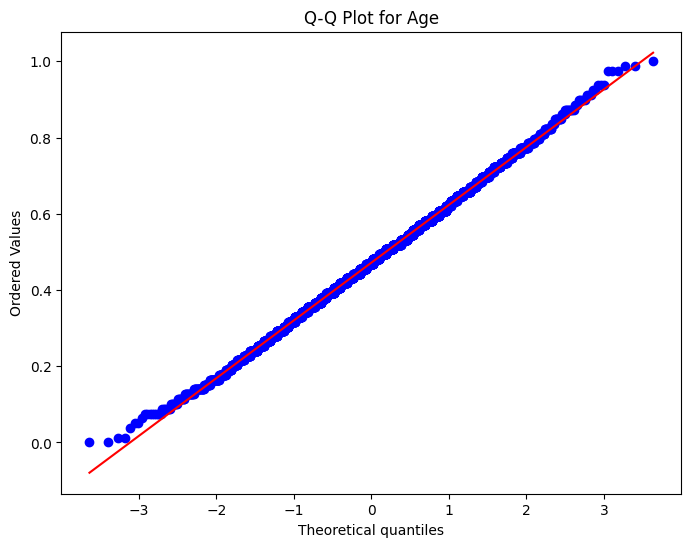

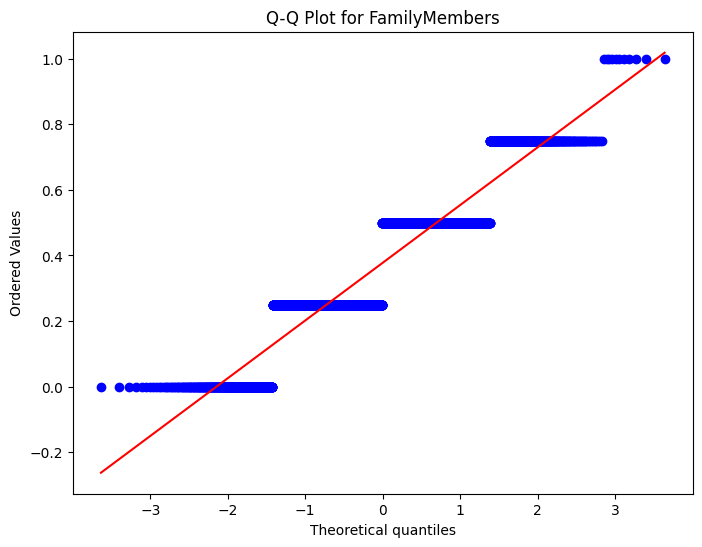

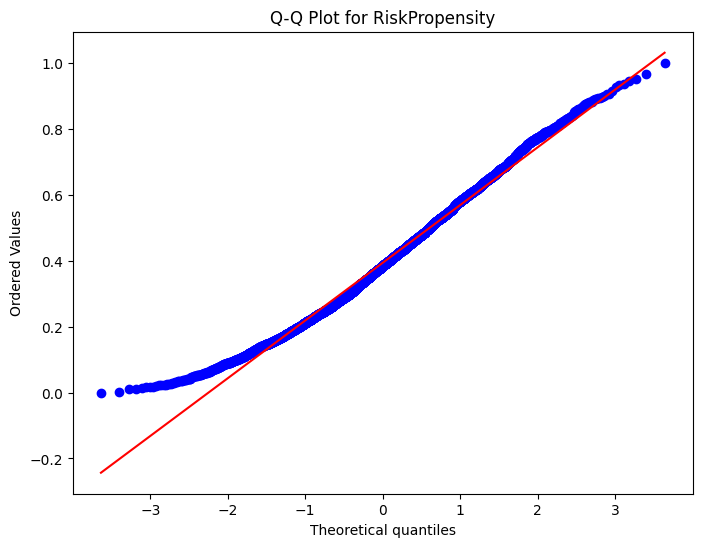

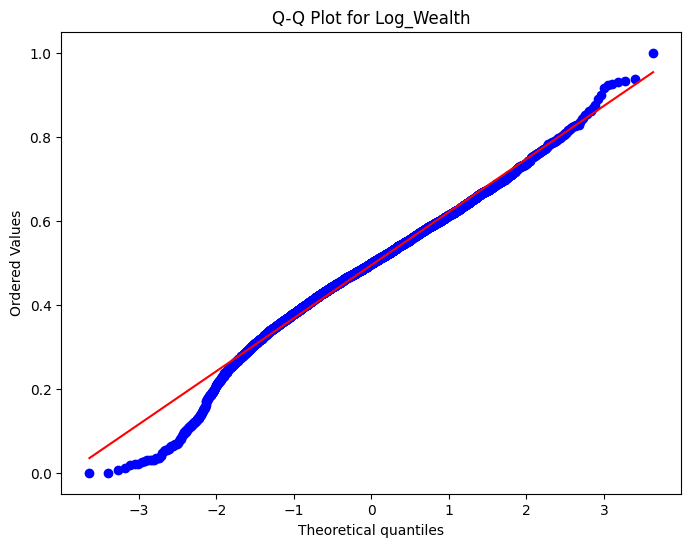

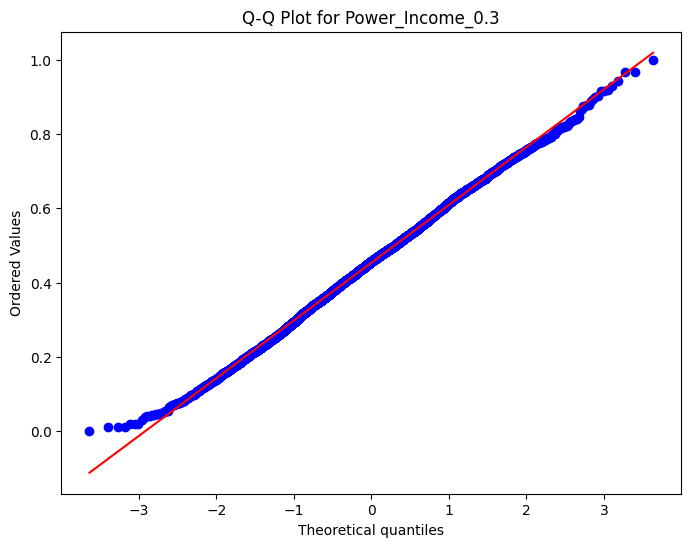

In [8]:
# Peform the EDA
pred.eda()


<a id="sec-23-predictor-train"></a>
## 2.3 Predictor Joint Training & Evaluation

This step jointly trains and evaluates the **multi-output classifier** for the target variables (`IncomeInvestment` and `AccumulationInvestment`) using:

- Cross-validation for robust performance estimation.
- Custom threshold (`τ`) selection to fine-tune binary classification decisions.
- Test set evaluation to assess generalization performance.
- Model and thresholds are saved for future predictions.


Optimal τ for AccumulationInvestment: 0.494
Optimal τ for IncomeInvestment: 0.515

Random Forest - AccumulationInvestment
+---+----------------+---------+--------+----------+
|   |     Metric     | CV Mean | CV Std | Test Set |
+---+----------------+---------+--------+----------+
| 0 |    Accuracy    |  0.791  | 0.025  |   0.8    |
| 1 |   Precision    |  0.833  | 0.017  |   0.84   |
| 2 |     Recall     |  0.742  | 0.035  |  0.751   |
| 3 |       F1       |  0.785  | 0.027  |  0.793   |
| 4 | Custom Penalty |  0.144  | 0.018  |  0.138   |
+---+----------------+---------+--------+----------+

Random Forest - IncomeInvestment
+---+----------------+---------+--------+----------+
|   |     Metric     | CV Mean | CV Std | Test Set |
+---+----------------+---------+--------+----------+
| 0 |    Accuracy    |  0.803  | 0.015  |  0.801   |
| 1 |   Precision    |  0.83   | 0.017  |   0.84   |
| 2 |     Recall     |  0.615  | 0.024  |  0.591   |
| 3 |       F1       |  0.706  | 0.016  |  0.693 

<Figure size 600x600 with 0 Axes>

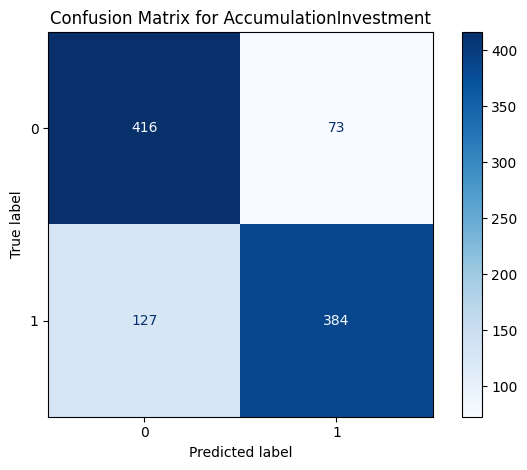

<Figure size 600x600 with 0 Axes>

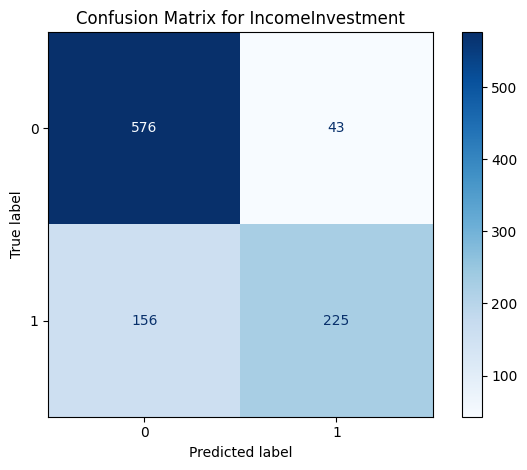

In [9]:
cv_report, test_report, tau_dict = pred.train_evaluate_joint()


<a id="sec-24-predictor-expl"></a>
## 2.4 Predictor Explanatory Part

Generates visual **SHAP** and **LIME** explanations for each target variable.  
- SHAP plots highlight feature importance and impacts across the test dataset.  
- LIME explanations provide instance-level interpretability for individual predictions.



Explaining target: AccumulationInvestment


<Figure size 1000x800 with 0 Axes>

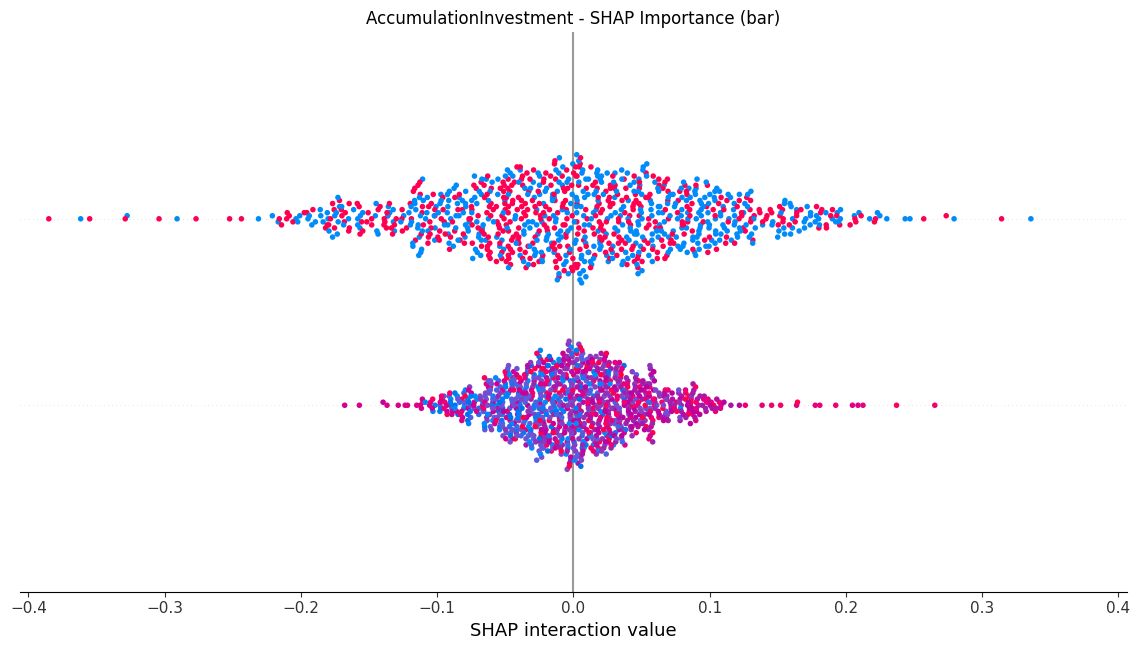

<Figure size 1000x800 with 0 Axes>

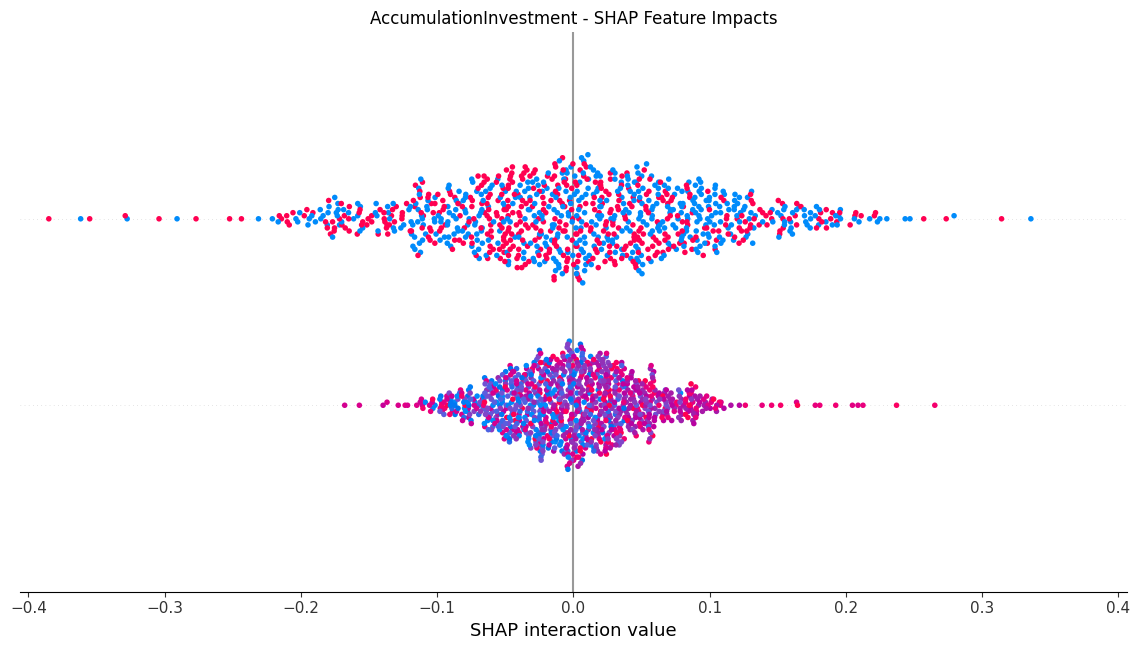

c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


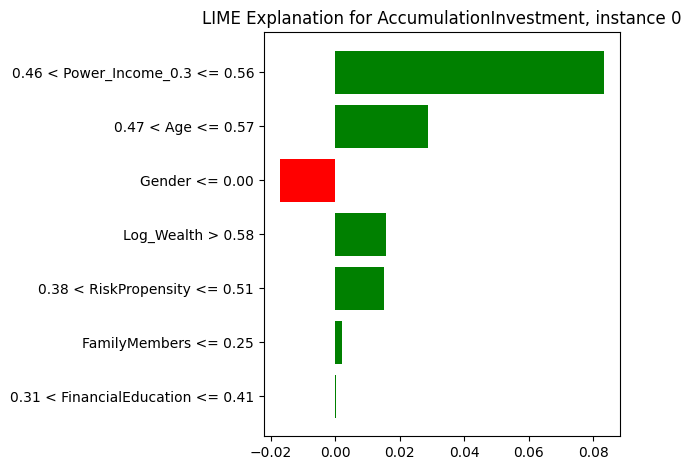


Explaining target: IncomeInvestment


<Figure size 1000x800 with 0 Axes>

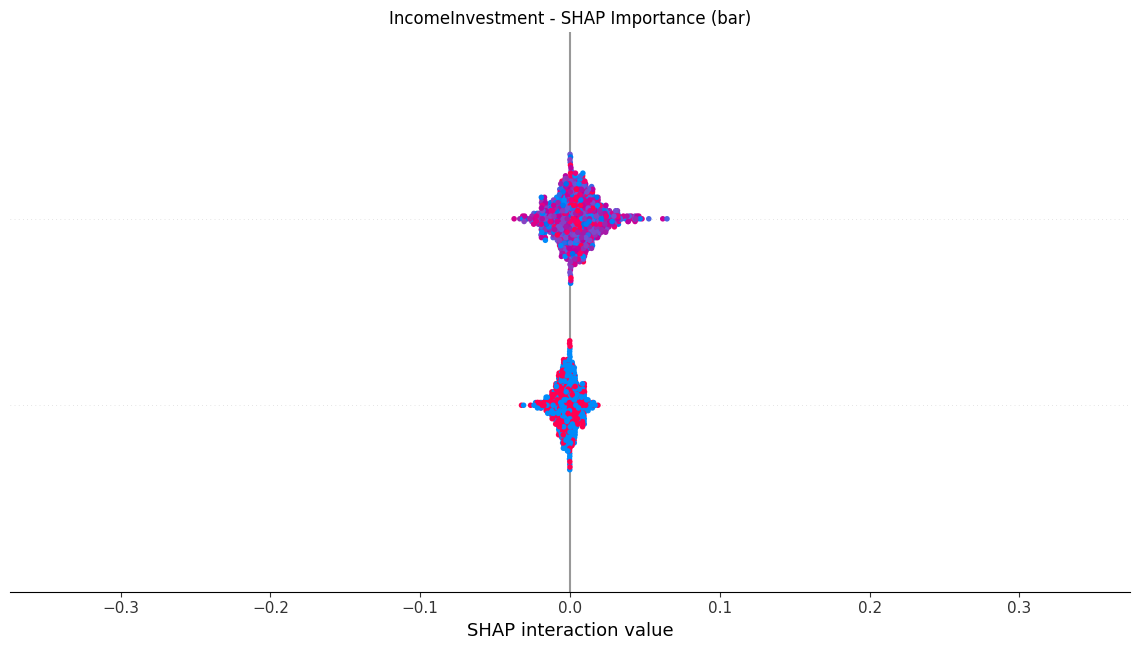

<Figure size 1000x800 with 0 Axes>

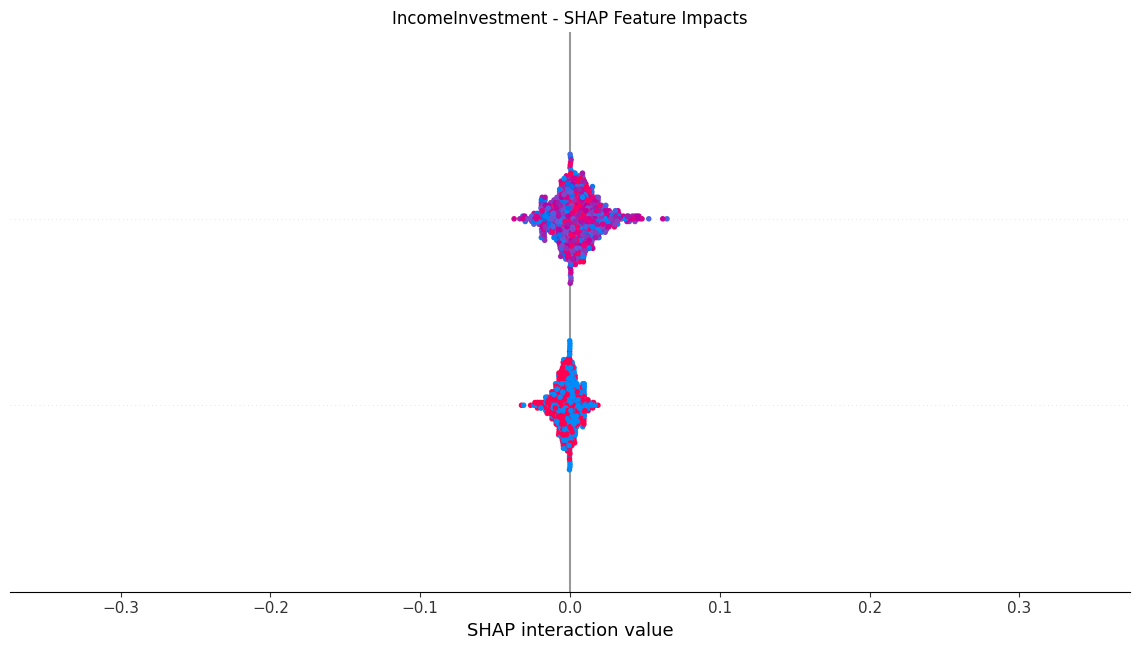

c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


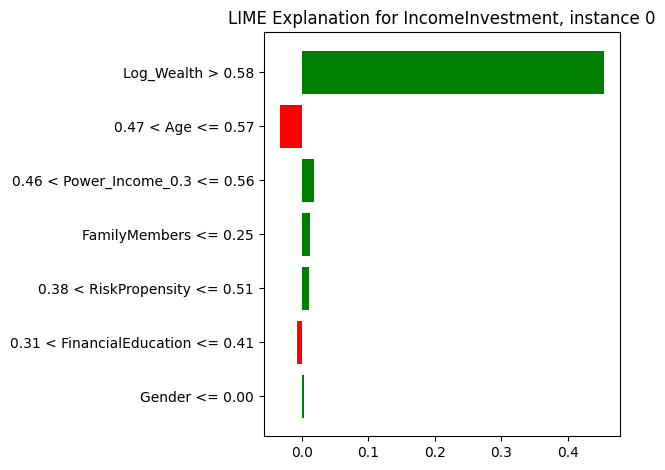

In [10]:
pred.explainability()


---

<a id="sec-3-replica"></a>
# 3. Replica

This section implements a comprehensive workflow for **replicating and evaluating portfolio strategies**. The process begins by selecting the desired portfolio configuration from three distinct investment approaches:

1. **Equity Portfolio**:  
   Focuses on replicating a broad equity index, specifically the `MXWO Index` (MSCI World), to capture global stock market performance.
   
2. **Bond Portfolio**:  
   Targets the fixed-income segment through the `LEGATRUU Index`, representing global bond market exposure.
   
3. **LifeStrategy 80/20 Portfolio**:  
   Represents a balanced approach by combining both equity (`MXWO Index`) and bond (`LEGATRUU Index`) exposures at equal weights (50/50 split), reflecting a diversified strategic allocation.

After selecting the target portfolio, the script loads and preprocesses the data, including historical asset prices and risk metrics. The portfolio replication strategies are then applied using multiple models:

- **Equally Weighted Portfolio** (as a baseline),
- **Elastic Net** (with hyperparameter tuning via Optuna),
- **Kalman Filter**,
- **Ensemble Kalman Filter**.

Each approach’s results are thoroughly analyzed through:

-  Detailed performance metrics (annualized returns, volatility, Sharpe ratio, maximum drawdown, tracking error, information ratio, correlation, average VaR, etc.),

- Visualization of cumulative returns and normalized equity curves,

- Discrete rebalancing analysis considering transaction costs and turnover (Total Expense Ratio),

- Comparison of alternative portfolio performance during periods flagged as anomalies by detection models.

This integrated and modular framework provides a robust toolkit for portfolio construction, evaluation, and anomaly-aware analysis, supporting informed decision-making across different market conditions and investment strategies.

<br>

<br>


<a id="sec-30-replica-intro"></a>
## 3.0 Replica Introduction - Data Loading and Preprocessing

This block sets up the environment and loads the dataset containing historical market data. It configures the target portfolio (`Equity`, `Bond`, or `LifeStrategy 80/20`), determines the corresponding index components, and initializes essential variables such as VaR parameters and transaction costs for further portfolio replication analysis.


In [11]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Suppress FutureWarnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

# Load the dataset from an Excel file
path_Dataset3 = 'Dataset3_PortfolioReplicaStrategyErrataCorrige.xlsx' # Dataset

# Get current working directory
current_dir = os.getcwd()

# Add the path to the dataset
file_path = os.path.join(current_dir, "Datasets", path_Dataset3)

# Load the data from the Excel file
# First sheet contains market data with dates and anomaly labels, second sheet contains metadata
data_df = pd.read_excel(file_path)
# metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# SET EDA_FLAG TRUE to perform exploratory data analysis
EDA_flag = False

# Set the number of trials for the optimization process, if 0 the model run on the trained data
n_trials = 0


In [12]:
# Read the Excel file, and save the names of the assets (row 4)
full_names_df = pd.read_excel(file_path, header=None, skiprows=3, nrows=1)
full_names = full_names_df.iloc[0].tolist()[1:]  # Skip the first column (date column)

# Read Bloomberg tickers (row 6)
tickers_df = pd.read_excel(file_path, header=None, skiprows=5, nrows=1)
tickers = tickers_df.iloc[0].tolist()[1:]  # Skip the first column (date column)

# Create a dictionary mapping tickers to full names
variable_info = dict(zip(tickers, full_names))

# Read the actual data without using any row as a header
data_raw = pd.read_excel(file_path, header=None, skiprows=6)

# cut the data before the 01/01/2017 
data_raw = data_raw[data_raw[0] >= '2013-01-01']  # Filter rows based on the date column

# First column is the date column
data_raw.columns = ['Date'] + tickers  # Assign the columns correctly using tickers

# Set the date column as the index and ensure it's in datetime format
data_raw['Date'] = pd.to_datetime(data_raw['Date'], format='%d/%m/%Y')
data = data_raw.set_index('Date')

# Create a dictionary to hold the index components based on the selected portfolio, and a DataFrame to hold the target data
if selected_flag == 1: # Portfolio Equity
    # EQUITY ETF
    index_components = {
        'MXWO Index': 1
    }
    df_target = data[['MXWO Index']].copy()  # Select the 'MXWO Index' column for further processing

    # VaR parameters - in the equity case, we assume a higher risk profile
    var_confidence = 0.01  # 1% VaR
    var_horizon = 4  # 4 weeks (1 month)
    max_var_threshold = 0.12  # 20% maximum VaR(1%, 1 month)

elif selected_flag == 2: # Portfolio Bond
    # BOND ETF
    index_components = {
        'LEGATRUU Index': 1
    }
    df_target = data[['LEGATRUU Index']].copy()  # Select the 'LEGATRUU Index' column for further processing
    
    # VaR parameters
    var_confidence = 0.01  # 1% VaR
    var_horizon = 4  # 4 weeks (1 month)
    max_var_threshold = 0.08  # 20% maximum VaR(1%, 1 month)

elif selected_flag == 3: # Portfolio LifeStrategy 80/20
    # LIFE STRATEGY ETF
    index_components = {
        'MXWO Index': 0.8,
        'LEGATRUU Index': 0.2,
    }
    df_target = data[['MXWO Index', 'LEGATRUU Index']].copy()  # Select the 'MXWO Index' column for further processing

    # VaR parameters
    var_confidence = 0.01  # 1% VaR
    var_horizon = 4  # 4 weeks (1 month)
    max_var_threshold = 0.08  # 20% maximum VaR(1%, 1 month)
else:
    raise ValueError("Invalid portfolio selection. Please select a valid portfolio.")

# Create a DataFrame to hold the the underlyings
futures_contracts = [
    'RX1 Comdty', 'TY1 Comdty', 'GC1 Comdty', 'CO1 Comdty',
    'ES1 Comdty', 'VG1 Comdty', 'NQ1 Comdty',
    'TP1 Comdty', 'DU1 Comdty', 'TU2 Comdty'
]
df_underlyings = data[futures_contracts].copy()  # Create an empty DataFrame to hold the underlyings

# Set the transaction costs based on the selected portfolio
if selected_flag == 1:  # Portfolio Equity
    transaction_cost = 0.0005  # 0.05% transaction costs for equity
elif selected_flag == 2:
    transaction_cost = 0.0
elif selected_flag == 3:
    transaction_cost = 0.0005
else:
    raise ValueError("Invalid portfolio selection. Please select a valid portfolio.")


annual_factor = 52  # Number of weeks in a year, to be set following the data frequency

# Create a dictionary to hold the VaR parameters
var_parameters = {
    'var_confidence': var_confidence,
    'var_horizon': var_horizon,
    'max_var_threshold': max_var_threshold
}

index_name_str = ', '.join(index_components.keys())


#### Import and Initialize PortfolioReplicator

This block imports the custom `PortfolioReplicator` class from the helper module and initializes an instance with the selected target portfolio, index components, underlying data, risk parameters, and transaction costs. This sets the stage for portfolio replication and performance evaluation.


In [13]:
# Helper module import
import sys
import os

# Get the current working directory (for Jupyter notebooks)
current_dir = os.getcwd()
# Define the relative path to the helper directory
helper_dir = os.path.join(current_dir, "PortfolioReplica")
# Add the helper directory to sys.path if not already there
if helper_dir not in sys.path:
    sys.path.append(helper_dir)

from ReplicaClass import PortfolioReplicator

# Create an instance of the PortfolioReplicator class with the selected parameters
rep = PortfolioReplicator(df_target, index_components, df_underlyings, 
                          var_parameters, transaction_cost, annual_factor, name = f"{get_selected_portfolio()}")


<a id="sec-31-replica-eda"></a>
## 3.1 Portfolio Replica EDA

This section performs **exploratory data analysis** on the selected target portfolio and its underlyings. The EDA includes plotting cumulative returns, investigating correlations, visualizing return distributions and log returns, as well as checking for normality and stationarity. Set `EDA_flag = True` to enable this analysis and gain deeper insights into the dataset.


In [14]:
# EDA_flag = True -> perform exploratory data analysis
if EDA_flag:
    # Plot cumulative returns for the target and underlyings
    rep.plot_cumulative_returns()

    # Display the financial statistics for the target and underlyings
    target_fin_stats, underlyings_fin_stats = rep.fin_stats()
    display(target_fin_stats)
    display(underlyings_fin_stats)

    # Plot the correlation map for the target and underlyings
    rep.corr_map()

    # Plot the distribution of returns for the target and underlyings
    rep.return_distribution()

    # Plot the log returns for the target and underlyings
    rep.plot_log_returns()

    # Plot the rolling correlation between the target and underlyings
    rolling_window = 52  # 1 year rolling window
    rep.plot_rolling_correlation(window=rolling_window)

    # Plot the bar correlation between the target and underlyings
    rep.bar_corr_target_underlyings()

    # Perform normality and stationarity checks
    rep.normality_check()
    rep.stationarity_check()
    
else:
    print("Exploratory Data Analysis is skipped. Set EDA_flag to True to perform EDA.")


Exploratory Data Analysis is skipped. Set EDA_flag to True to perform EDA.


<a id="sec-32-replica-ewptf"></a>
## 3.2 Equally Weighted Portfolio Replication

In this section, we implement and evaluate an equally weighted portfolio replication strategy using the `PortfolioReplicator` class. The model assigns equal weights to all underlying assets over a rolling window and aims to replicate the performance of the selected target portfolio.

The code below:
- Runs the equally weighted portfolio strategy with a specified rolling window.
- Computes key performance metrics such as information ratio, correlation, tracking error, Sharpe ratio, average gross exposure, and average Value at Risk (VaR).
- Displays a summary table comparing the replica portfolio to the target portfolio across several risk and return metrics.
- Visualizes the results to provide a baseline for comparison with more advanced replication methods.

This equally weighted approach serves as a benchmark to assess the effectiveness of more sophisticated portfolio replication techniques introduced later in the notebook.



Metrics for Equally Weighted Portfolio:


,information_ratio,correlation,tracking_error,replica_sharpe,avg_gross_exposure,avg_var
0,-0.531319,0.826816,0.08671,0.888259,1.0,NaN



Detailed metrics for Equally Weighted vs Target:


,Metric,Target,Replica
0,Annualized return,12.99%,8.38%
1,Annualized volatility,14.66%,9.44%
2,Sharpe ratio,0.89,0.89
3,Max Drawdown,28.04%,17.36%
4,Tracking Error,N/A,8.67%
5,Information ratio,N/A,-0.53
6,Correlation,N/A,0.8268
7,Average gross exposure,N/A,1.0000
8,"Average VaR (1%, 1M)",N/A,nan%


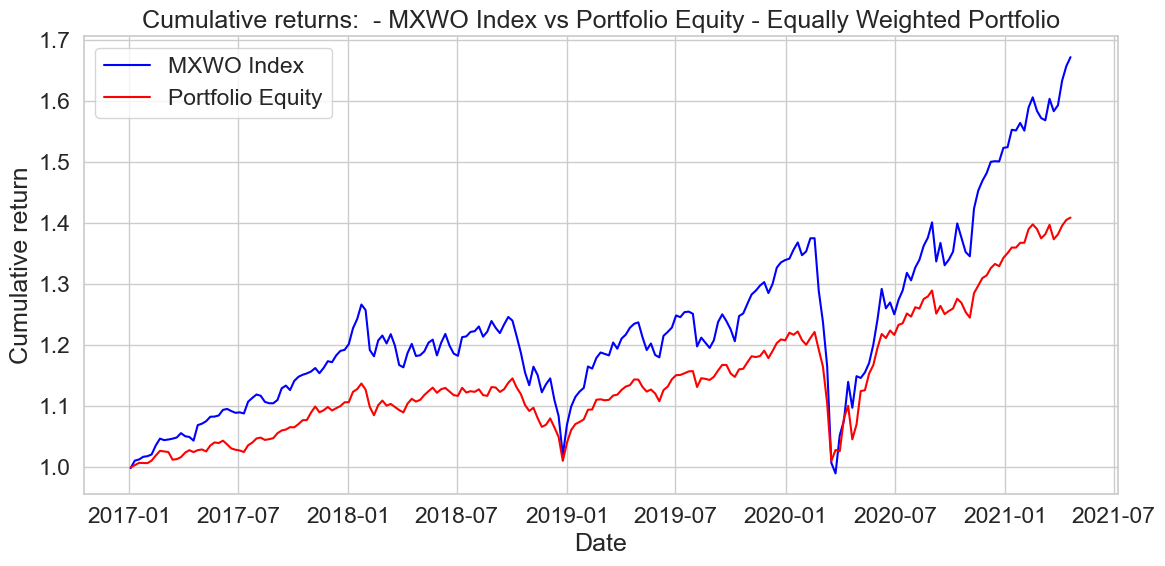

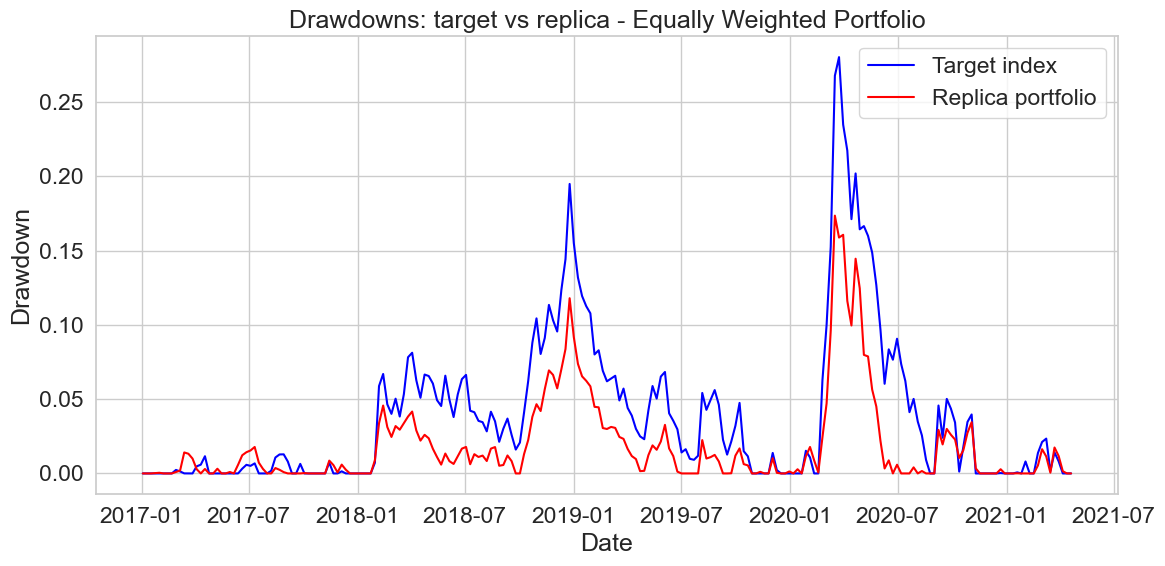

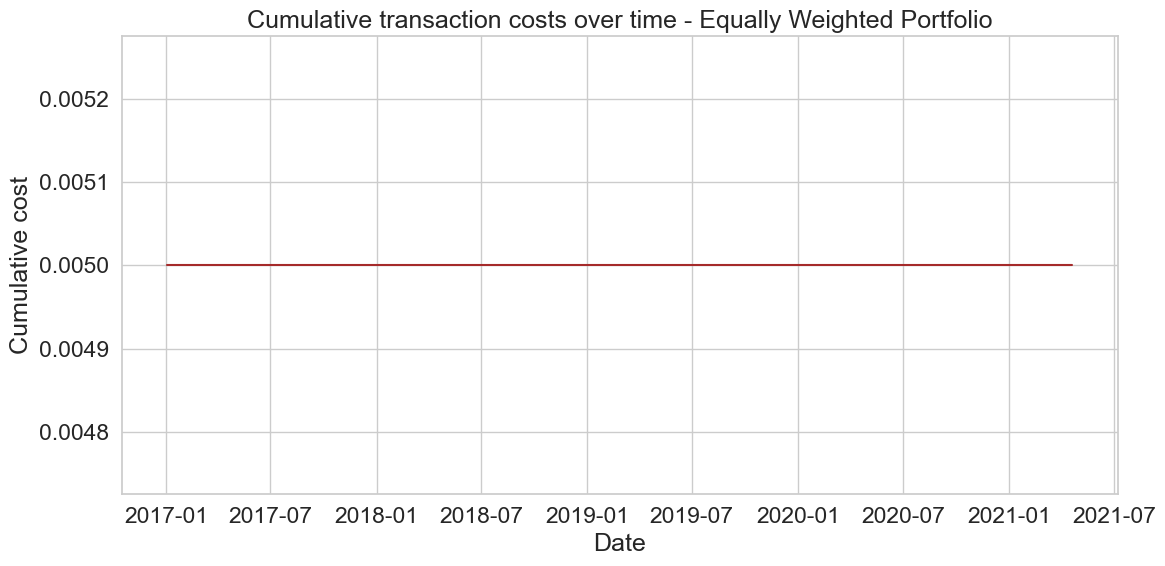

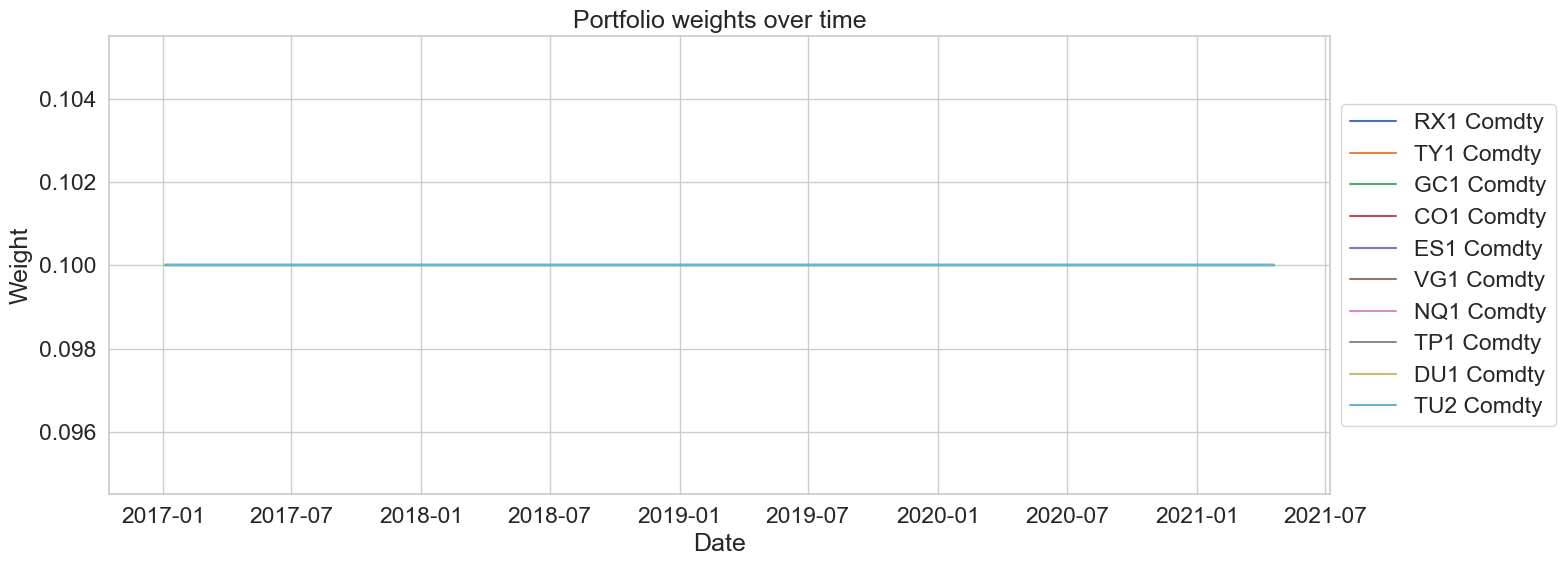

In [15]:
# Param
window = 208

results_equal_weighted = rep.run_equal_weight_portfolio(window)

# Create a DataFrame for the results
result_equal_weighted_df = pd.DataFrame([results_equal_weighted])

# Display the results
print("\nMetrics for Equally Weighted Portfolio:")
display(result_equal_weighted_df[['information_ratio', 'correlation',
                       'tracking_error', 'replica_sharpe', 'avg_gross_exposure', 'avg_var']].head(1))
 
# Extract the first row for detailed metrics
result_equal_weighted_df = result_equal_weighted_df.iloc[0]

# Create detailed metrics table for the LR configuration
metrics_normalized_equal_weighted = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{result_equal_weighted_df['target_return']*100:.2f}%",
               f"{result_equal_weighted_df['target_vol']*100:.2f}%",
               f"{result_equal_weighted_df['target_sharpe']:.2f}",
               f"{result_equal_weighted_df['target_max_drawdown']*100:.2f}%",
               "N/A",
               "N/A",
               "N/A",
               "N/A",
               "N/A"],
    'Replica': [f"{result_equal_weighted_df['replica_return']*100:.2f}%",
                f"{result_equal_weighted_df['replica_vol']*100:.2f}%",
                f"{result_equal_weighted_df['replica_sharpe']:.2f}",
                f"{result_equal_weighted_df['max_drawdown']*100:.2f}%",
                f"{result_equal_weighted_df['tracking_error']*100:.2f}%",
                f"{result_equal_weighted_df['information_ratio']:.2f}",
                f"{result_equal_weighted_df['correlation']:.4f}",
                f"{result_equal_weighted_df['avg_gross_exposure']:.4f}",
                f"{result_equal_weighted_df['avg_var']*100:.2f}%"]
})

print("\nDetailed metrics for Equally Weighted vs Target:")
display(metrics_normalized_equal_weighted)

# Plot the results for the Linear Regression model
rep.plot_metrics(result_equal_weighted_df, 'Equally Weighted Portfolio')


<a id="sec-33-replica-en"></a>
## 3.3 Elastic Net Portfolio Replication

In this section, we implement and evaluate a portfolio replication strategy using the Elastic Net regression model. Elastic Net is a regularized regression technique that linearly combines the penalties of Lasso (L1) and Ridge (L2) methods. This approach is particularly useful when dealing with highly correlated features, as it encourages both sparsity and grouping effects in the portfolio weights.

**Theory Snapshot:**  
Elastic Net regression solves the following optimization problem:

$$
\min_{\beta} \left\{ \frac{1}{2n} \| y - X\beta \|^2_2 + \alpha \left( \lambda \|\beta\|_1 + \frac{1-\lambda}{2} \|\beta\|_2^2 \right) \right\}
$$

where $\alpha$ controls the overall strength of regularization and $\lambda$ determines the mix between L1 and L2 penalties.

**What this cell does:**
- Runs an Optuna hyperparameter search to find the best Elastic Net configuration for portfolio replication.
- Trains the Elastic Net model using the optimal parameters.
- Computes and displays key performance metrics for the replica portfolio, including information ratio, correlation, tracking error, Sharpe ratio, average gross exposure, and average VaR.
- Presents a detailed comparison table between the target and replica portfolios.
- Visualizes the performance of the Elastic Net-based replica portfolio.

This method provides a more flexible and potentially more robust alternative to the equally weighted benchmark, especially in the presence of multicollinearity among the underlying assets.


In [16]:
# 3) Run Optuna search, depending on the selected portfolio we differentiate the storage aand name of the study
name = get_selected_portfolio()
# the storage name wll be EN_PtfName and is in the foalder called with the name of the portfolio
folder_name = f"{name.replace(' ', '_')}"  # e.g., EN_Portfolio_Equity
storage_name = f"EN_{name.replace(' ', '_')}"  # e.g., optuna_Portfolio_Equity
stu_name = f"EN_{name.replace(' ', '_')}_study"  # e.g., Portfolio_Equity_study

storage_dir = Path.cwd() / f"PortfolioReplica/{folder_name}"
storage_dir.mkdir(parents=True, exist_ok=True)

# 2) build the full sqlite URL
storage_path = f"./PortfolioReplica/{folder_name}/{storage_name}"

study_EN = rep.run_optuna_normalized(
    n_trials=n_trials,
    storage=storage_path,
    study_name=stu_name,
    obj = rep._optuna_objective_EN
)


[I 2026-09-03 12:54:10,060] Using an existing study with name 'EN_Portfolio_Equity_study' instead of creating a new one.


Optuna completed: 1400 COMPLETE, 0 FAIL, 0 PRUNED.
Best value: -0.35408724107804324
Best params: {'l1_ratio': 0.9999104088297178, 'rolling_window': 208, 'alpha': 0.00788680324223997, 'rebalancing_window': 4}



Top Optuna configuration by information ratio:


,l1_ratio,rolling_window,alpha,information_ratio,correlation,tracking_error,replica_sharpe,avg_gross_exposure,avg_var
0,0.99991,208,0.007887,0.354087,0.955391,0.044039,1.102278,0.856044,0.07555



Detailed metrics for the best configuration (normalized returns):


,Metric,Target,Replica
0,Annualized return,12.99%,14.55%
1,Annualized volatility,14.66%,13.20%
2,Sharpe ratio,0.89,1.10
3,Max Drawdown,28.04%,20.15%
4,Tracking Error,N/A,4.40%
5,Information ratio,N/A,0.35
6,Correlation,N/A,0.9554
7,Average gross exposure,N/A,0.8560
8,"Average VaR (1%, 1M)",N/A,7.55%


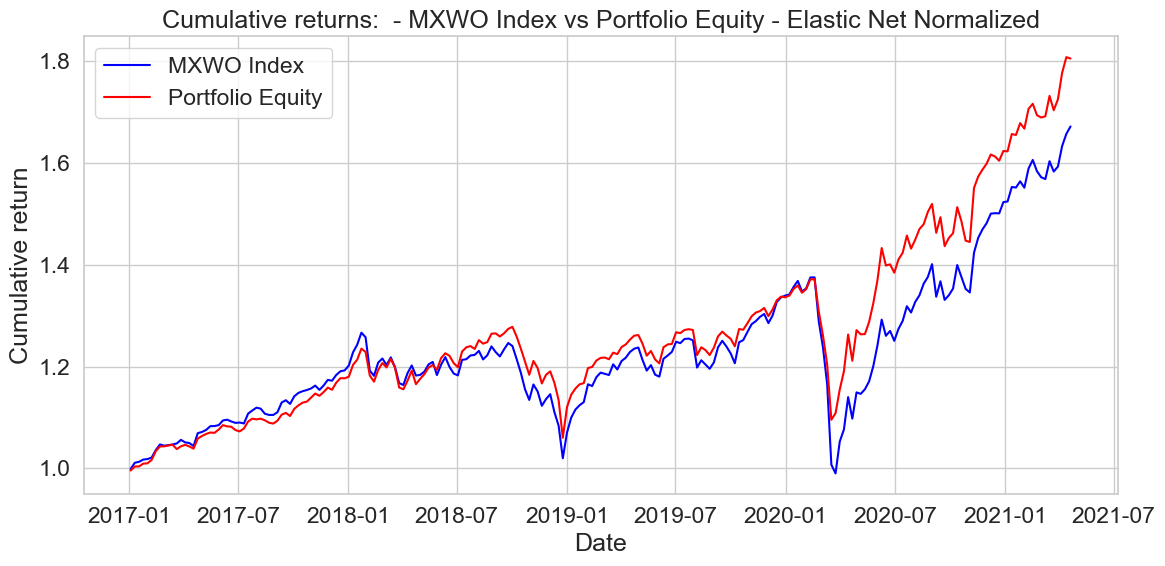

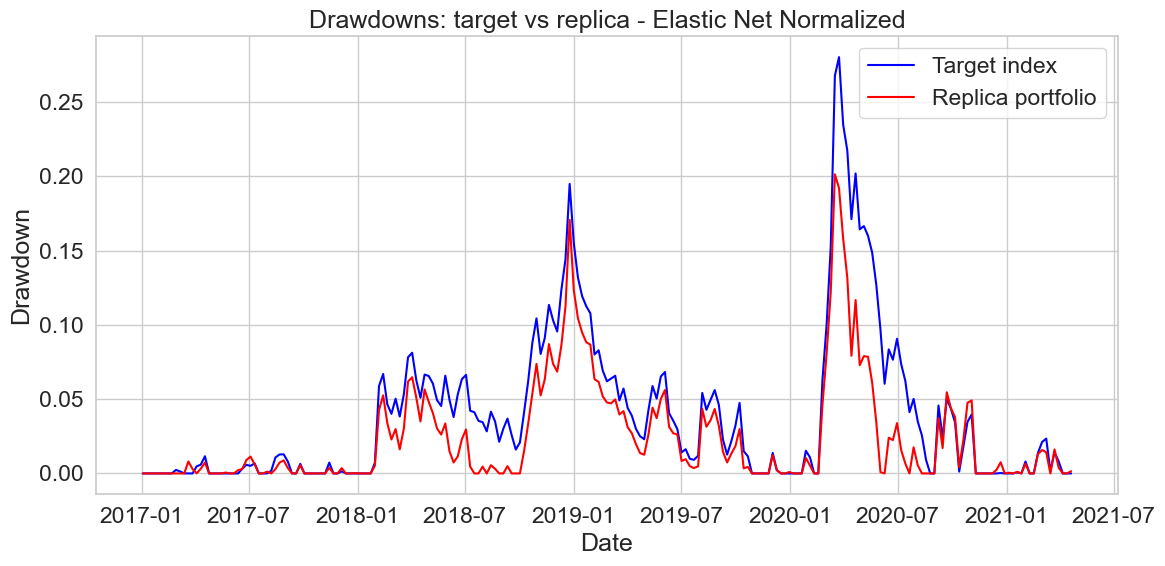

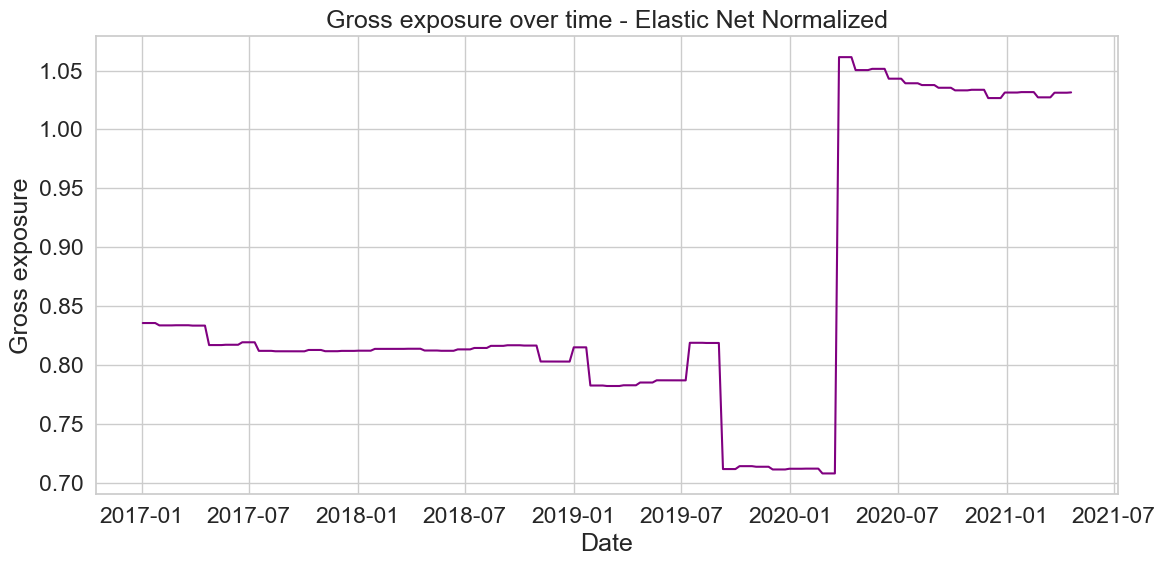

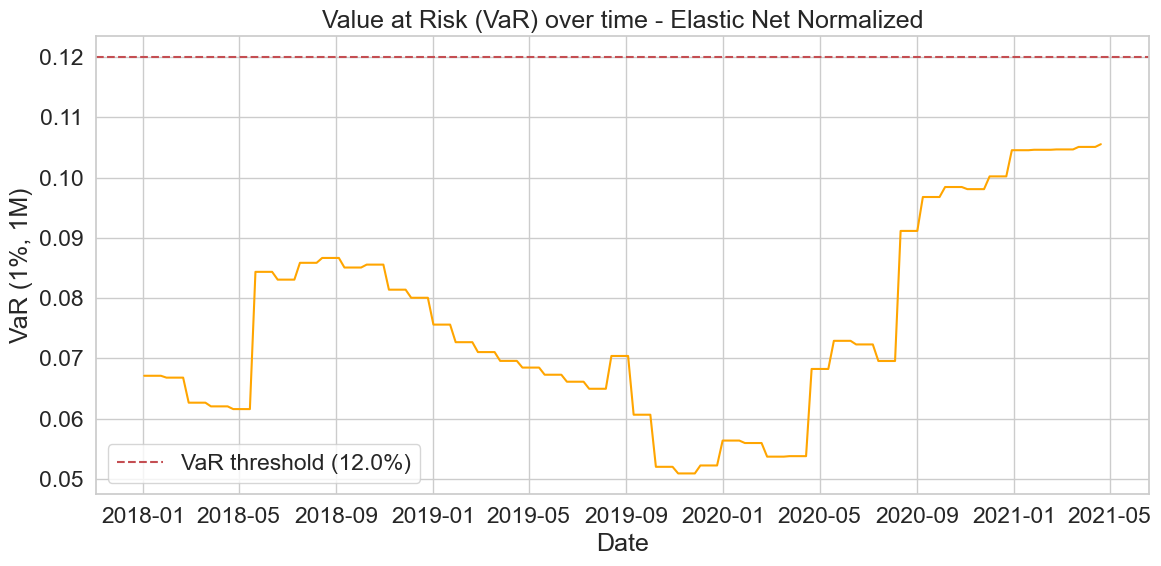

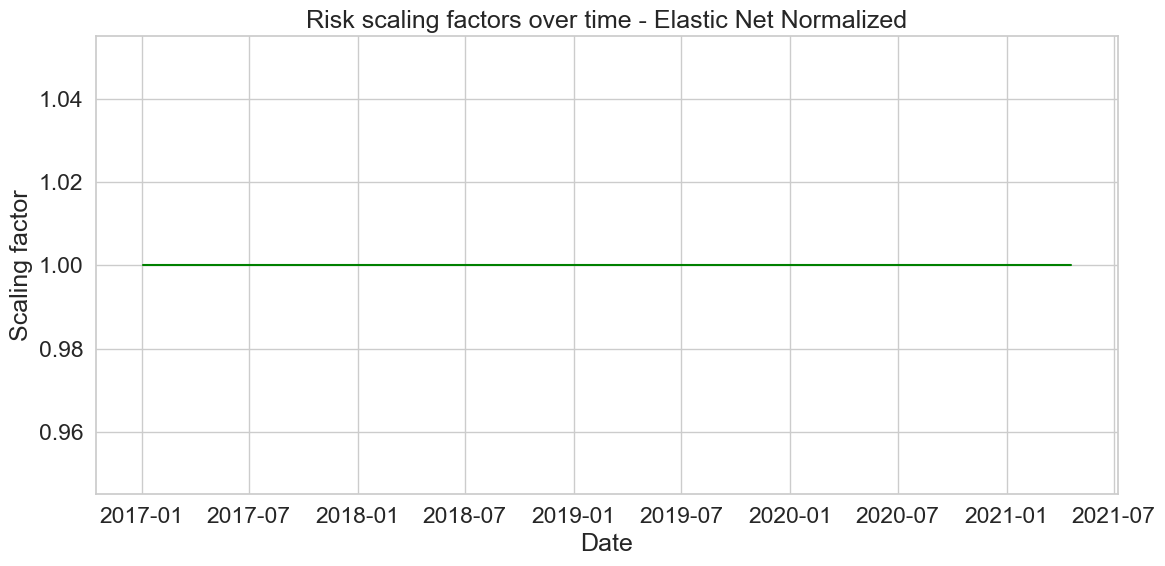

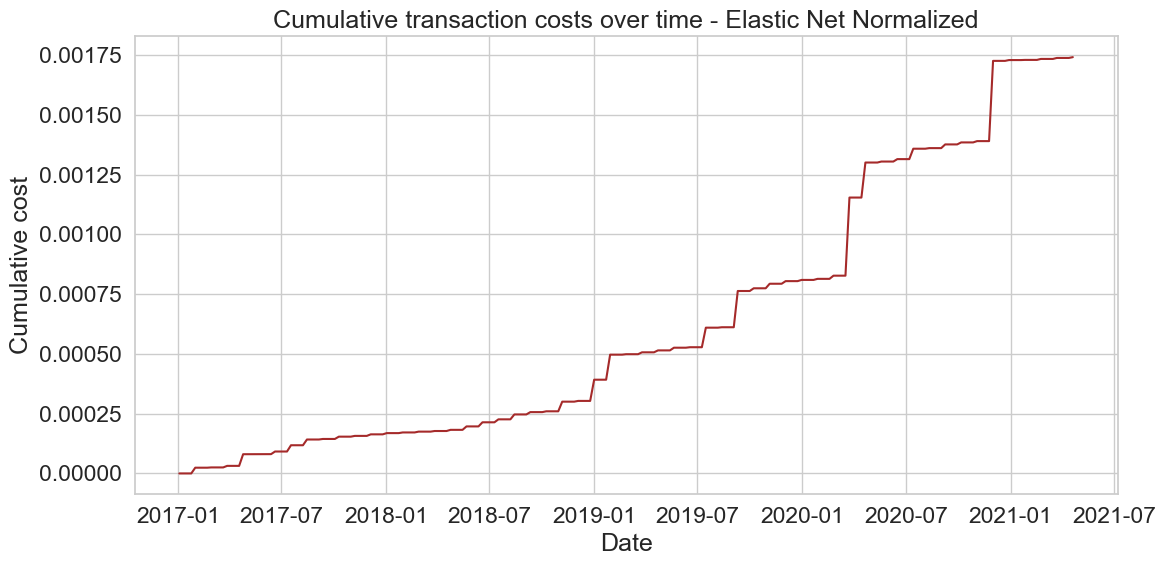

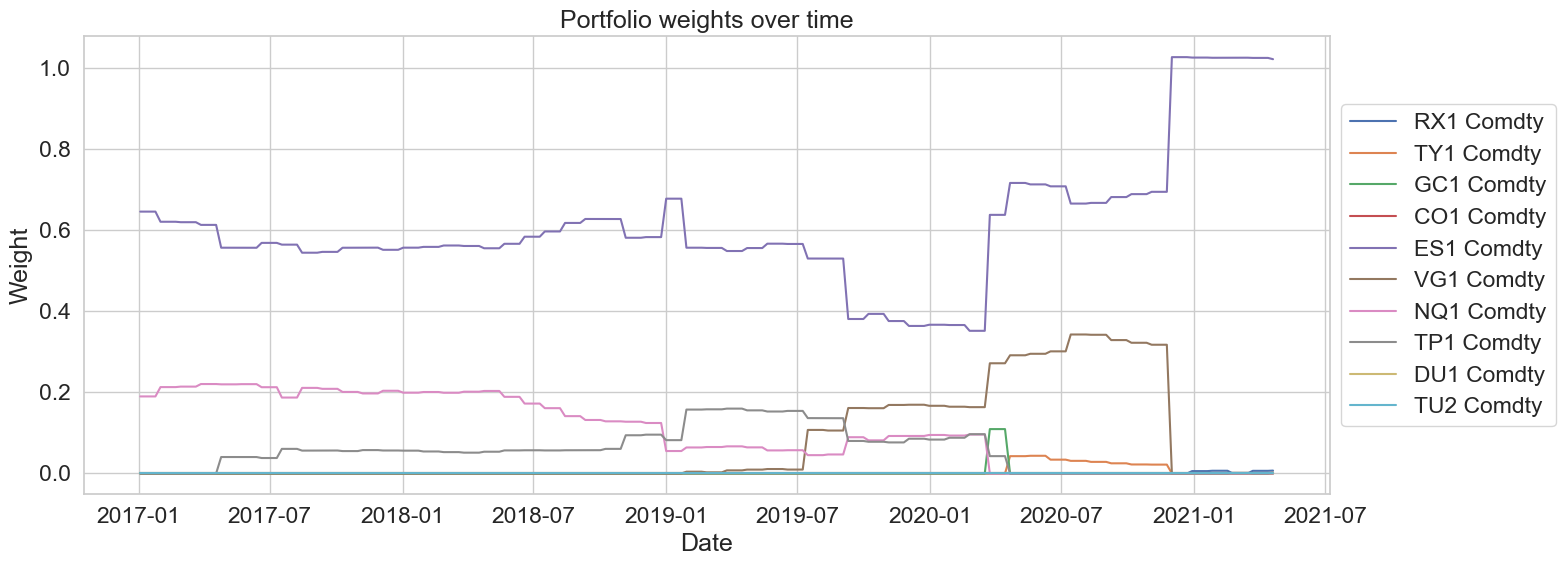

In [17]:
results_normalized_EN = []

best = study_EN.best_params
l1_ratio = best["l1_ratio"]
rolling_window = best["rolling_window"]
alpha = best["alpha"]
rebalancing_window = best["rebalancing_window"]

results_EN = rep.run_elasticnet_normalized(l1_ratio, rolling_window, alpha,rebalancing_window)
results_normalized_EN.append(results_EN)

# Convert results to DataFrame for easier analysis
results_df_normalized_EN = pd.DataFrame(results_normalized_EN)

# Display top configuration by information ratio
print("\nTop Optuna configuration by information ratio:")
display(results_df_normalized_EN[['l1_ratio', 'rolling_window', 'alpha', 'information_ratio', 'correlation',
                       'tracking_error', 'replica_sharpe', 'avg_gross_exposure', 'avg_var']].head(10))

best_config_normalized_EN = results_df_normalized_EN.iloc[0]

# Create detailed metrics table for the best configuration
metrics_normalized_EN = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{best_config_normalized_EN['target_return']*100:.2f}%",
               f"{best_config_normalized_EN['target_vol']*100:.2f}%",
               f"{best_config_normalized_EN['target_sharpe']:.2f}",
               f"{best_config_normalized_EN['target_max_drawdown']*100:.2f}%",
               "N/A",
               "N/A",
               "N/A",
               "N/A",
               "N/A"],
    'Replica': [f"{best_config_normalized_EN['replica_return']*100:.2f}%",
                f"{best_config_normalized_EN['replica_vol']*100:.2f}%",
                f"{best_config_normalized_EN['replica_sharpe']:.2f}",
                f"{best_config_normalized_EN['max_drawdown']*100:.2f}%",
                f"{best_config_normalized_EN['tracking_error']*100:.2f}%",
                f"{best_config_normalized_EN['information_ratio']:.2f}",
                f"{best_config_normalized_EN['correlation']:.4f}",
                f"{best_config_normalized_EN['avg_gross_exposure']:.4f}",
                f"{best_config_normalized_EN['avg_var']*100:.2f}%"]
})

print("\nDetailed metrics for the best configuration (normalized returns):")
display(metrics_normalized_EN)

# Plot the results for the best configuration
rep.plot_metrics(best_config_normalized_EN, 'Elastic Net Normalized')


<a id="sec-34-replica-kf"></a>
## 3.4 Kalman Filter Portfolio Replication

In this section, we implement and evaluate a portfolio replication strategy using the Kalman Filter model. The Kalman Filter is a recursive algorithm that estimates the state of a dynamic system from a series of noisy measurements. In the context of portfolio replication, it is used to dynamically estimate and update the optimal portfolio weights over time, adapting to changing market conditions.

**Theory Snapshot:**  
The Kalman Filter operates in two main steps: prediction and update. It predicts the next state (portfolio weights) based on the previous state and then updates this prediction using new observed data (asset returns). This approach allows for real-time tracking and adjustment of portfolio weights, making it well-suited for financial time series that exhibit non-stationarity and noise.

**What this cell does:**
- Runs the Kalman Filter-based portfolio replication model with specified rolling and rebalancing windows.
- Computes and displays key performance metrics for the replica portfolio, including information ratio, correlation, tracking error, Sharpe ratio, average gross exposure, and average VaR.
- Presents a detailed comparison table between the target and replica portfolios.
- Visualizes the performance of the Kalman Filter-based replica portfolio.

This method provides a dynamic and adaptive alternative to static or regression-based approaches, potentially improving replication accuracy in volatile or evolving markets.


In [18]:

name = get_selected_portfolio()
# the storage name wll be EN_PtfName and is in the foalder called with the name of the portfolio
folder_name = f"{name.replace(' ', '_')}"  # e.g., EN_Portfolio_Equity
storage_name = f"KF_{name.replace(' ', '_')}"  # e.g., optuna_Portfolio_Equity
stu_name = f"KF_{name.replace(' ', '_')}_study"  # e.g., Portfolio_Equity_study

storage_dir = Path.cwd() / f"PortfolioReplica/{folder_name}"
storage_dir.mkdir(parents=True, exist_ok=True)

storage_path = f"./PortfolioReplica/{folder_name}/{storage_name}"

# 3) Run Optuna search
study_KF = rep.run_optuna_normalized(
    n_trials=n_trials,
    storage=storage_path,
    study_name=stu_name,
    obj=rep._optuna_objective_KF,
)


[I 2026-09-03 12:54:19,208] Using an existing study with name 'KF_Portfolio_Equity_study' instead of creating a new one.


Optuna completed: 59 COMPLETE, 0 FAIL, 141 PRUNED.
Best value: -0.17198946778233604
Best params: {'process_noise_scale': 0.08174948445526938, 'rolling_window': 208, 'rebalancing_window': 4}



Top Optuna configuration by information ratio:


,information_ratio,correlation,tracking_error,replica_sharpe,avg_gross_exposure,avg_var
0,0.171989,0.972568,0.034225,0.972331,1.477643,0.079419



Detailed metrics for the best configuration (normalized returns):


,Metric,Target,Replica
0,Annualized return,12.99%,13.58%
1,Annualized volatility,14.66%,13.96%
2,Sharpe ratio,0.89,0.97
3,Max Drawdown,28.04%,24.45%
4,Tracking Error,N/A,3.42%
5,Information ratio,N/A,0.17
6,Correlation,N/A,0.9726
7,Average gross exposure,N/A,1.4776
8,"Average VaR (1%, 1M)",N/A,7.94%


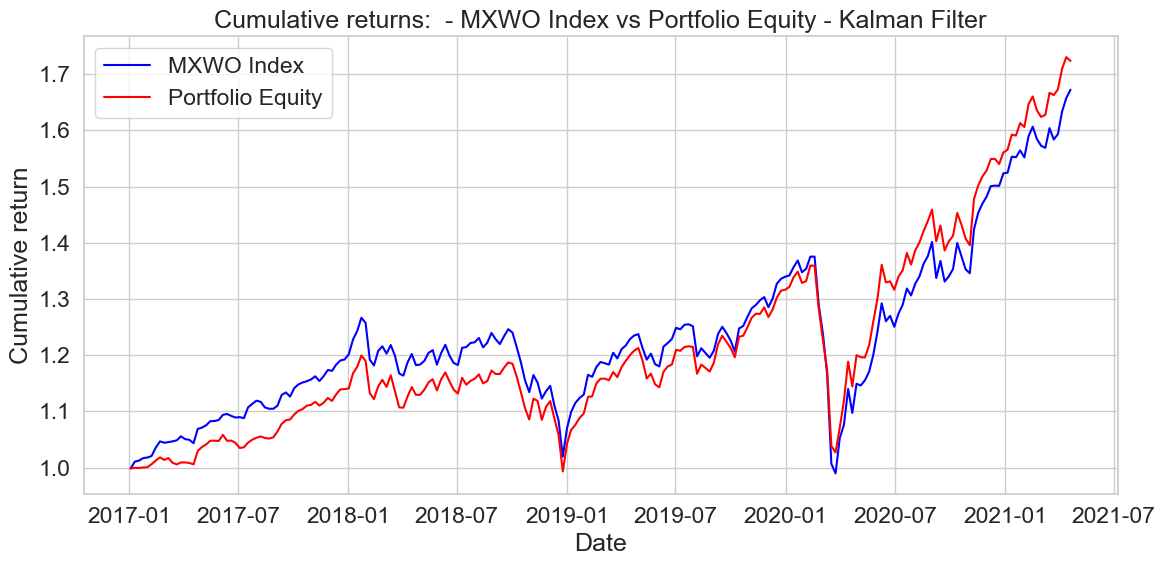

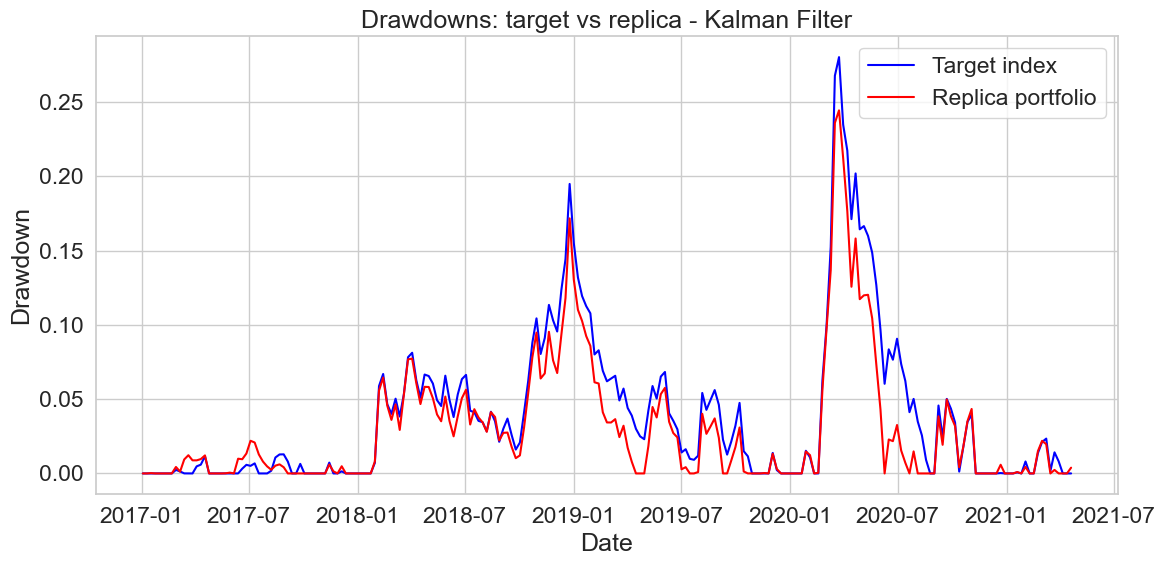

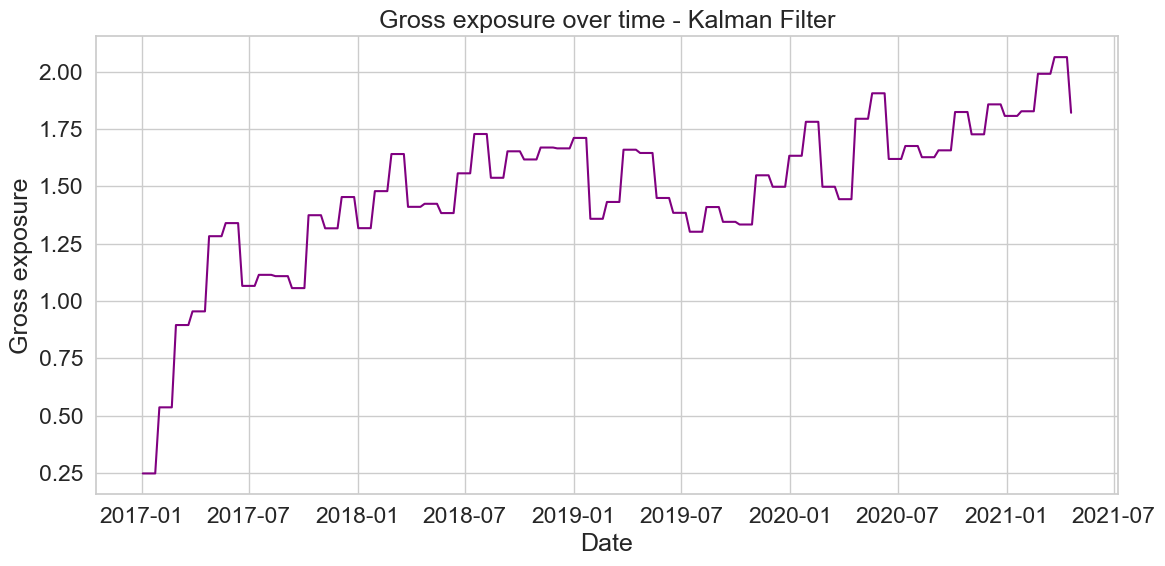

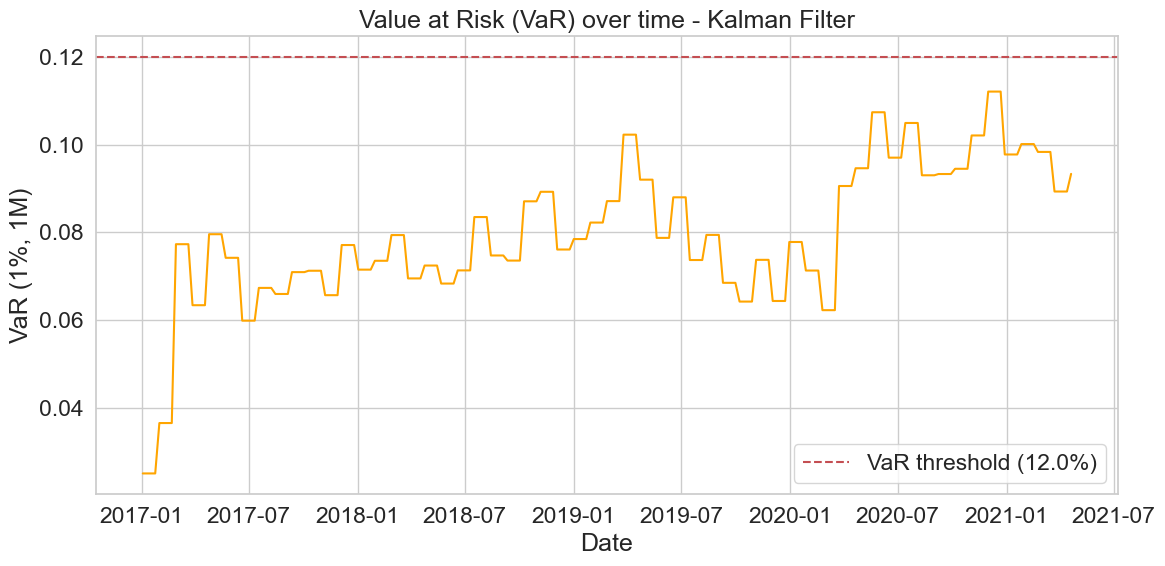

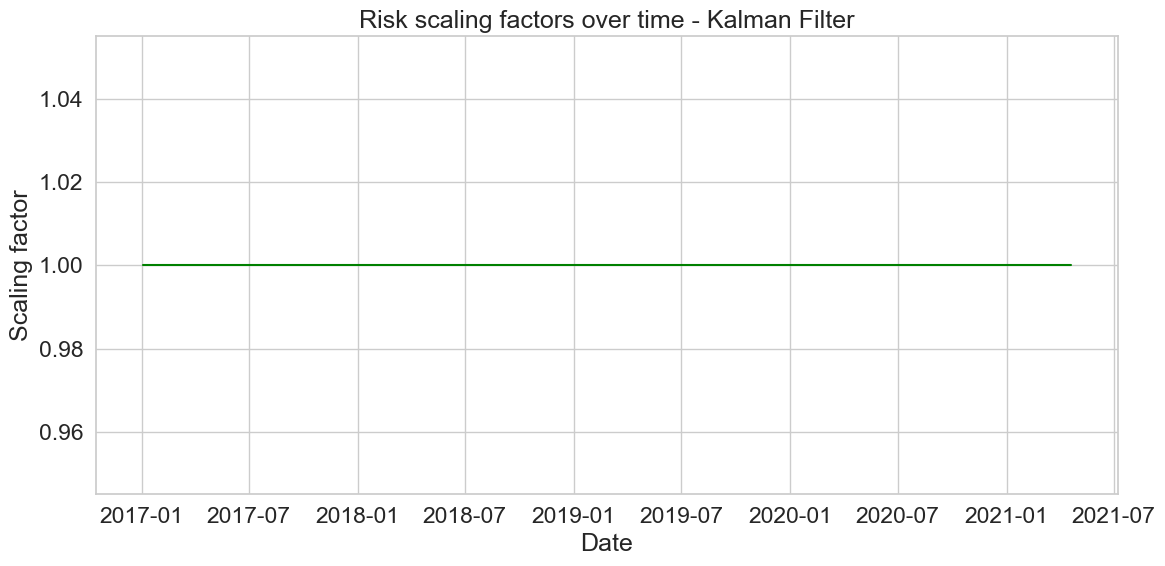

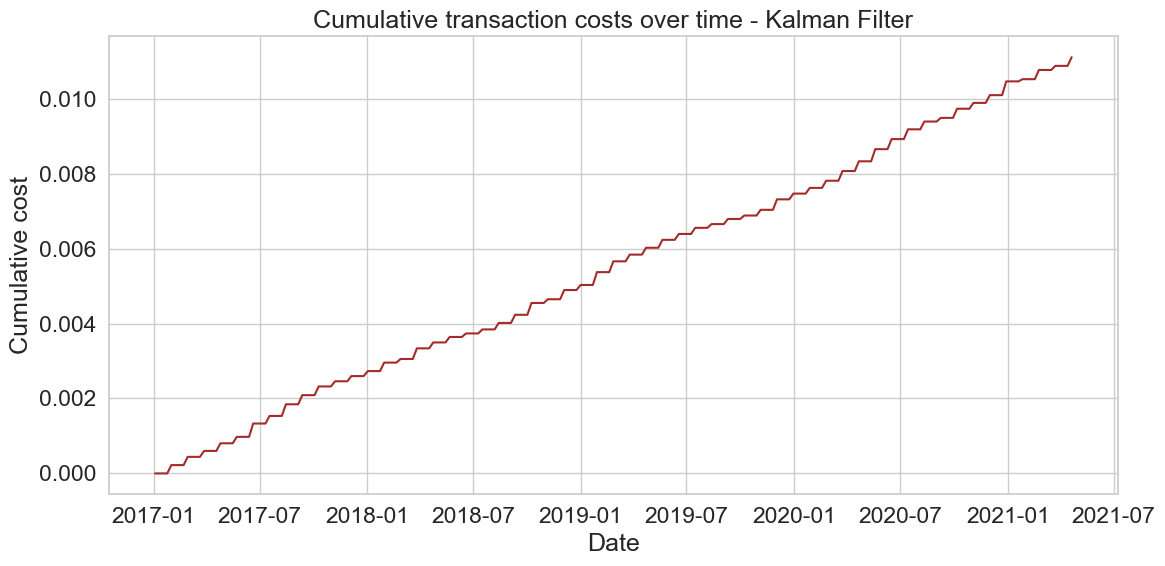

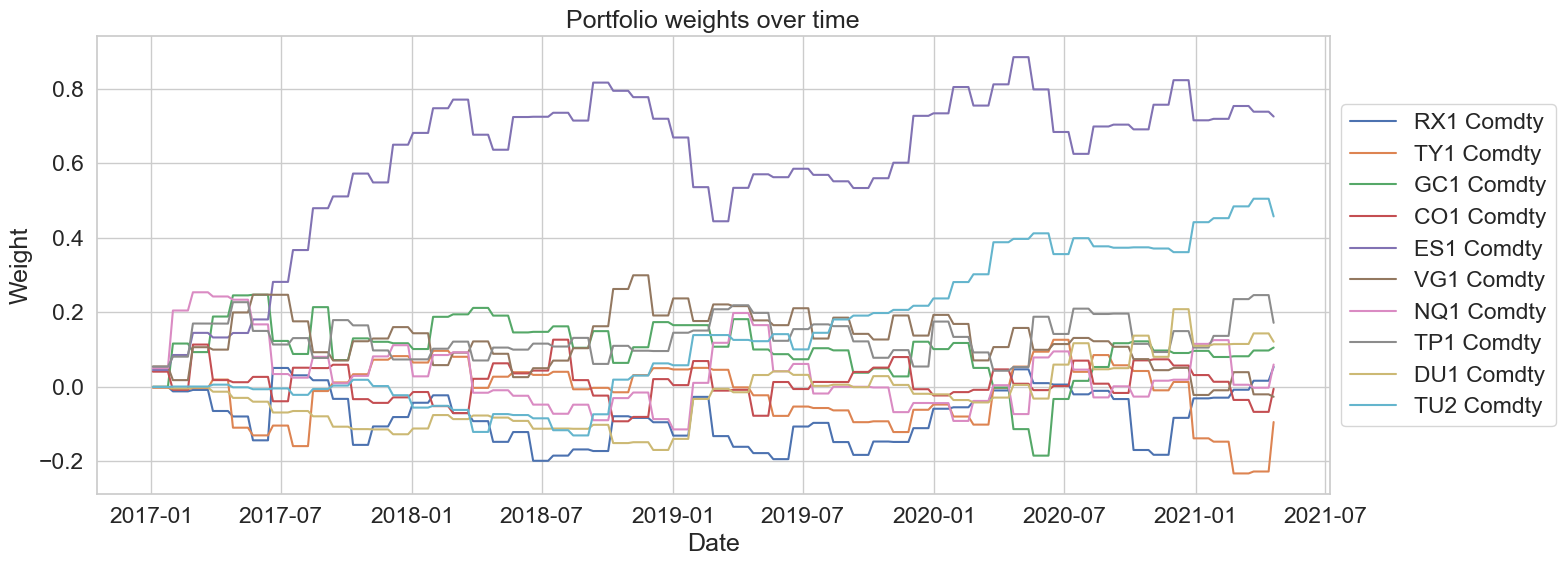

In [19]:
# Run the Kalman filter model
best_params_KF = study_KF.best_params
best_params_KF

result_KF = rep.run_kalman_filter_model(
    rolling_window=best_params_KF["rolling_window"],
    rebalancing_window=best_params_KF["rebalancing_window"],
    process_noise_scale=best_params_KF["process_noise_scale"],
)

# Create a DataFrame for the results
result_KF_df = pd.DataFrame([result_KF])

# Display top configuration by information ratio
print("\nTop Optuna configuration by information ratio:")
display(result_KF_df[[ 'information_ratio', 'correlation',
                       'tracking_error', 'replica_sharpe', 'avg_gross_exposure', 'avg_var']].head(1))

best_config_normalized_KF = result_KF_df.iloc[0]


# Create detailed metrics table for the best configuration
metrics_normalized_KF = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{best_config_normalized_KF['target_return']*100:.2f}%",
               f"{best_config_normalized_KF['target_vol']*100:.2f}%",
               f"{best_config_normalized_KF['target_sharpe']:.2f}",
               f"{best_config_normalized_KF['target_max_drawdown']*100:.2f}%",
               "N/A",
               "N/A",
               "N/A",
               "N/A",
               "N/A"],
    'Replica': [f"{best_config_normalized_KF['replica_return']*100:.2f}%",
                f"{best_config_normalized_KF['replica_vol']*100:.2f}%",
                f"{best_config_normalized_KF['replica_sharpe']:.2f}",
                f"{best_config_normalized_KF['max_drawdown']*100:.2f}%",
                f"{best_config_normalized_KF['tracking_error']*100:.2f}%",
                f"{best_config_normalized_KF['information_ratio']:.2f}",
                f"{best_config_normalized_KF['correlation']:.4f}",
                f"{best_config_normalized_KF['avg_gross_exposure']:.4f}",
                f"{best_config_normalized_KF['avg_var']*100:.2f}%"]
})

print("\nDetailed metrics for the best configuration (normalized returns):")
display(metrics_normalized_KF)


# Display the results
rep.plot_metrics(result_KF, 'Kalman Filter')


<a id="sec-35-replica-ekf"></a>
## 3.5 Ensemble Kalman Filter Portfolio Replication

In this section, we implement and evaluate a portfolio replication strategy using the **Ensemble Kalman Filter (EnKF)** model. The EnKF is an advanced extension of the standard Kalman Filter, designed to handle non-linearities and model uncertainties by propagating an ensemble (collection) of possible state vectors (here, portfolio weights) through time.

**Theory Snapshot:**  
The Ensemble Kalman Filter works by maintaining a set of possible weight vectors (the ensemble), each of which evolves over time according to a random-walk process (process noise). At each rebalancing step:
- Each ensemble member is updated using new observed data (asset returns) via a Kalman update, which adjusts the weights based on the observed error.
- The ensemble mean and covariance are used to estimate the current optimal portfolio weights and their uncertainty.
- This approach allows the model to adapt dynamically to changing market conditions, capturing both the mean and the uncertainty of the optimal weights.

Key steps in the implementation:
- **Initialization:** The process starts with a Ridge regression on the initial rolling window to set the starting weights.
- **Ensemble Propagation:** At each rebalancing date, the weights are updated using the Kalman filter equations, with process noise injected to simulate uncertainty and allow for exploration of different possible weight paths.
- **Observation Update:** The filter incorporates the latest observed return, updating the ensemble of weights accordingly.
- **VaR Scaling:** If the Value at Risk (VaR) exceeds a threshold, the weights are scaled down to control risk.
- **Transaction Costs:** The model accounts for transaction costs based on the turnover in weights.
- **Holding Weights:** On non-rebalancing days, the previous weights are held constant.

**What this cell does:**
- Runs an Optuna hyperparameter search to find the best configuration for the Ensemble Kalman Filter (ensemble size, process noise scale, rolling and rebalancing windows).
- Trains the EnKF model using the optimal parameters.
- Computes and displays key performance metrics for the replica portfolio, including information ratio, correlation, tracking error, Sharpe ratio, average gross exposure, and average VaR.
- Presents a detailed comparison table between the target and replica portfolios.
- Visualizes the performance of the Ensemble Kalman Filter-based replica portfolio.

This method provides a robust and flexible alternative to traditional Kalman Filter and regression-based approaches, especially in environments with high uncertainty, non-linearity, and time-varying relationships between assets.


In [20]:

name = get_selected_portfolio()
# the storage name wll be EN_PtfName and is in the foalder called with the name of the portfolio
folder_name = f"{name.replace(' ', '_')}"  # e.g., EN_Portfolio_Equity
storage_name = f"EnKF_{name.replace(' ', '_')}"  # e.g., optuna_Portfolio_Equity
stu_name = f"EnKF_{name.replace(' ', '_')}_study"  # e.g., Portfolio_Equity_study

storage_dir = Path.cwd() / f"PortfolioReplica/{folder_name}"
storage_dir.mkdir(parents=True, exist_ok=True)

storage_path = f"./PortfolioReplica/{folder_name}/{storage_name}"

# 3) Run Optuna search
study_EnKF = rep.run_optuna_normalized(
    n_trials=n_trials,
    storage=storage_path,
    study_name=stu_name,
    obj=rep._optuna_objective_EnKF
)


[I 2026-09-03 12:54:27,371] Using an existing study with name 'EnKF_Portfolio_Equity_study' instead of creating a new one.


Optuna completed: 62 COMPLETE, 0 FAIL, 138 PRUNED.
Best value: -0.6137295091481867
Best params: {'ensemble_size': 41, 'process_noise_scale': 0.09679804531928156, 'rolling_window': 208, 'rebalancing_window': 2}



Top Optuna configuration by information ratio:


,information_ratio,correlation,tracking_error,replica_sharpe,avg_gross_exposure,avg_var
0,0.61373,0.911154,0.060967,1.179713,3.045024,0.087929



Detailed metrics for the best configuration (normalized returns):


,Metric,Target,Replica
0,Annualized return,12.99%,16.73%
1,Annualized volatility,14.66%,14.18%
2,Sharpe ratio,0.89,1.18
3,Max Drawdown,28.04%,24.22%
4,Tracking Error,N/A,6.10%
5,Information ratio,N/A,0.61
6,Correlation,N/A,0.9112
7,Average gross exposure,N/A,3.0450
8,"Average VaR (1%, 1M)",N/A,8.79%


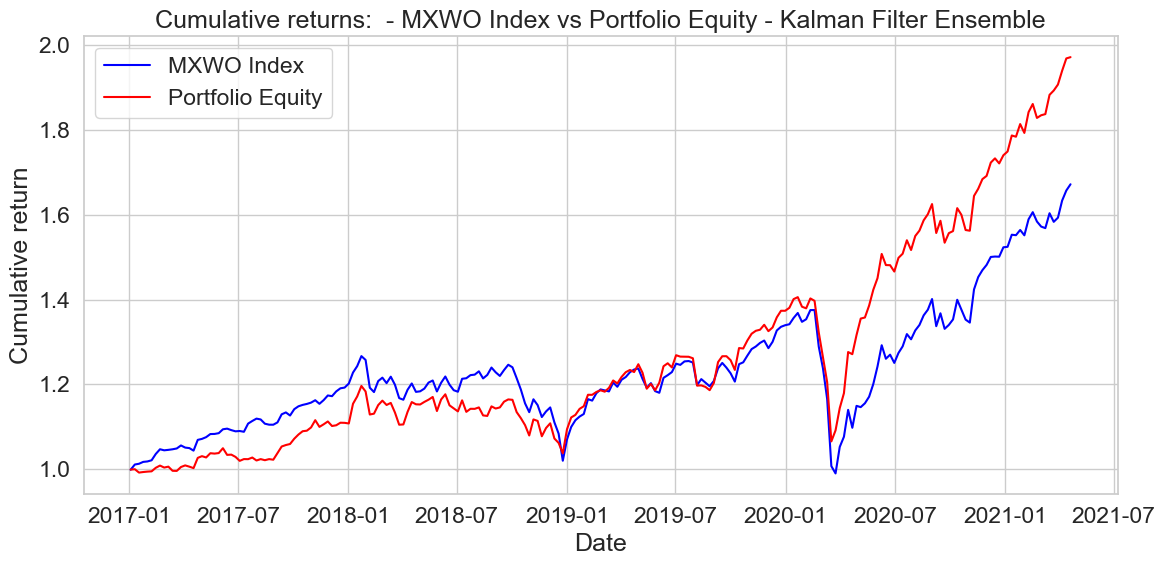

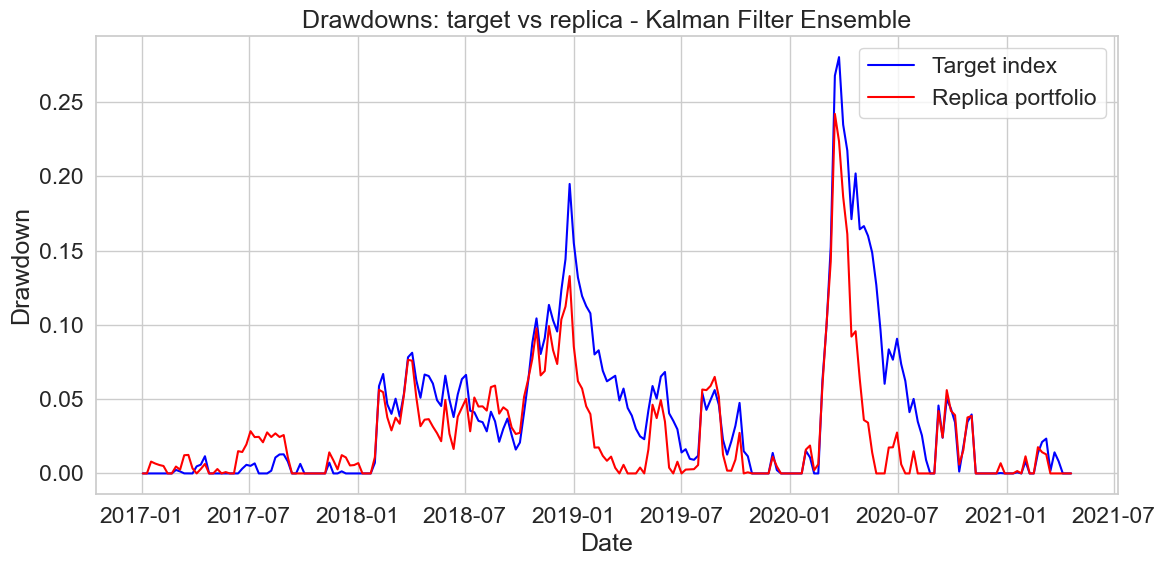

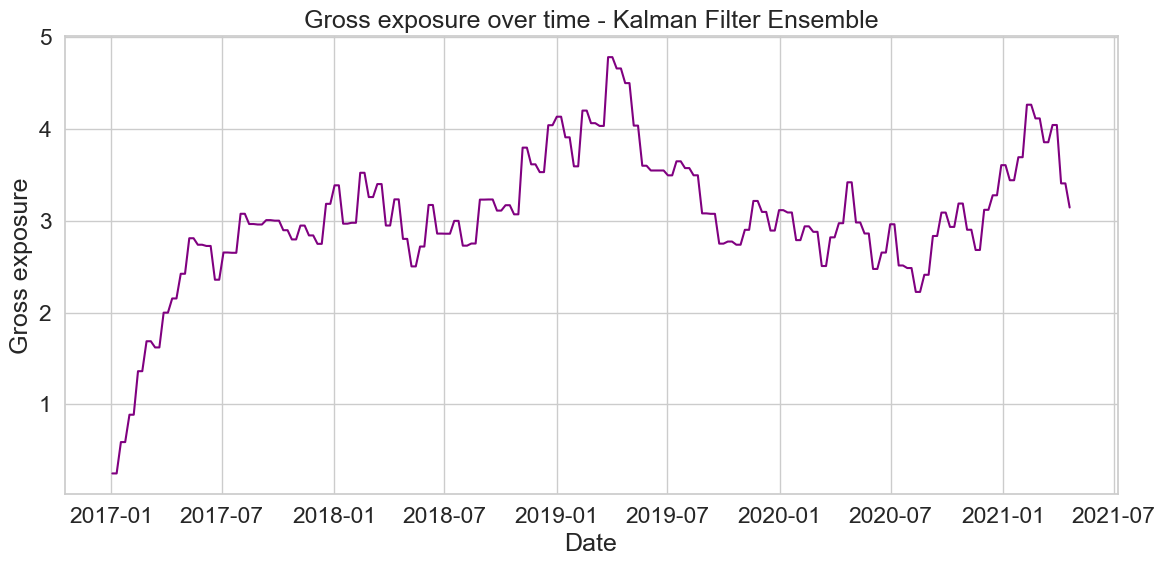

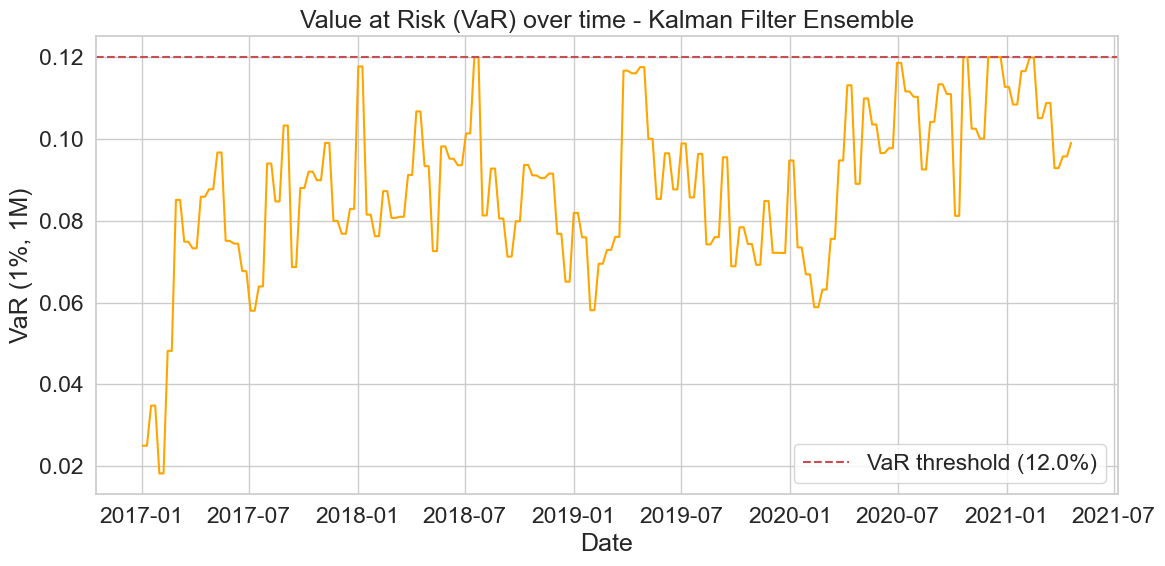

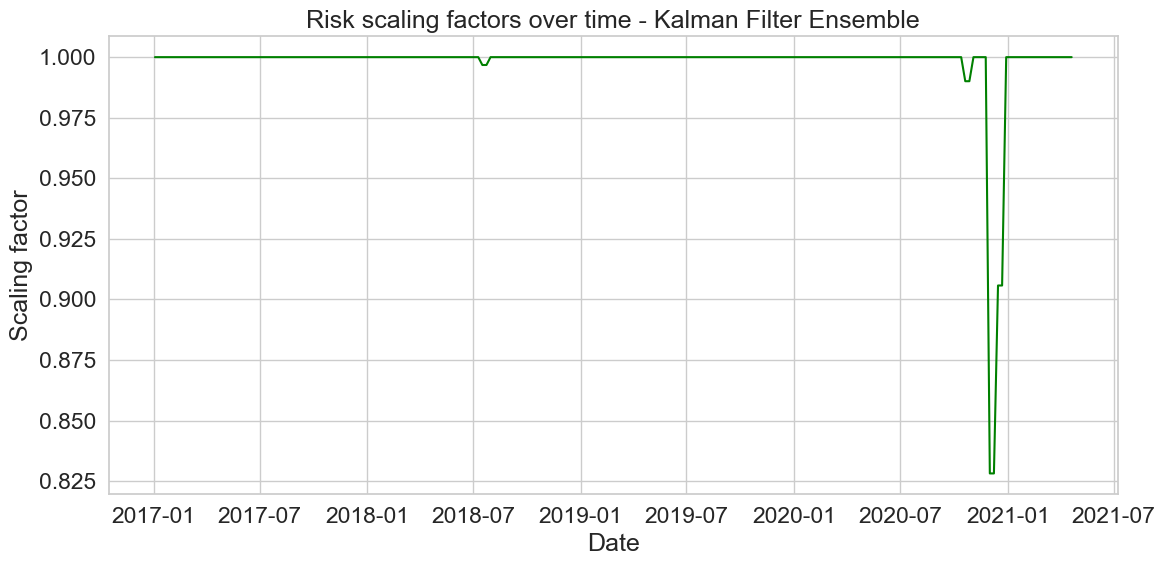

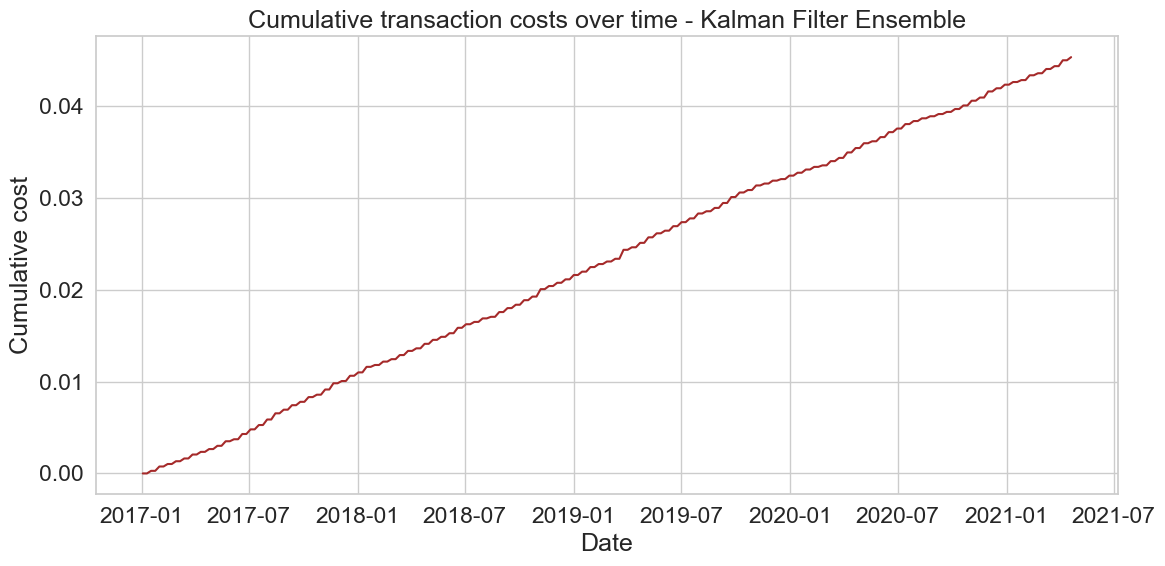

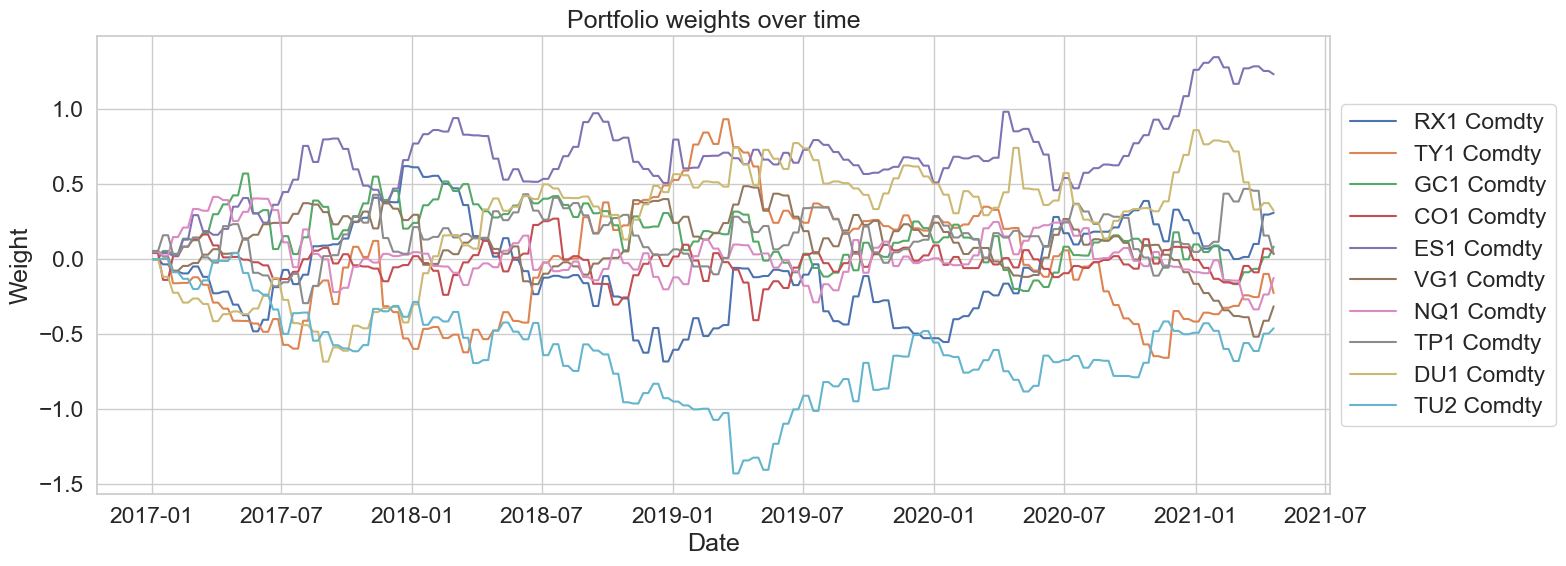

In [21]:
# # Import best parameters from optuna
ensemble_size = study_EnKF.best_trial.params['ensemble_size']
process_noise_scale = study_EnKF.best_trial.params['process_noise_scale']
rolling_window = study_EnKF.best_trial.params['rolling_window']
rebalancing_window = study_EnKF.best_trial.params['rebalancing_window']


# Run the Kalman filter model
result_EnKF = rep.run_ensemble_kalman_filter_model(
    rolling_window=rolling_window,
    rebalancing_window=rebalancing_window,
    ensemble_size=ensemble_size,
    process_noise_scale=process_noise_scale,
    random_state=42,
)

# Create a DataFrame for the results
result_EnKF_df = pd.DataFrame([result_EnKF])

# Display top configuration by information ratio
print("\nTop Optuna configuration by information ratio:")
display(result_EnKF_df[[ 'information_ratio', 'correlation',
                       'tracking_error', 'replica_sharpe', 'avg_gross_exposure', 'avg_var']].head(1))

best_config_normalized_EnKF = result_EnKF_df.iloc[0]


# Create detailed metrics table for the best configuration
metrics_normalized_EnKF = pd.DataFrame({
    'Metric': ['Annualized return', 'Annualized volatility', 'Sharpe ratio',
               'Max Drawdown', 'Tracking Error', 'Information ratio',
               'Correlation', 'Average gross exposure', 'Average VaR (1%, 1M)'],
    'Target': [f"{best_config_normalized_EnKF['target_return']*100:.2f}%",
               f"{best_config_normalized_EnKF['target_vol']*100:.2f}%",
               f"{best_config_normalized_EnKF['target_sharpe']:.2f}",
               f"{best_config_normalized_EnKF['target_max_drawdown']*100:.2f}%",
               "N/A",
               "N/A",
               "N/A",
               "N/A",
               "N/A"],
    'Replica': [f"{best_config_normalized_EnKF['replica_return']*100:.2f}%",
                f"{best_config_normalized_EnKF['replica_vol']*100:.2f}%",
                f"{best_config_normalized_EnKF['replica_sharpe']:.2f}",
                f"{best_config_normalized_EnKF['max_drawdown']*100:.2f}%",
                f"{best_config_normalized_EnKF['tracking_error']*100:.2f}%",
                f"{best_config_normalized_EnKF['information_ratio']:.2f}",
                f"{best_config_normalized_EnKF['correlation']:.4f}",
                f"{best_config_normalized_EnKF['avg_gross_exposure']:.4f}",
                f"{best_config_normalized_EnKF['avg_var']*100:.2f}%"]
})

print("\nDetailed metrics for the best configuration (normalized returns):")
display(metrics_normalized_EnKF)

# Plot the results for the best configuration
rep.plot_metrics(best_config_normalized_EnKF, 'Kalman Filter Ensemble')


## 3.6 Model Comparison and Analysis

In this section, we compare the performance of all implemented portfolio replication strategies: Equally Weighted, Elastic Net, Kalman Filter, and Ensemble Kalman Filter. The comparison is based on a comprehensive set of risk and return metrics, including annualized return, volatility, Sharpe ratio, maximum drawdown, tracking error, information ratio, correlation, average gross exposure, and average Value at Risk (VaR).

**What this cell does:**
- Aggregates the key performance metrics for each model into a single DataFrame for side-by-side comparison.
- Displays the comparison table to highlight the strengths and weaknesses of each approach relative to the target portfolio.
- Provides a clear overview to support the selection of the most effective replication strategy under different market conditions.

This analysis helps to identify which model best replicates the target portfolio and under what circumstances each method may be preferred.


In [22]:
# Build full comparison table
# window=52

all_models_metrics = [
    rep.extract_target_metrics(window),
    rep.extract_replica_metrics(results_equal_weighted, 'Equally Weighted'),
    rep.extract_replica_metrics(results_df_normalized_EN.iloc[0].to_dict(), 'Elastic Net Normalized'),
    rep.extract_replica_metrics(best_config_normalized_KF.to_dict(), 'Kalman Filter'),
    rep.extract_replica_metrics(best_config_normalized_EnKF.to_dict(), 'Ensemble Kalman Filter')
]

comparison_df = pd.DataFrame(all_models_metrics)

# Display
print("\nFull Performance Comparison (with consistent Target Portfolio metrics):")
display(comparison_df)



Full Performance Comparison (with consistent Target Portfolio metrics):


,Model,Annualized return,Annualized volatility,Sharpe ratio,Max Drawdown,Tracking Error,Information ratio,Correlation,Average gross exposure,"Average VaR (1%, 1M)",Transaction cost (bp)
0,Target Portfolio,12.99%,14.66%,0.89,28.04%,N/A,N/A,N/A,N/A,N/A,NaN
1,Equally Weighted,8.38%,9.44%,0.89,17.36%,8.67%,-0.53,0.8268,1.0000,N/A,50.00
2,Elastic Net Normalized,14.55%,13.20%,1.10,20.15%,4.40%,0.35,0.9554,0.8560,7.55%,17.41
3,Kalman Filter,13.58%,13.96%,0.97,24.45%,3.42%,0.17,0.9726,1.4776,7.94%,111.10
4,Ensemble Kalman Filter,16.73%,14.18%,1.18,24.22%,6.10%,0.61,0.9112,3.0450,8.79%,453.56


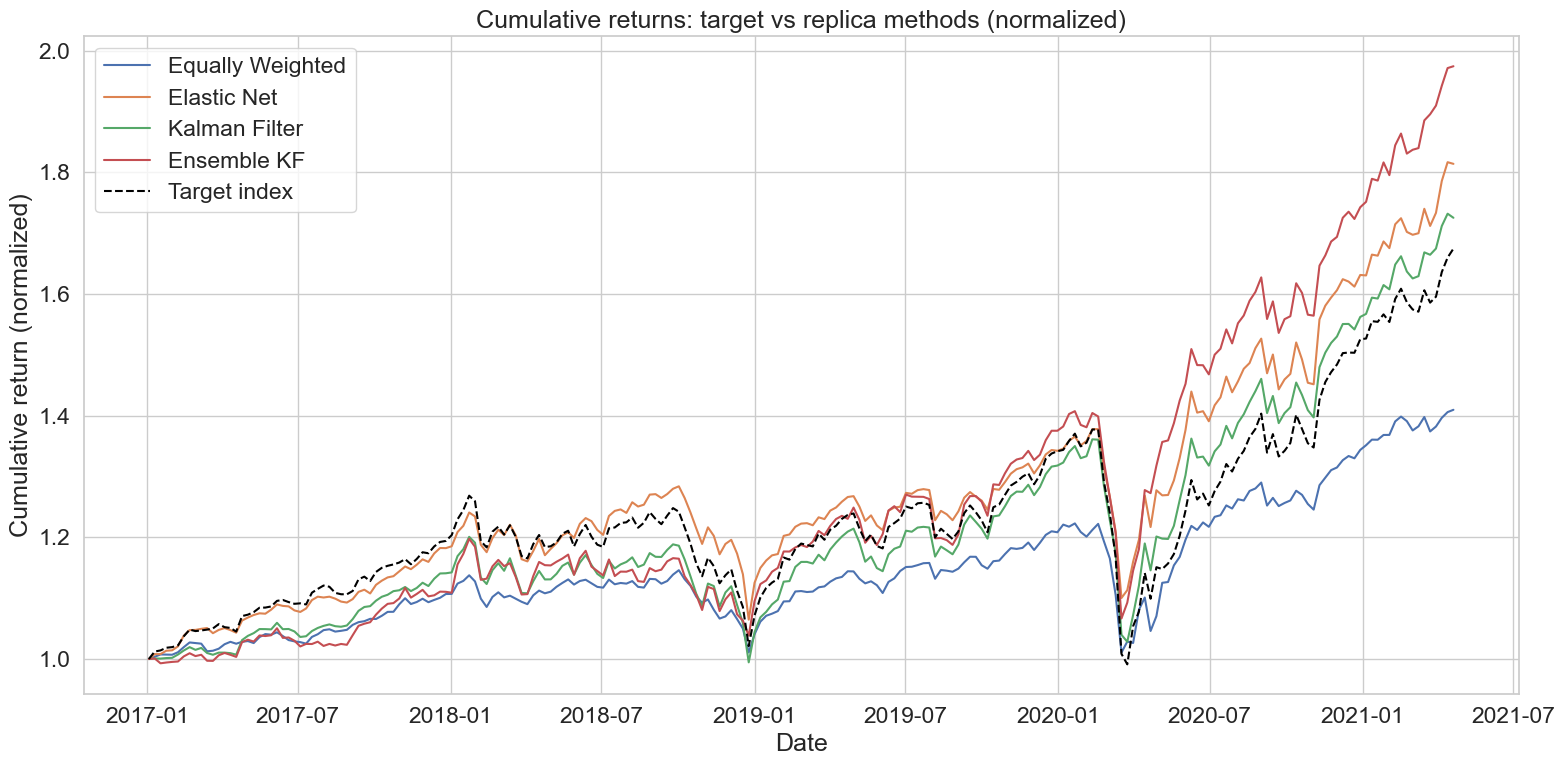

In [23]:
all_results = {
    'Equally Weighted' : results_equal_weighted,
    'Elastic Net'      : results_df_normalized_EN.iloc[0],
    'Kalman Filter'    : best_config_normalized_KF,
    'Ensemble KF'      : result_EnKF
}
rep.plot_comparison(all_results)


## 3.7 Discrete Portfolio Allocation and Transaction Cost Analysis

In this section, we transition from continuous portfolio weights to a **discrete allocation approach**, where portfolio weights are translated into actual positions based on a fixed portfolio value. This is a more realistic scenario, as it accounts for the practical constraints of trading and rebalancing in real markets.

**What these cells do:**
- Convert the continuous weights from each replication model (Elastic Net, Kalman Filter, Ensemble Kalman Filter) into discrete positions, considering a fixed portfolio value and transaction costs.
- Calculate the **Total Expense Ratio (TER)** for each strategy, which represents the annualized transaction costs as a percentage of the portfolio value.
- Display the total and annualized transaction costs, as well as the TER, for each approach.
- Plot and compare the normalized equity curves of the discrete replica portfolios against the target and continuous replica portfolios.

This analysis provides insight into the real-world implementation costs of each replication strategy and highlights the impact of transaction costs and discrete trading on portfolio performance.


In [24]:
# Portfolio value
portfolio_value = 10_000_000 
transaction_cost = 0.0005  # 0.05% transaction costs


Total transaction cost on the dataset: 34886.3256
Annualized average transaction cost: 8062.6175
Total Expense Ratio (TER) per annum: 0.0806%

Position History (first rows):


,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
2017-01-03,1,1,1,1,2867,1,388,1,1,1
2017-01-10,1,1,1,1,2853,1,378,1,1,1
2017-01-17,1,1,1,1,2854,1,377,1,1,1
2017-01-24,1,1,1,1,2839,1,373,1,1,1
2017-01-31,1,1,1,1,2729,1,417,1,1,1


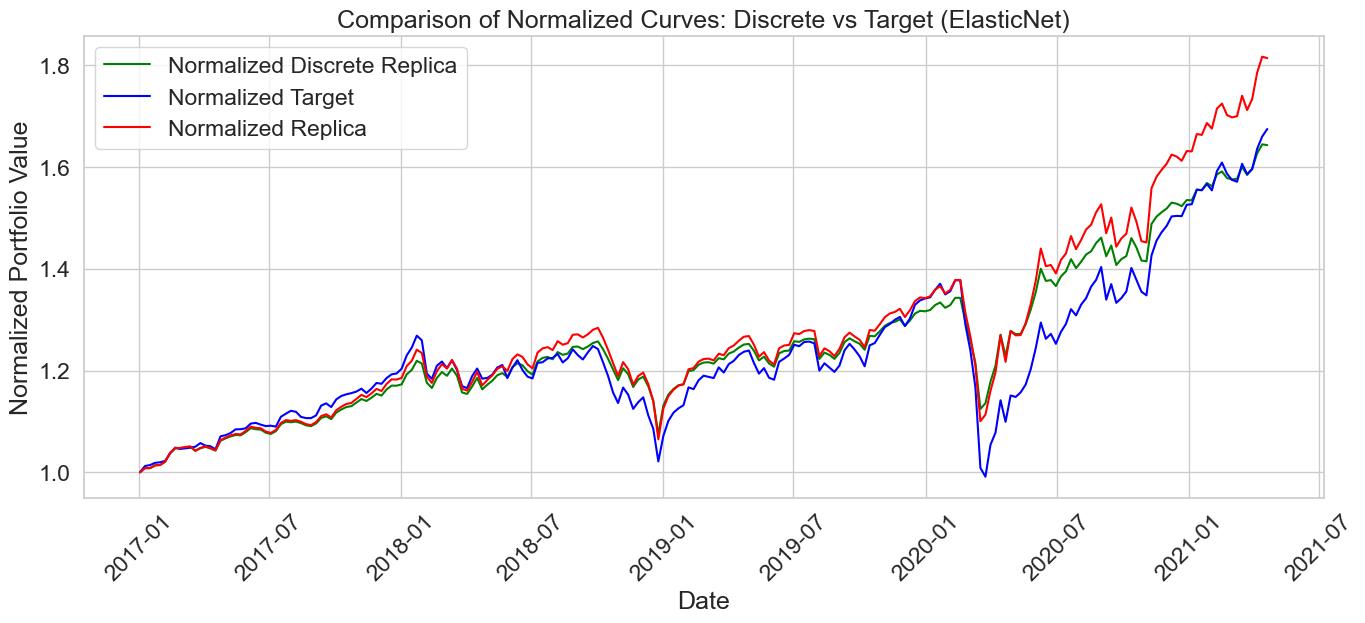

In [25]:
# ElasticNet Portfolio Allocation

total_cost_EN, annual_cost_EN, positions_history_df_EN = rep.compute_discrete_transaction_costs(
    result=results_EN,
    portfolio_value=portfolio_value,
    prices_df=df_underlyings,
    transaction_cost_rate=transaction_cost,
    rebalancing_freq=52
)

# Compute the TER (Total Expense Ratio) for the Elastic Net model per annum
TER_EN = annual_cost_EN / portfolio_value * 100  # in percentage

print("Total transaction cost on the dataset: {:.4f}".format(total_cost_EN))
print("Annualized average transaction cost: {:.4f}".format(annual_cost_EN))
print("Total Expense Ratio (TER) per annum: {:.4f}%".format(TER_EN))
print("\nPosition History (first rows):")
display(positions_history_df_EN.head())

# Calculate the cumulative equity curve for the discrete strategy
cumulative_equity_curve = rep.compute_cumulative_equity_curve(positions_history_df_EN, data[futures_contracts], portfolio_value)

# Normalize the discrete curve so it starts from 1
normalized_discrete_curve = cumulative_equity_curve / cumulative_equity_curve.iloc[0]

# Retrieve the target curve from the model result
target_curve = results_EN['cumulative_target']

# If needed, the target can also be normalized (optional); for example:
normalized_target_curve = target_curve / target_curve.iloc[0]

# Retrive the replica curve with the optimized weights
replica_curve = results_EN['cumulative_replica']
normalized_replica_curve = replica_curve / replica_curve.iloc[0]

plt.figure(figsize=(16, 6))
plt.plot(normalized_discrete_curve.index, normalized_discrete_curve.values, label='Normalized Discrete Replica', color='green')
plt.plot(normalized_target_curve.index, normalized_target_curve.values, label='Normalized Target', color='blue')
plt.plot(normalized_replica_curve.index, normalized_replica_curve.values, label='Normalized Replica', color='red')

plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")
plt.title("Comparison of Normalized Curves: Discrete vs Target (ElasticNet)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


Total transaction cost on the dataset: 128341.1983
Annualized average transaction cost: 29661.0769
Total Expense Ratio (TER) per annum: 0.2966%

Position History (first rows):


,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
2017-01-03,22,-193,2,7375,201,166,103,357,-5,-39
2017-01-10,22,-192,2,7627,201,167,101,351,-5,-39
2017-01-17,22,-191,2,7375,201,168,100,360,-5,-39
2017-01-24,22,-193,2,7379,200,168,99,359,-5,-39
2017-01-31,-739,-479,963,-1418,377,57,401,535,-364,90


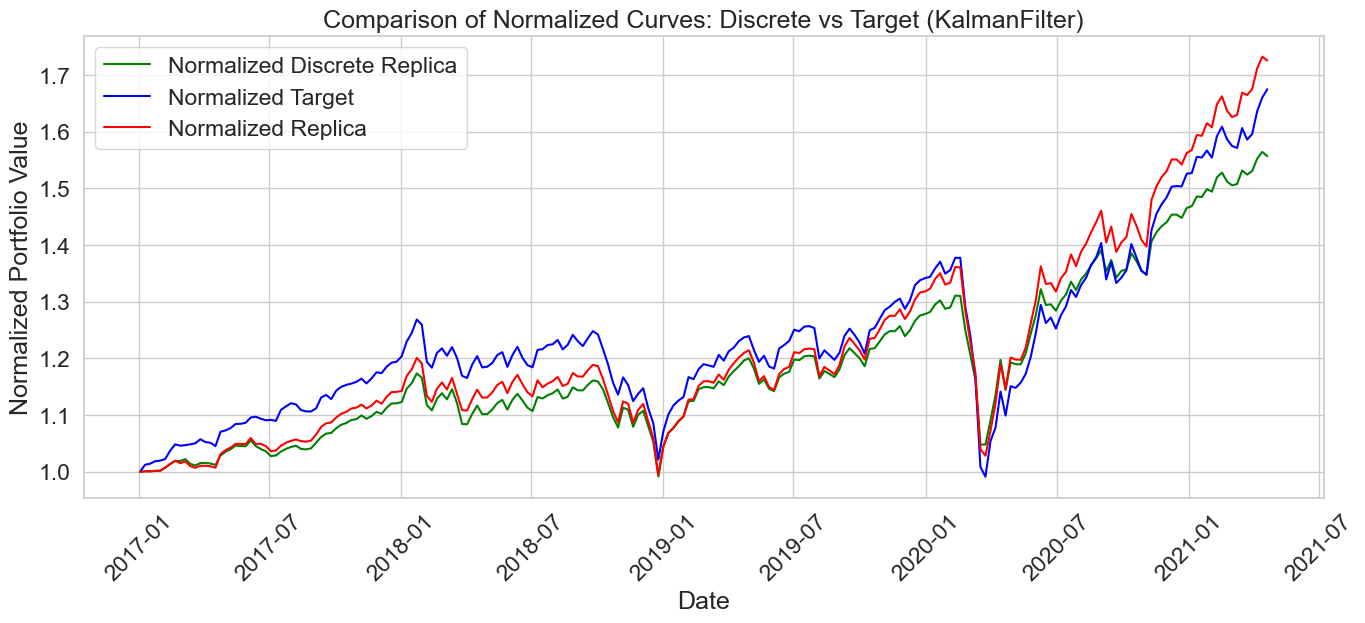

In [26]:
total_cost_KF, annual_cost_KF, positions_history_df_KF = rep.compute_discrete_transaction_costs(
    result=result_KF,
    portfolio_value=portfolio_value,
    prices_df=data[futures_contracts],
    transaction_cost_rate=transaction_cost,
    rebalancing_freq=52
)

# Compute the TER (Total Expense Ratio) for the Kalman Filter model per annum
TER_KF = annual_cost_KF / portfolio_value * 100  # in percentage

print("Total transaction cost on the dataset: {:.4f}".format(total_cost_KF))
print("Annualized average transaction cost: {:.4f}".format(annual_cost_KF))
print("Total Expense Ratio (TER) per annum: {:.4f}%".format(TER_KF))
print("\nPosition History (first rows):")
display(positions_history_df_KF.head())

# Calculate the cumulative equity curve for the discrete strategy
cumulative_equity_curve = rep.compute_cumulative_equity_curve(positions_history_df_KF, data[futures_contracts], portfolio_value)

# Normalize the discrete curve so it starts from 1
normalized_discrete_curve = cumulative_equity_curve / cumulative_equity_curve.iloc[0]

# Retrieve the target curve from the model result
target_curve = result_KF['cumulative_target']

# If needed, the target can also be normalized (optional); for example:
normalized_target_curve = target_curve / target_curve.iloc[0]

# Retrive the replica curve with the optimized weights
replica_curve = result_KF['cumulative_replica']
normalized_replica_curve = replica_curve / replica_curve.iloc[0]

plt.figure(figsize=(16, 6))
plt.plot(normalized_discrete_curve.index, normalized_discrete_curve.values, label='Normalized Discrete Replica', color='green')
plt.plot(normalized_target_curve.index, normalized_target_curve.values, label='Normalized Target', color='blue')
plt.plot(normalized_replica_curve.index, normalized_replica_curve.values, label='Normalized Replica', color='red')

plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")
plt.title("Comparison of Normalized Curves: Discrete vs Target (KalmanFilter)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


Total transaction cost on the dataset: 470807.5368
Annualized average transaction cost: 108808.8529
Total Expense Ratio (TER) per annum: 1.0881%

Position History (first rows):


,RX1 Comdty,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Comdty,VG1 Comdty,NQ1 Comdty,TP1 Comdty,DU1 Comdty,TU2 Comdty
2017-01-03,22,-193,2,7375,201,166,103,357,-5,-39
2017-01-10,22,-192,2,7627,201,167,101,351,-5,-39
2017-01-17,-2114,60,450,-24889,183,53,48,1060,-10454,257
2017-01-24,-2129,61,451,-24902,182,53,48,1056,-10466,257
2017-01-31,-5169,-12892,296,3500,95,-237,289,210,-19948,-8077


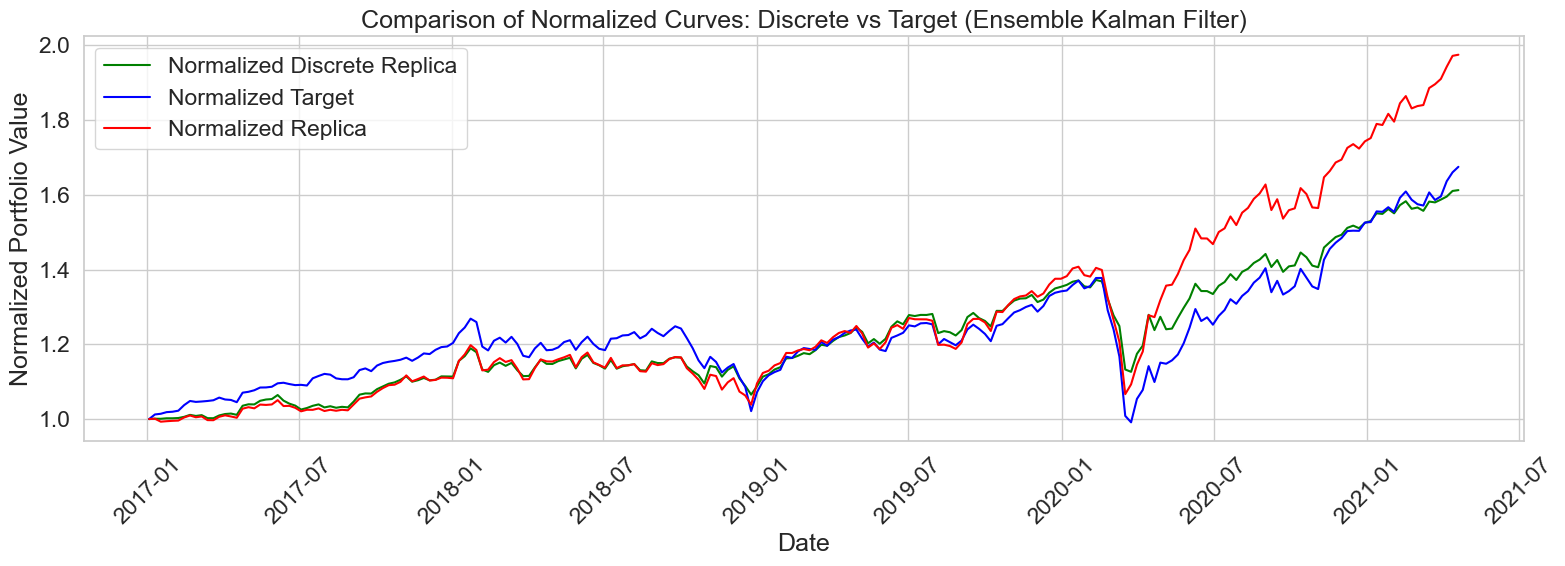

In [27]:
# Ensemble Kalman Filter Portfolio Allocation

total_cost_EnKF, annual_cost_EnKF, positions_history_df_EnKF = rep.compute_discrete_transaction_costs(
    result=result_EnKF,
    portfolio_value=portfolio_value,
    prices_df=data[futures_contracts],
    transaction_cost_rate=transaction_cost,
    rebalancing_freq=52
)

# Compute the TER (Total Expense Ratio) for the Ensemble Kalman Filter model per annum
TER_EnKF = annual_cost_EnKF / portfolio_value * 100  # in percentage

print("Total transaction cost on the dataset: {:.4f}".format(total_cost_EnKF))
print("Annualized average transaction cost: {:.4f}".format(annual_cost_EnKF))
print("Total Expense Ratio (TER) per annum: {:.4f}%".format(TER_EnKF))
print("\nPosition History (first rows):")
display(positions_history_df_EnKF.head())

# Calculate the cumulative equity curve for the discrete strategy
cumulative_equity_curve = rep.compute_cumulative_equity_curve(positions_history_df_EnKF, data[futures_contracts], portfolio_value)

# Normalize the discrete curve so it starts from 1
normalized_discrete_curve = cumulative_equity_curve / cumulative_equity_curve.iloc[0]

# Retrieve the target curve from the model result
target_curve = result_EnKF['cumulative_target']

# If needed, the target can also be normalized (optional); for example:
normalized_target_curve = target_curve / target_curve.iloc[0]

# Retrive the replica curve with the optimized weights
replica_curve = result_EnKF['cumulative_replica']
normalized_replica_curve = replica_curve / replica_curve.iloc[0]

plt.figure(figsize=(16, 6))
plt.plot(normalized_discrete_curve.index, normalized_discrete_curve.values, label='Normalized Discrete Replica', color='green')
plt.plot(normalized_target_curve.index, normalized_target_curve.values, label='Normalized Target', color='blue')
plt.plot(normalized_replica_curve.index, normalized_replica_curve.values, label='Normalized Replica', color='red')
plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")
plt.title("Comparison of Normalized Curves: Discrete vs Target (Ensemble Kalman Filter)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---
<a id="sec-4-anomaly-detection"></a>
# 4. Anomaly Detection


## 4.0 Anomaly Detection Introduction
<a id="sec-40-anomaly-detection-introduction"></a>

This section identifies market stress events in `Dataset4_EWS.xlsx` and studies whether those signals can improve the risk management of the replica portfolios.

A central methodological point is that **the data transformation defines what an anomaly means**. We therefore maintain two complementary channels rather than forcing a single definition:

1. **Shock channel**: price-like variables are represented by log returns and interest rates by first differences. An anomaly means an unusually large market move.
2. **Level / regime channel**: causal rolling level z-scores and drawdowns describe whether the market state itself is unusually far from its recent history. This can capture persistent deterioration even when no individual weekly return is extreme.

The labelled events are filtered to retain portfolio-relevant negative risk episodes. All model pipelines use chronological train/validation/test splits, scaling fitted on the training period only, validation-only hyperparameter/threshold selection, and a final untouched test evaluation.

### Shock-channel models

#### A. MLP Classifier
A basic MLP and an Optuna-tuned MLP are evaluated on the stationary shock representation.

#### B. LSTM Autoencoder
A one-class / semi-supervised LSTM autoencoder is trained only on fully normal causal windows. Validation labels are used to tune hyperparameters and calibrate the reconstruction-error threshold.

#### C. LSTM Classifier
A supervised LSTM classifier produces one causal probability per date from a sequence ending at that date. Both the conventional 0.5 threshold and the validation-calibrated threshold are reported.

### Level / regime channel

A second Optuna-tuned MLP is trained on causal level features: rolling level z-scores, historical drawdowns and 52/104-week rolling drawdowns for price-like assets, plus level z-scores for rates, VIX and the economic-surprise index.

Finally, the notebook compares the selected shock detector, the level detector, and the fixed `Shock OR Level` rule. If a single portfolio risk signal is required, that signal family is selected using **validation F1 only**.

### Portfolio types

- **Equity Portfolio**: `MXUS`
- **Bond Portfolio**: `LUMSTRUU`, `LUACTRUU`, `EMUSTRUU`
- **LifeStrategy 80/20**: `MXUS`, `LUMSTRUU`, `LUACTRUU`, `EMUSTRUU`


###  Settings of the section

Select the number of trials in the Optuna Hyperparameters Tuning and check that the flag of the desired portfolio has been correctly selected. 


In [28]:
# Define the Optuna number of trials.
# Keep this > 0 when creating a new study. After a study contains COMPLETE
# trials, setting it to 0 is allowed if you only want to reload the stored study.
optuna_n_trials = 5

# Select the type of portfolio: 1 for Equity, 2 for Bond, 3 for LifeStrategy
# selected_flag = 1

if selected_flag == 1:
    str_flag = "Equity"
    print("Portfolio Equity")
elif selected_flag == 2:
    str_flag = "Bond"
    print("Portfolio Bond")
elif selected_flag == 3:
    str_flag = "LifeStrategy"
    print("Portfolio LifeStrategy")
else:
    str_flag = "Unknown"
    print("Portfolio Unknown")


Portfolio Equity


## 4.1 Anomaly Detection Dataloading and Preprocessing
<a id="sec-41-anomaly-detection-dataloading-and-preprocessing"></a>

This section script is dedicated to loading and preprocessing the financial dataset used for anomaly detection and subsequent analyses. The primary dataset is stored in the Excel file `Dataset4_EWS.xlsx`, which contains:

- **Market Data**: Located in the `'Markets'` sheet, containing time series data of various indices and an anomaly label column (`Y`).
- **Metadata**: Located in the `'Metadata'` sheet, providing additional descriptive information about the dataset.


This preprocessed data serves as the input for subsequent anomaly detection and evaluation steps in the analysis.


In [29]:
# Helper module import
import sys
import os

# Get the current working directory (for Jupyter notebooks)
current_dir = os.getcwd()

# Define the relative path to the helper directory
helper_dir = os.path.join(current_dir, "AnomalyDetection")

# Add the helper directory to sys.path if not already there
if helper_dir not in sys.path:
    sys.path.append(helper_dir)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from AnomalyDetectionHelper import AnomalyDetectionEDA

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

# Dataset Anomaly Detection
path_BC4 = 'Dataset4_EWS.xlsx'

# Get current working directory
current_dir = os.getcwd()

# Add the path to the dataset
file_path = os.path.join(current_dir, "Datasets", path_BC4)

# Load the data from the Excel file
# First sheet contains market data with dates and anomaly labels, second sheet contains metadata
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Check the structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy

# Set date as index
data_df = data_df.set_index(date_col)

# Extract features (all columns except Y if it exists)
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col]
else:
    X_df = data_df
    y = None

# Display basic information about the dataset
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")


Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']
Data shape: (1111, 42)
Total number of records: 1111
Time period: from 01/11/2000 to 04/20/2021
Frequency: W-TUE
Number of variables: 42
Number of anomalies: 237 (21.33%)


## 4.2 Anomaly Detection EDA
<a id="sec-42-anomaly-detection-eda"></a>

#### Initializing the Anomaly Detection Helper Class

In this cell, we initialize the `AnomalyDetectionEDA` class, which has been imported from an external helper module. This class is designed to streamline exploratory data analysis (EDA) for anomaly detection in financial time series data.

We perform two key steps using this class:
1. **Generating Enhanced Metadata:**  
   The `generate_metadata()` method computes basic descriptive statistics for each feature and combines them with metadata to provide a comprehensive overview.
   
2. **Visualizing Anomalies:**  
   The `plot_anomalies()` method plots the time series data for a specified index (in this case, `'EMUSTRUU'`) and highlights periods identified as anomalies.

This workflow provides a solid foundation for understanding the dataset’s structure and visualizing potential anomaly periods.



Enhanced Metadata:


,Ticker,Description,Mean,Std.Dev,Min,Max,Missing values,Missing (%)
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.00000,11793.00000,0,0.00%
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.29290,467.57000,0,0.00%
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.01000,140.97000,0,0.00%
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.32900,119.82000,0,0.00%
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.97400,0.99100,0,0.00%
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.52670,1286.35300,0,0.00%
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.49800,5.73000,0,0.00%
7,GBP,British Pound Spot,1.569618,0.212340,1.17230,2.08520,0,0.00%
8,GT10,US TREASURY N/B,3.266748,1.332464,0.50800,6.74800,0,0.00%
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.79400,5.64400,0,0.00%


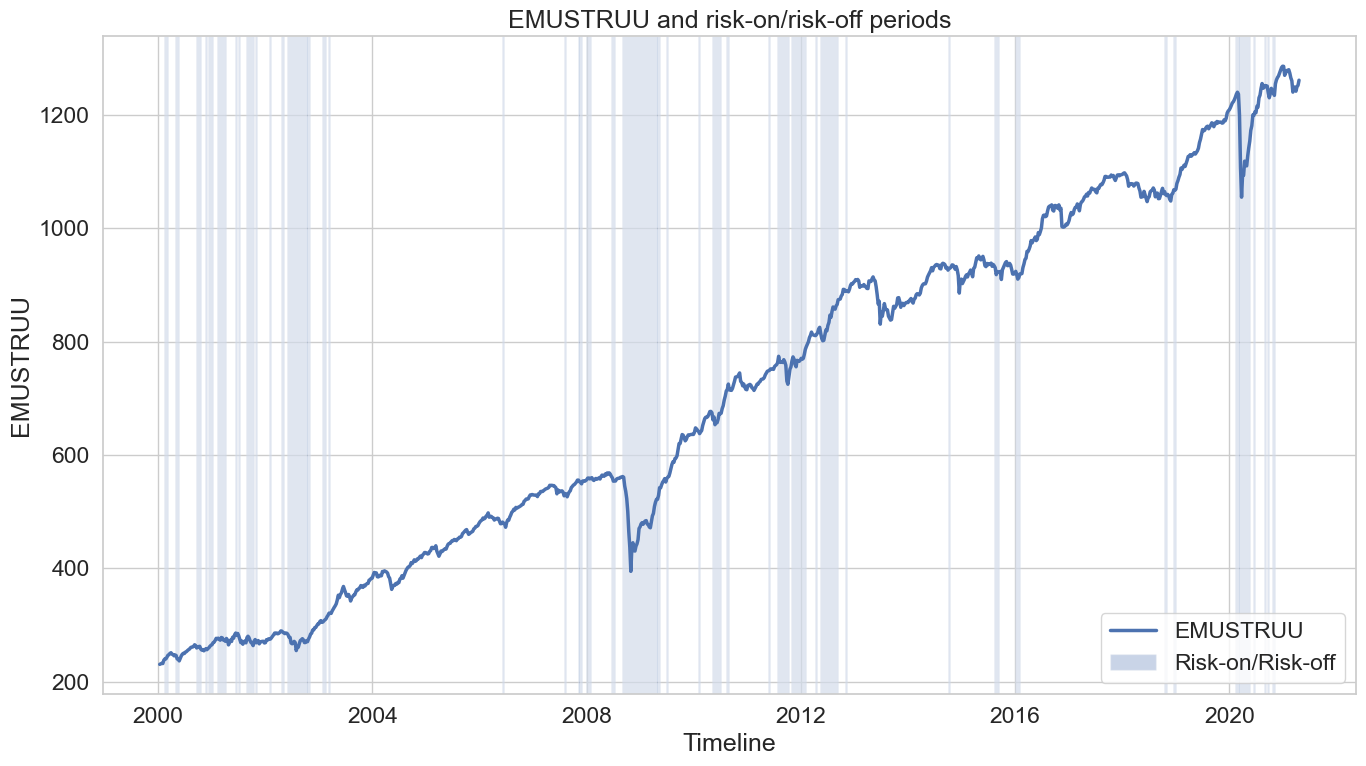

In [31]:
# Initialize the AnomalyDetectionEDA class with the loaded data
eda = AnomalyDetectionEDA(data_df=data_df, metadata_df=metadata_df, X_df=X_df, y=y)

# Generate metadata for the dataset to better understand the features
meta_df = eda.generate_metadata()

# Plot the time series data highlighting anomalies
eda.plot_anomalies(index_col='EMUSTRUU')


#### Anomalies Filtering

In this step, we focus on detecting anomalies that are specifically relevant to the assets higly correlated with our portfolio. By selecting only the columns corresponding to our portfolio holdings, we ensure that the anomaly detection process highlights unusual events that could directly impact our investment strategy.
This targeted approach helps us filter out irrelevant anomalies and concentrate on those that matter most for our portfolio management and risk assessment.


In [32]:
# Select columns based on the selected portfolio type
if selected_flag == 1:  # Portfolio Equity
    cols_to_use = ["MXUS"]
elif selected_flag == 2:  # Portfolio Bond
    cols_to_use = ["LUMSTRUU", "LUACTRUU", "EMUSTRUU"]
elif selected_flag == 3:  # LifeStrategy 80/20
    cols_to_use = ["MXUS", "LUMSTRUU", "LUACTRUU", "EMUSTRUU"]
else:
    raise ValueError("Invalid selected_flag value. Must be 1, 2, or 3.")

# IMPORTANT: use the returned labels downstream. The old implementation changed
# data_df['Y'] but left the standalone y Series untouched.
y = eda.filter_negative_anomalies(cols_to_use=cols_to_use)
data_df.loc[y.index, 'Y'] = y


Number of anomalies with negative returns: 143
Original number of anomalies: 237
Removed non-negative anomalies: 94


#### Assets Analysis

This function visualizes the time series data, returns, distributions, and QQ plots for the specified asset columns.  
It distinguishes between bonds and equity returns, using first differences for bonds and log returns for equities.  
The distribution histograms and QQ plots also help in assessing the normality of returns, revealing deviations from the Gaussian distribution that may indicate risk concentrations or structural breaks.  
These visual insights support further quantitative analyses and validate assumptions about the statistical properties of financial returns.


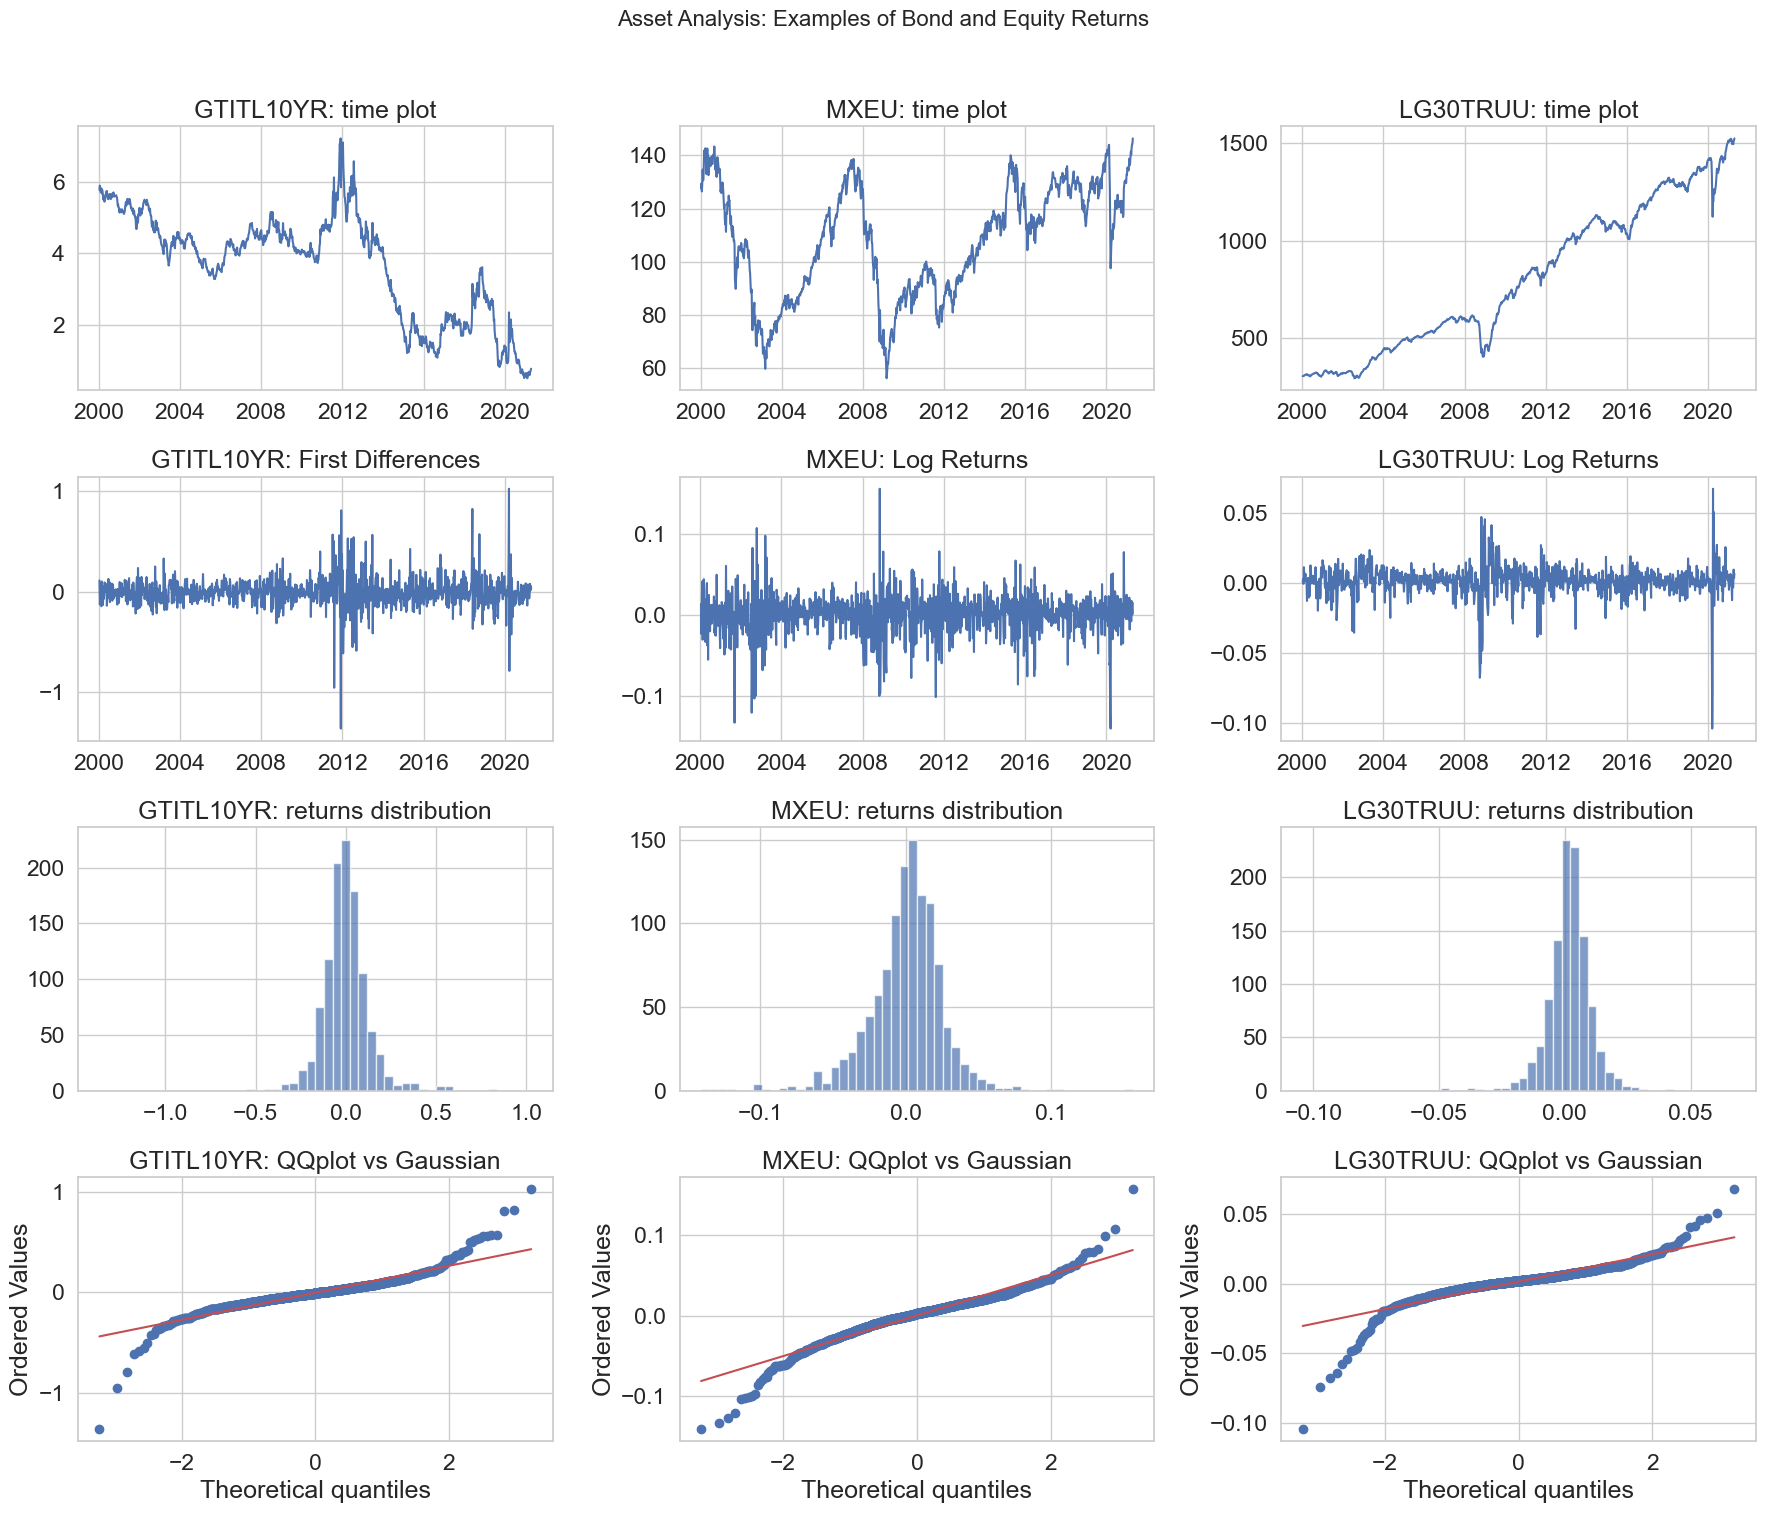

In [33]:
eda.visualize_assets(asset_columns=['GTITL10YR', 'MXEU', 'LG30TRUU'], bonds=['GTITL10YR'])


#### Check for negative Interest Rates

This function plots the distribution of a specified interest rate to check for negative yields.  
This helps identify unusual interest rate patterns that may affect investment decisions. This is particularly important for the stationarity analysis.


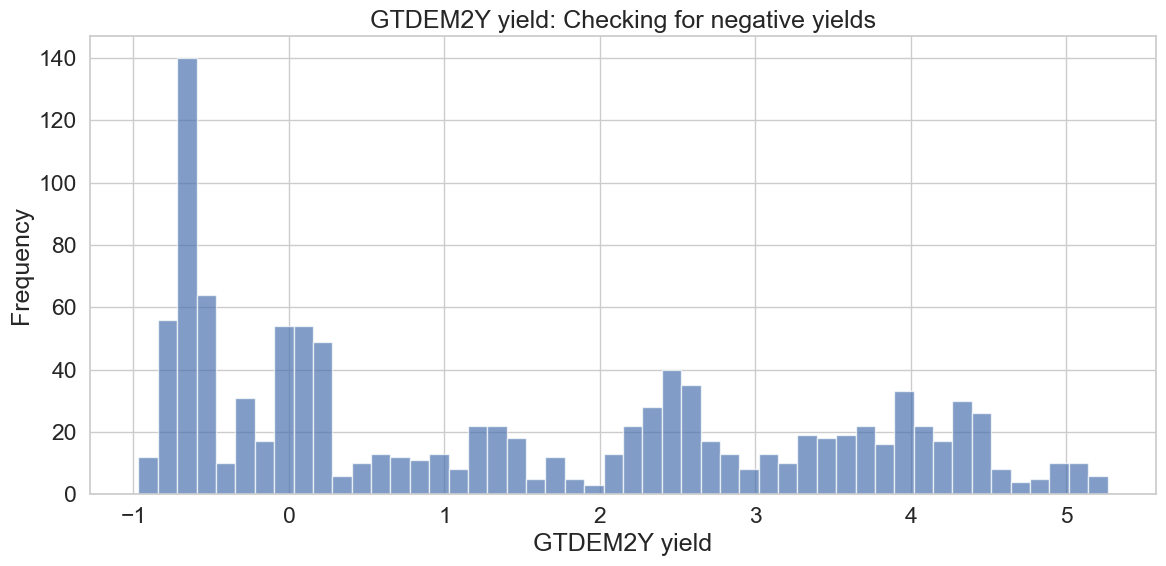

In [34]:
eda.plot_interest_rate_distribution(column='GTDEM2Y')


#### Stationarity Check
It is important to check for stationarity in financial time series.  
Stationarity ensures that statistical properties such as mean and variance remain constant over time, which is a key assumption for many time series models and analyses.  
The ADF test implemented here evaluates the null hypothesis of non-stationarity, and the test is considered passed (stationary) if the p-value is below 0.05.


In [35]:
eda.adf_stationarity_test()


,ADF Statistic,p-value,Used Lag,Observations Used,Critical Value (1%),Critical Value (5%),Critical Value (10%),Stationary (<0.05 p-value)
ECSURPUS,-6.492085,1.219555e-08,7.0,1103.0,-3.436293,-2.864164,-2.568167,True
VIX,-3.971067,1.569823e-03,11.0,1099.0,-3.436314,-2.864173,-2.568172,True
US0001M,-2.944662,4.039553e-02,22.0,1088.0,-3.436375,-2.864200,-2.568186,True
Cl1,-2.677133,7.807953e-02,8.0,1102.0,-3.436298,-2.864166,-2.568168,False
USGG3M,-2.659706,8.127421e-02,22.0,1088.0,-3.436375,-2.864200,-2.568186,False
USGG2YR,-2.523277,1.099131e-01,6.0,1104.0,-3.436287,-2.864162,-2.568166,False
BDIY,-2.361304,1.529571e-01,21.0,1089.0,-3.436369,-2.864198,-2.568185,False
CRY,-2.349157,1.566033e-01,12.0,1098.0,-3.436320,-2.864176,-2.568173,False
GT10,-2.311268,1.683597e-01,0.0,1110.0,-3.436255,-2.864147,-2.568158,False
MXRU,-2.273079,1.807977e-01,3.0,1107.0,-3.436271,-2.864154,-2.568162,False


#### Evaluate Results Functions

`DetectionMethodsEvaluation` reports precision, recall, F1, ROC/PR diagnostics and a custom Financial Score.

The Financial Score is calibrated **only on the training period**. This is important: using the full dataset to define the error costs would leak validation/test labels into the final test metric.

The score penalizes false negatives more heavily than false positives and can include a fixed cost for each defensive action (`y_pred = 1`). It is normalized relative to perfect classification, so a perfect prediction has score 1. The business weights are computed from standardized, stationary training features grouped by asset class.


## 4.3 MLP for Shock Anomaly Detection
<a id="sec-43-mlp-for-anomaly-detection"></a>

The first anomaly channel is deliberately a **shock detector**. Price-like market series are transformed to log returns and interest-rate series to first differences before modelling. Consequently, an anomaly in this branch means an unusually large market move rather than an unusual absolute market level.

This section implements that shock detector using a **Multi-Layer Perceptron (MLP)**. The MLP learns nonlinear cross-sectional relationships between transformed market variables and the labelled risk events.


### 4.3.1 Simple MLP for Anomaly Detection
<a id="sec-431-simple-mlp-for-anomaly-detection"></a>

In this part, we configure a basic MLP with a predefined architecture to detect anomalies in the dataset.  

The simple MLP model includes multiple layers with decreasing numbers of neurons and uses the ReLU activation function.

This configuration enables the network to capture essential data patterns without overfitting.  
After training, we select the optimal threshold on the validation set to maximize the F1-score for distinguishing between normal and anomalous events.


In [36]:
from AnomalyDetectionHelper import AnomalyDataPreparer

cutoff_date_train = pd.to_datetime('2012-01-01')
cutoff_date_val = pd.to_datetime('2017-01-01')

# Shock channel: price-like series are converted to log returns and rates to first differences.
# Explicit date cutoffs keep the train/validation/test boundaries stable after differencing.
preparer_MLP = AnomalyDataPreparer(
    make_stationary=True,
    shuffle_data=False,
    scale_data=True,
    do_split=True,
    chronological_split=True,
    train_end=cutoff_date_train,
    val_end=cutoff_date_val,
    random_state=42,
)

X_train, y_train, X_val, y_val, X_test, y_test = preparer_MLP.prepare(X_df, y)


Training set size: 624 (517 normal, 107 anomalies)
Validation set size: 261 (242 normal, 19 anomalies)
Test set size: 225 (208 normal, 17 anomalies)


In [37]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, precision_recall_curve

MLP_basic_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64, 32, 16),
    activation='relu',
    solver='adam',
    max_iter=1500,
    early_stopping=False,
    random_state=42,
)
MLP_basic_model.fit(X_train, y_train)

# Calibrate the threshold on VALIDATION only.
Y_val_prob = MLP_basic_model.predict_proba(X_val)[:, 1]
precision_v, recall_v, thresholds_v = precision_recall_curve(y_val, Y_val_prob)
if len(thresholds_v) == 0:
    best_thresh = 0.5
    val_f1_Simple_MLP = 0.0
else:
    p = precision_v[:-1]
    r = recall_v[:-1]
    f1_vals = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    best_idx = int(np.argmax(f1_vals))
    best_thresh = float(thresholds_v[best_idx])
    val_f1_Simple_MLP = float(f1_vals[best_idx])

Y_test_prob_SimpleMLP = MLP_basic_model.predict_proba(X_test)[:, 1]
Y_test_pred_SimpleMLP = (Y_test_prob_SimpleMLP > best_thresh).astype(int)
print(f"Validation F1 (Simple MLP): {val_f1_Simple_MLP:.4f}, threshold={best_thresh:.4f}")


Validation F1 (Simple MLP): 0.4286, threshold=0.7490



--- MLP (Test) ---

MLP (Basic) Performance:
Precision: 0.5625
Recall:    0.5294
F1 Score:  0.5455
Financial Score: 0.6433


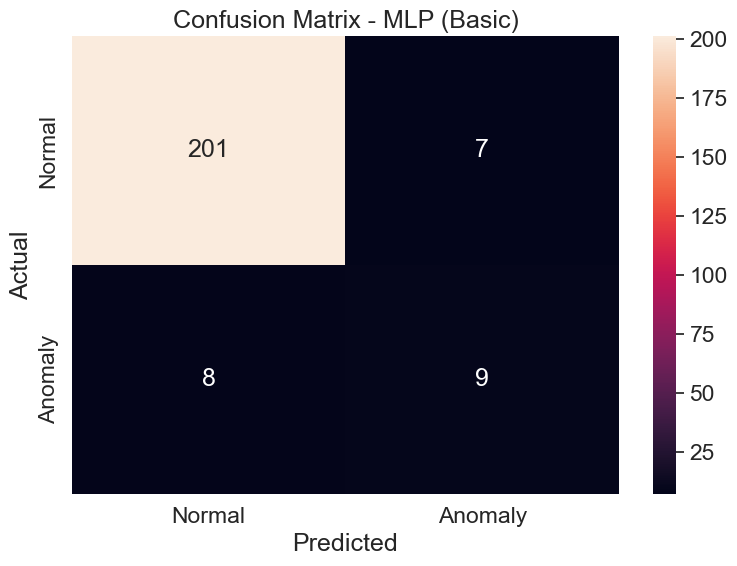

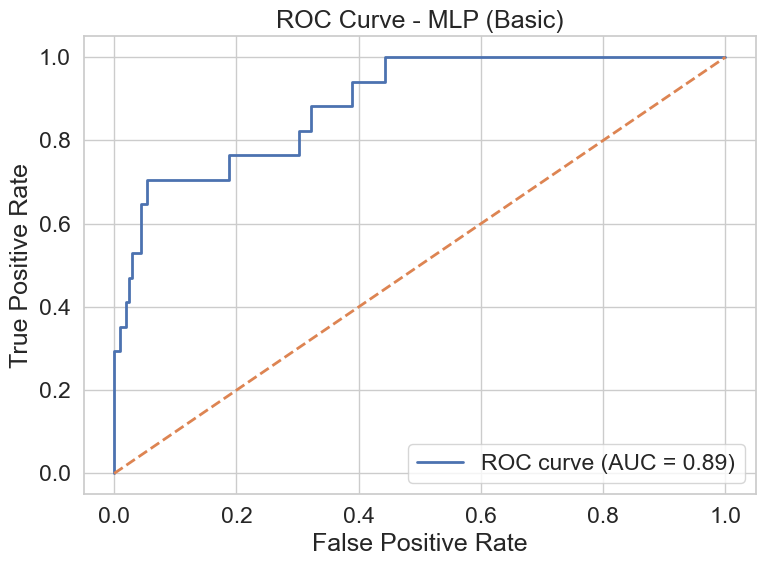

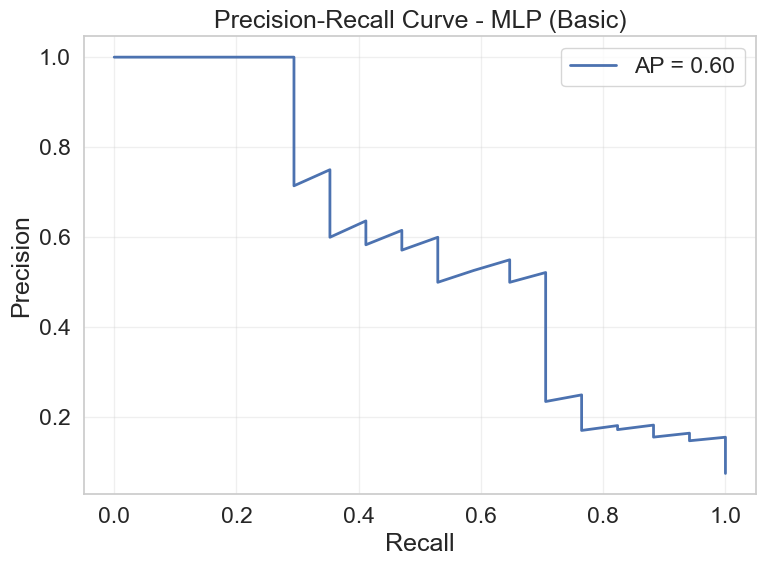

In [38]:
from AnomalyDetectionHelper import DetectionMethodsEvaluation

evaluator_MLP = DetectionMethodsEvaluation(
    preparer=preparer_MLP,
    metadata_df=metadata_df,
    X_df=X_df,
    y=y,
)

print("\n--- MLP (Test) ---")
precision_Simple_MLP, recall_Simple_MLP, f1_Simple_MLP, fin_score_Simple_MLP = evaluator_MLP.evaluate_model(
    y_true=y_test.values,
    y_pred=Y_test_pred_SimpleMLP,
    y_score=Y_test_prob_SimpleMLP,
    model_name='MLP (Basic)',
)

y_test_pred_series_MLP = pd.Series(Y_test_pred_SimpleMLP, index=y_test.index, name='y_pred')
current_dir = os.getcwd()
csv_file_path_MLP_Simple = os.path.join(
    current_dir, "AnomalyDetection", "CSVCalibbratedResults",
    f"{str_flag}_SimpleMLP_detections.csv"
)
os.makedirs(os.path.dirname(csv_file_path_MLP_Simple), exist_ok=True)
y_test_pred_series_MLP.to_csv(csv_file_path_MLP_Simple, index=True)


### 4.3.2 MLP with Optuna Hyperparameter Tuning for Anomaly Detection
<a id="sec-432-mlp-with-optuna"></a>


This section focuses on improving the MLP model’s performance through hyperparameter optimization using Optuna.  

Optuna is a framework that efficiently explores the space of possible configurations (e.g., number of layers, units per layer, learning rate) using Bayesian optimization.  

By systematically tuning these parameters, the MLP can better adapt to the data’s underlying structure, leading to more precise and robust anomaly detection.


In [39]:
from AnomalyDetectionHelper import MLPAnomalyDetector

mlp_detector = MLPAnomalyDetector(input_dim=X_train.shape[1])
current_dir = os.getcwd()
optuna_studies_dir = os.path.join(current_dir, "AnomalyDetection", "OptunaStudies")
os.makedirs(optuna_studies_dir, exist_ok=True)

# v2 database avoids mixing trials produced by the old, inconsistent implementation.
db_file_path = os.path.join(optuna_studies_dir, f"optuna_MLP_{str_flag}_v2.db")
optuna_db_uri_MLP = f"sqlite:///{db_file_path}"

study_MLP = mlp_detector.tune_hyperparameters(
    X_train, y_train, X_val, y_val,
    n_trials=optuna_n_trials,
    storage=optuna_db_uri_MLP,
)
val_f1_Optuna_MLP = float(study_MLP.best_value)

# Refit on TRAIN only. The threshold was calibrated on validation and must not be
# carried unchanged to a model refitted on train+validation.
mlp_detector.train_final_model(X_train, y_train)
y_pred_MLP_Optuna, y_prob_MLP_Optuna = mlp_detector.evaluate_on_test(X_test, y_test)


[I 2026-09-03 12:55:20,824] Using an existing study with name 'MLP_Study_v2' instead of creating a new one.


  0%|          | 0/5 [00:00<?, ?it/s]

Best validation F1: 0.4888888888888889
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 44, 'n_units_l1': 42, 'n_units_l2': 28, 'learning_rate_init': 0.0004091038990191626, 'alpha': 0.000155908647387005}
Best validation threshold: 0.00019965533324761348
Test set performance:
Precision: 0.1509433962264151
Recall: 0.9411764705882353
F1 Score: 0.2601626016260163



--- MLP with Optuna Tuning (Test) ---

MLP (Optuna Tuning) Performance:
Precision: 0.1509
Recall:    0.9412
F1 Score:  0.2602
Financial Score: 0.8437


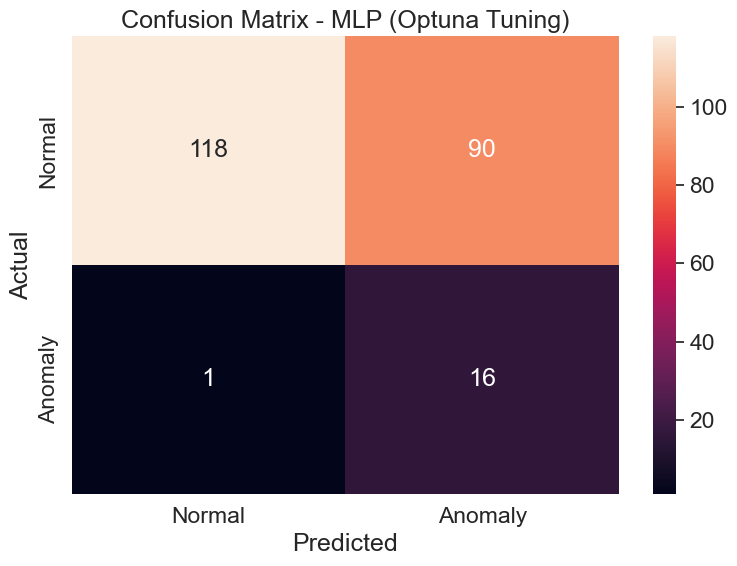

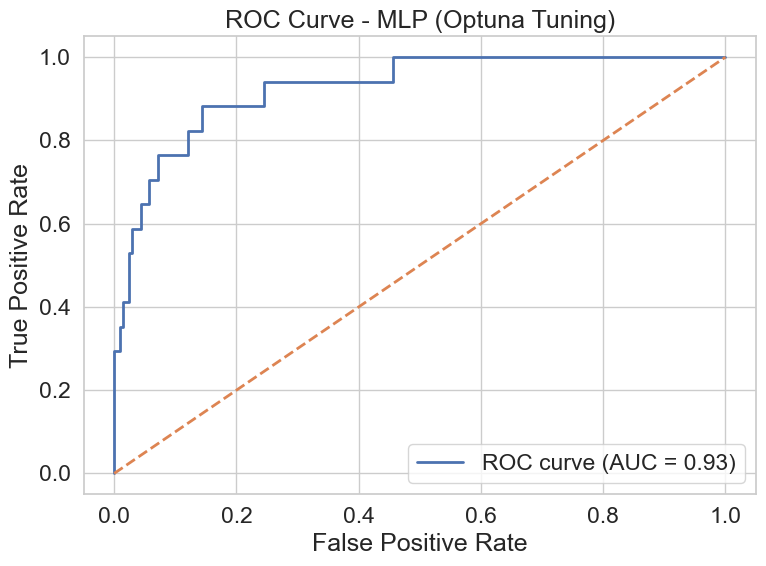

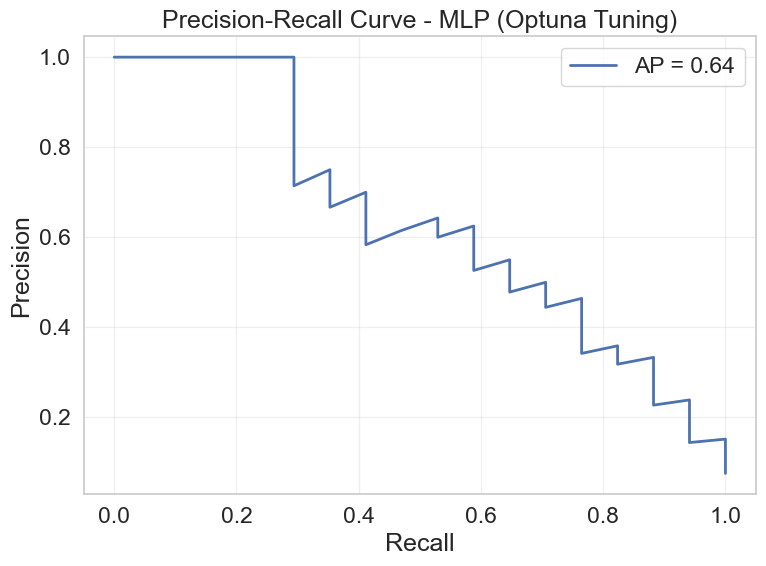

In [40]:
print("\n--- MLP with Optuna Tuning (Test) ---")
precision_Optuna_MLP, recall_Optuna_MLP, f1_Optuna_MLP, fin_score_Optuna_MLP = evaluator_MLP.evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_MLP_Optuna,
    y_score=y_prob_MLP_Optuna,
    model_name='MLP (Optuna Tuning)',
)

y_test_pred_series_MLP_Optuna = pd.Series(y_pred_MLP_Optuna, index=y_test.index, name='y_pred')
current_dir = os.getcwd()
csv_file_path_MLP_Optuna = os.path.join(
    current_dir, "AnomalyDetection", "CSVCalibbratedResults",
    f"{str_flag}_OptunaMLP_detections.csv"
)
os.makedirs(os.path.dirname(csv_file_path_MLP_Optuna), exist_ok=True)
y_test_pred_series_MLP_Optuna.to_csv(csv_file_path_MLP_Optuna, index=True)


## 4.4 LSTM for Shock Anomaly Detection
<a id="sec-44-lstm"></a>

The LSTM models use the same stationary shock representation as the MLP branch, but exploit sequential information.

We consider two approaches:

- **LSTM Autoencoder (One-Class / Semi-Supervised)**: learns normal sequences and flags large causal reconstruction errors.
- **LSTM Classifier (Supervised)**: directly predicts the anomaly label from a sequence ending at the current date.

Both approaches use chronological splits, train-only scaling, validation-only threshold calibration and Optuna hyperparameter tuning.


### 4.4.1 LSTM Autoencoder for One-Class / Semi-Supervised Anomaly Detection
<a id="sec-441-lstm-autoencoder"></a>

The LSTM Autoencoder is trained only on windows that contain **no labelled anomaly**. It learns to reconstruct normal market dynamics and uses reconstruction error as an anomaly score.

The training itself is one-class, while validation labels are used to select hyperparameters and calibrate the decision threshold. For that reason, the statistically accurate description is **one-class / semi-supervised anomaly detection**, rather than fully unsupervised learning.

For real-time validity, the anomaly score at date `t` is computed from a sequence ending at `t`; no future observations are used.


In [41]:
from AnomalyDetectionHelper import AnomalyDataPreparer, LSTMAEAnomalyDetector, DetectionMethodsEvaluation

cutoff_date_train = pd.to_datetime('2012-01-01')
cutoff_date_val = pd.to_datetime('2017-01-01')

preparer_LSTM = AnomalyDataPreparer(
    shuffle_data=False,
    scale_data=True,
    do_split=True,
    chronological_split=True,
    make_stationary=True,
    train_end=cutoff_date_train,
    val_end=cutoff_date_val,
    random_state=42,
)
X_train, y_train, X_val, y_val, X_test, y_test = preparer_LSTM.prepare(X_df, y)

LSTM_detector = LSTMAEAnomalyDetector(input_dim=X_train.shape[1])
current_dir = os.getcwd()
optuna_studies_dir = os.path.join(current_dir, "AnomalyDetection", "OptunaStudies")
os.makedirs(optuna_studies_dir, exist_ok=True)
db_file_path = os.path.join(optuna_studies_dir, f"optuna_LSTM_AE_{str_flag}_v2.db")
optuna_db_uri_AE = f"sqlite:///{db_file_path}"

study_LSTM_AE = LSTM_detector.tune_hyperparameters(
    X_train.to_numpy(), y_train.to_numpy(),
    X_val.to_numpy(), y_val.to_numpy(),
    n_trials=optuna_n_trials,
    storage=optuna_db_uri_AE,
)
val_f1_LSTM_AE = float(study_LSTM_AE.best_value)


Training set size: 624 (517 normal, 107 anomalies)
Validation set size: 261 (242 normal, 19 anomalies)
Test set size: 225 (208 normal, 17 anomalies)


  0%|          | 0/5 [00:00<?, ?it/s]

Best validation F1: 0.3333333333333333
Best params: {'seq_len': 40, 'hidden_dim': 32, 'num_layers': 2, 'lr': 0.0008838150497110887, 'batch_size': 32}
Best threshold: 1.3176292181015015
Best epoch: 9


In [42]:
best_threshold = LSTM_detector.best_threshold
print(f"Best threshold from validation tuning: {best_threshold:.6f}")

# The helper builds training windows internally and keeps ONLY windows with no
# anomaly anywhere in the sequence.
LSTM_detector.train_final_model(X_train.values, y_train.values)

# Use the last validation observations as PAST context for the first test date.
# This gives one causal score per test row without discarding seq_len-1 test dates.
y_pred_LSTM, test_err_LSTM = LSTM_detector.evaluate_on_test(
    X_test.values,
    best_threshold=best_threshold,
    X_context=X_val.values,
)


Best threshold from validation tuning: 1.317629
Epoch 1/9 - Loss: 0.577286
Epoch 2/9 - Loss: 0.571915
Epoch 3/9 - Loss: 0.566791
Epoch 4/9 - Loss: 0.562772
Epoch 5/9 - Loss: 0.560451
Epoch 6/9 - Loss: 0.558845
Epoch 7/9 - Loss: 0.557715
Epoch 8/9 - Loss: 0.556745
Epoch 9/9 - Loss: 0.555657



--- LSTM Autoencoder (Test) ---

LSTM Autoencoder Performance:
Precision: 0.3333
Recall:    0.3529
F1 Score:  0.3429
Financial Score: 0.5065


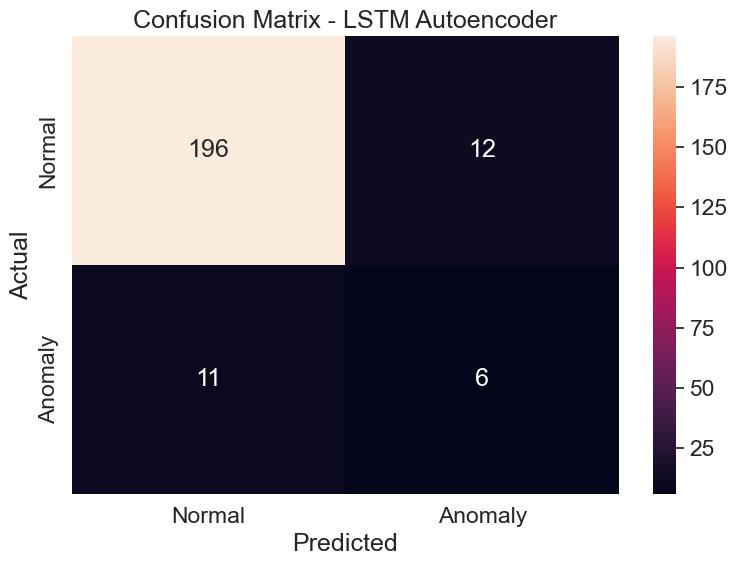

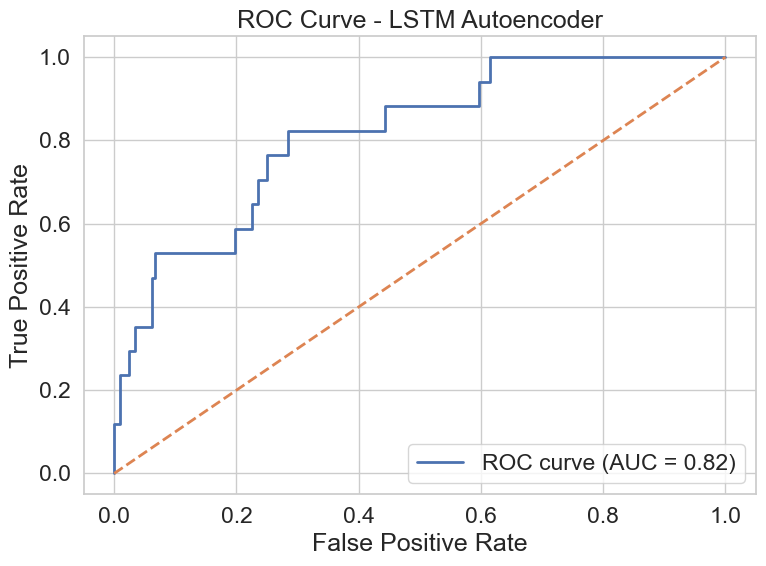

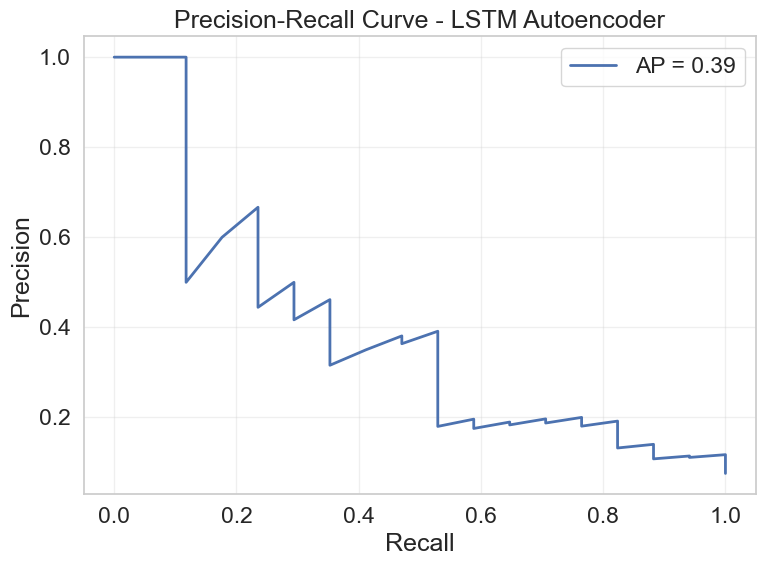

In [43]:
from AnomalyDetectionHelper import DetectionMethodsEvaluation

evaluator = DetectionMethodsEvaluation(
    preparer=preparer_LSTM,
    metadata_df=metadata_df,
    X_df=X_df,
    y=y,
)

print("\n--- LSTM Autoencoder (Test) ---")
precision_LSTM_AE, recall_LSTM_AE, f1_LSTM_AE, fin_score_LSTM_AE = evaluator.evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_LSTM,
    y_score=test_err_LSTM,
    model_name='LSTM Autoencoder',
)

y_test_pred_series_LSTM = pd.Series(y_pred_LSTM, index=y_test.index, name='y_pred')
current_dir = os.getcwd()
csv_file_path_LSTM_AE = os.path.join(
    current_dir, "AnomalyDetection", "CSVCalibbratedResults",
    f"{str_flag}_LSTM_AE_predictions.csv"
)
os.makedirs(os.path.dirname(csv_file_path_LSTM_AE), exist_ok=True)
y_test_pred_series_LSTM.to_csv(csv_file_path_LSTM_AE, index=True)


### 4.4.2 LSTM Classifier for Supervised Anomaly Detection
<a id="sec-442-lstm-class"></a>

The LSTM Classifier is a supervised model trained to classify each time step as normal or anomalous.

This model leverages labeled data (`Y`) to directly learn the distinction between normal and anomaly regimes, offering precise and targeted anomaly detection.  

Hyperparameter tuning with Optuna ensures the classifier is well-adapted to the temporal dynamics of the dataset.


In [44]:
from AnomalyDetectionHelper import AnomalyDataPreparer, LSTMClassifierAnomalyDetector
from sklearn.metrics import f1_score

cutoff_date_train = pd.to_datetime('2012-01-01')
cutoff_date_val = pd.to_datetime('2017-01-01')

preparer_cls = AnomalyDataPreparer(
    shuffle_data=False,
    scale_data=True,
    do_split=True,
    chronological_split=True,
    make_stationary=True,
    train_end=cutoff_date_train,
    val_end=cutoff_date_val,
    random_state=42,
)
X_train, y_train, X_val, y_val, X_test, y_test = preparer_cls.prepare(X_df, y)

classifier = LSTMClassifierAnomalyDetector(input_dim=X_train.shape[1])
current_dir = os.getcwd()
optuna_studies_dir = os.path.join(current_dir, "AnomalyDetection", "OptunaStudies")
os.makedirs(optuna_studies_dir, exist_ok=True)
db_file_path = os.path.join(optuna_studies_dir, f"optuna_LSTM_classifier_{str_flag}_v2.db")
optuna_db_uri_cls = f"sqlite:///{db_file_path}"

study_LSTM_cls = classifier.tune_hyperparameters(
    X_train.values, y_train.values,
    X_val.values, y_val.values,
    n_trials=optuna_n_trials,
    storage=optuna_db_uri_cls,
)
val_f1_LSTM_cls_T = float(study_LSTM_cls.best_value)

# Clean test protocol: fit the final evaluation model on TRAIN only.
classifier.train_final_model(X_train.values, y_train.values)

# Validation probabilities are used only for validation diagnostics/model selection.
y_val_proba_LSTM_cls = classifier.predict(X_val.values, X_context=X_train.values)
y_val_pred_LSTM_cls_05 = (y_val_proba_LSTM_cls > 0.5).astype(int)
val_f1_LSTM_cls_05 = float(f1_score(y_val.values, y_val_pred_LSTM_cls_05, zero_division=0))


Training set size: 624 (517 normal, 107 anomalies)
Validation set size: 261 (242 normal, 19 anomalies)
Test set size: 225 (208 normal, 17 anomalies)


  0%|          | 0/5 [00:00<?, ?it/s]

Best validation F1: 0.6111111111111113
Best parameters: {'seq_len': 30, 'hidden_dim': 64, 'num_layers': 1, 'lr': 0.002174852962469394, 'batch_size': 64}
Best validation threshold: 0.7000101208686829
Best epoch: 8
Epoch 1/8 - Loss: 1.058551
Epoch 2/8 - Loss: 0.854010
Epoch 3/8 - Loss: 0.703984
Epoch 4/8 - Loss: 0.610409
Epoch 5/8 - Loss: 0.519513
Epoch 6/8 - Loss: 0.450000
Epoch 7/8 - Loss: 0.411256
Epoch 8/8 - Loss: 0.366506


#### Using a Trivial Threshold for the LSTM Classifier

Initially, the LSTM Classifier predictions are binarized using a trivial threshold of 0.5.
  
This standard threshold allows for a baseline evaluation of the classifier's performance before exploring more tailored decision boundaries.



--- LSTM Classifier, threshold 0.5 (Test) ---

LSTM Classifier Performance:
Precision: 0.4074
Recall:    0.6471
F1 Score:  0.5000
Financial Score: 0.7190


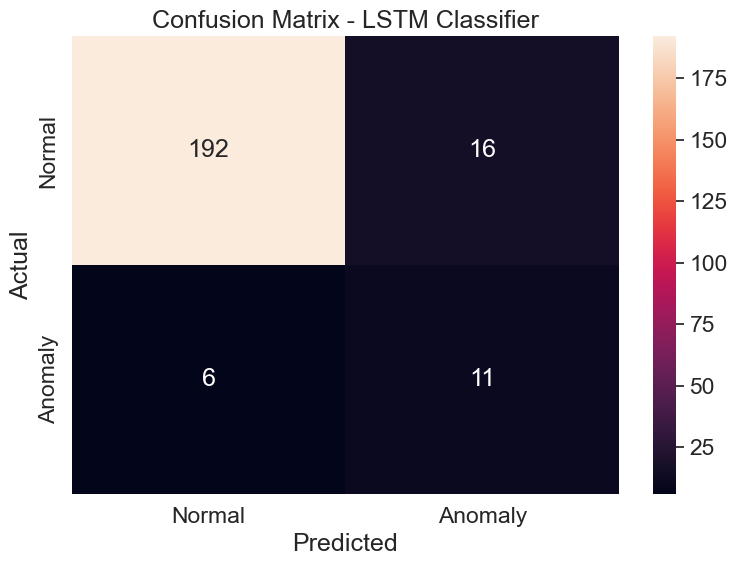

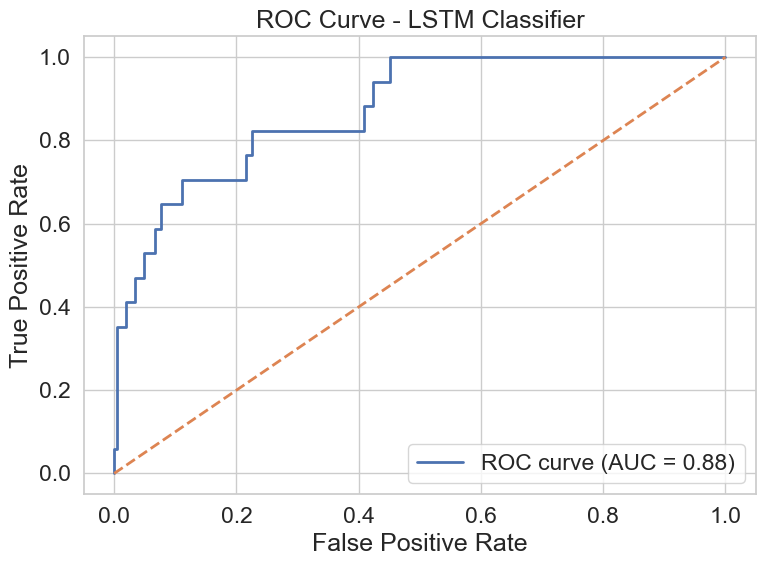

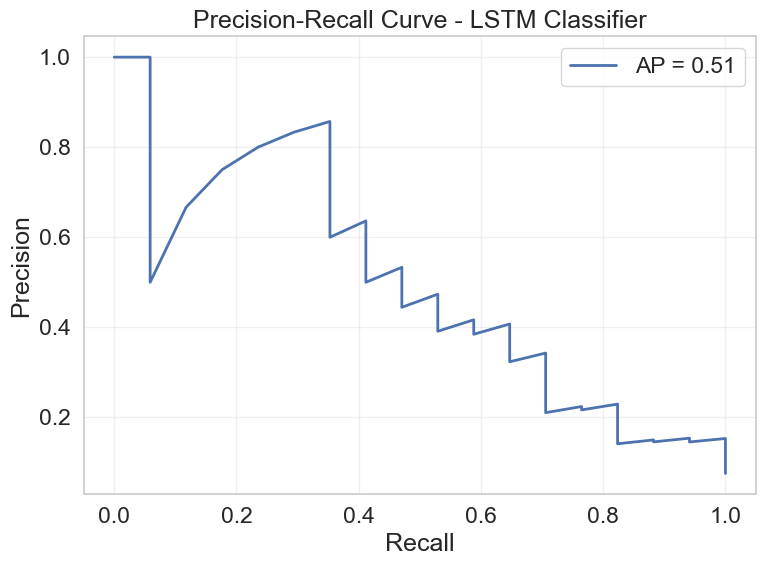

In [45]:
from AnomalyDetectionHelper import DetectionMethodsEvaluation

# One causal probability for every test date, using validation history as context.
y_pred_proba_LSTM_cls = classifier.predict(X_test.values, X_context=X_val.values)
y_pred_LSTM_cls = (y_pred_proba_LSTM_cls > 0.5).astype(int)

evaluator = DetectionMethodsEvaluation(
    preparer=preparer_cls,
    metadata_df=metadata_df,
    X_df=X_df,
    y=y,
)

print("\n--- LSTM Classifier, threshold 0.5 (Test) ---")
precision_LSTM_cls, recall_LSTM_cls, f1_LSTM_cls, fin_score_LSTM_cls = evaluator.evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_LSTM_cls,
    y_score=y_pred_proba_LSTM_cls,
    model_name='LSTM Classifier',
)

y_test_pred_series_LSTM_cls = pd.Series(y_pred_LSTM_cls, index=y_test.index, name='y_pred')
current_dir = os.getcwd()
csv_file_path_LSTM_cls = os.path.join(
    current_dir, "AnomalyDetection", "CSVCalibbratedResults",
    f"{str_flag}_LSTM_Cls_predictions.csv"
)
os.makedirs(os.path.dirname(csv_file_path_LSTM_cls), exist_ok=True)
y_test_pred_series_LSTM_cls.to_csv(csv_file_path_LSTM_cls, index=True)


#### Validation-Calibrated Threshold for the LSTM Classifier

The decision threshold must be selected on the **validation set**, never on the test set. The previous notebook computed a precision-recall curve from `y_test`, which directly leaked test labels into model calibration.

The corrected classifier stores the F1-optimal threshold found during validation. The test set is then used exactly once with that threshold frozen.


Validation-calibrated LSTM threshold: 0.7000101208686829

--- LSTM Classifier with Validation-Calibrated Threshold (Test) ---

LSTM Classifier with Validation-Calibrated Threshold Performance:
Precision: 0.4706
Recall:    0.4706
F1 Score:  0.4706
Financial Score: 0.5973


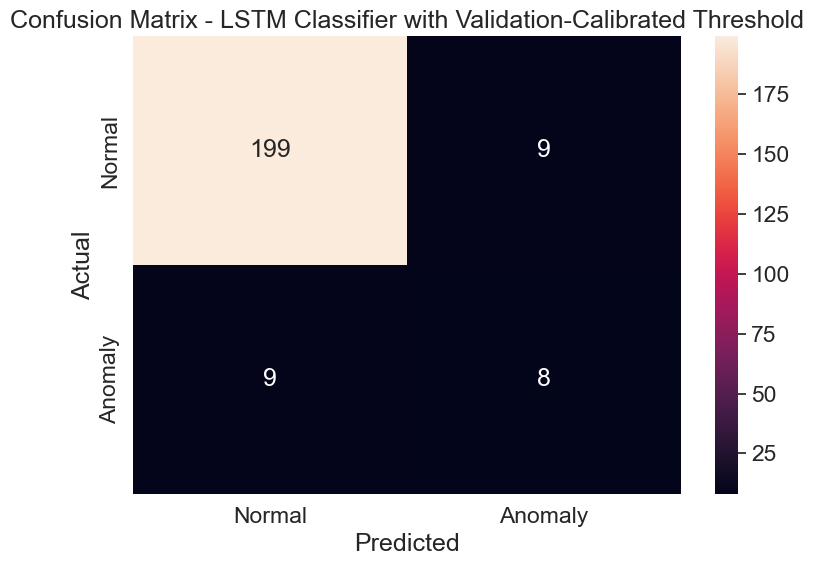

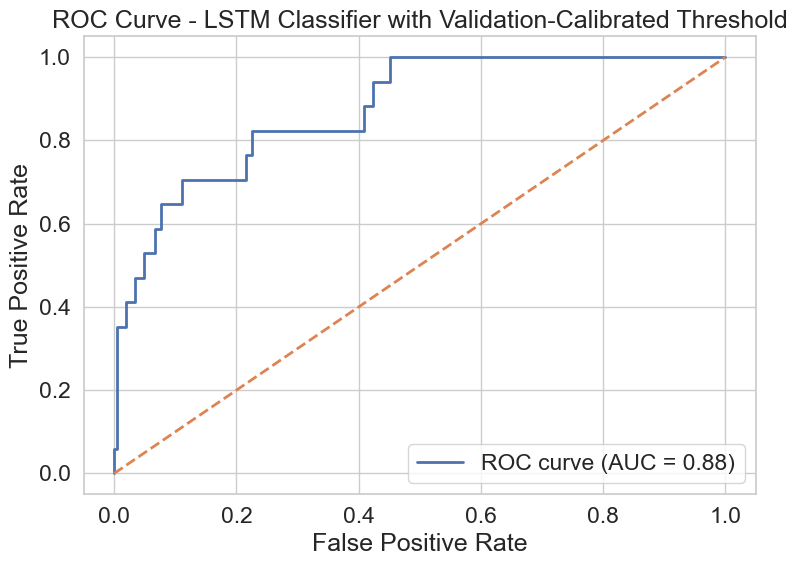

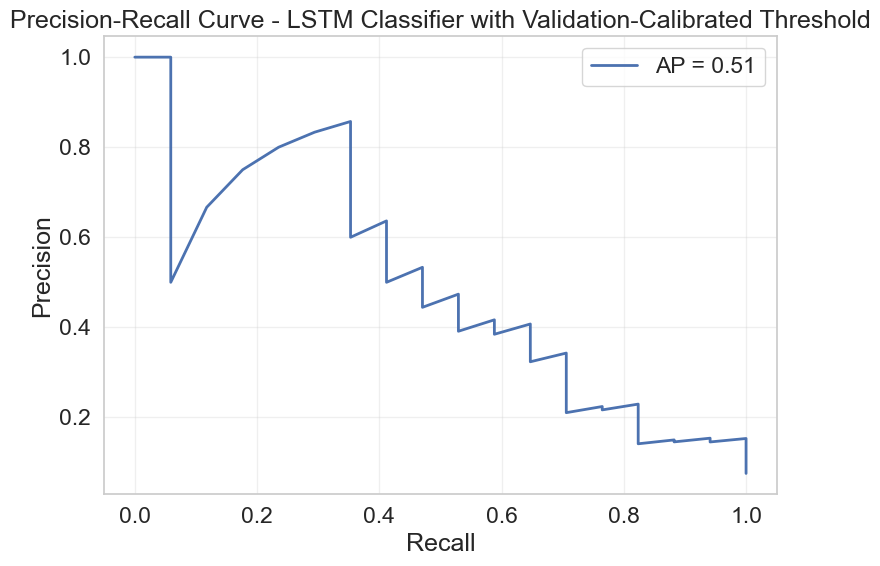

In [46]:
from AnomalyDetectionHelper import DetectionMethodsEvaluation

# Threshold was selected during Optuna/validation. Do NOT optimize it on y_test.
best_thresh_LSTM_cls = classifier.best_threshold
print("Validation-calibrated LSTM threshold:", best_thresh_LSTM_cls)

y_pred_LSTM_cls_T = (y_pred_proba_LSTM_cls > best_thresh_LSTM_cls).astype(int)

evaluator = DetectionMethodsEvaluation(
    preparer=preparer_cls,
    metadata_df=metadata_df,
    X_df=X_df,
    y=y,
)

print("\n--- LSTM Classifier with Validation-Calibrated Threshold (Test) ---")
precision_LSTM_cls_T, recall_LSTM_cls_T, f1_LSTM_cls_T, fin_score_LSTM_cls_T = evaluator.evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_LSTM_cls_T,
    y_score=y_pred_proba_LSTM_cls,
    model_name='LSTM Classifier with Validation-Calibrated Threshold',
)

y_test_pred_series_LSTM_cls_T = pd.Series(y_pred_LSTM_cls_T, index=y_test.index, name='y_pred')
current_dir = os.getcwd()
csv_file_path_LSTM_cls_T = os.path.join(
    current_dir, "AnomalyDetection", "CSVCalibbratedResults",
    f"{str_flag}_LSTM_Cls_T_predictions.csv"
)
os.makedirs(os.path.dirname(csv_file_path_LSTM_cls_T), exist_ok=True)
y_test_pred_series_LSTM_cls_T.to_csv(csv_file_path_LSTM_cls_T, index=True)


## 4.5 Shock Detector Results Comparison
<a id="sec-45-res-comp"></a>

The models above all operate on the **shock representation** (returns / first differences). Test metrics are reported for transparency, while the production shock model is selected using validation F1 only.

This separation is important: the next section introduces a complementary **level/regime detector** rather than replacing the shock detector.


In [47]:
# Test-set reporting. These metrics are NOT used to select the production model.
summary_df = pd.DataFrame({
    'Model': [
        'MLP (Basic)',
        'MLP (Optuna Tuning)',
        'LSTM Autoencoder',
        'LSTM Classifier',
        'LSTM Classifier with Validation-Calibrated Threshold',
    ],
    '# Anomalies Detected': [
        np.sum(Y_test_pred_SimpleMLP == 1),
        np.sum(y_pred_MLP_Optuna == 1),
        np.sum(y_pred_LSTM == 1),
        np.sum(y_pred_LSTM_cls == 1),
        np.sum(y_pred_LSTM_cls_T == 1),
    ],
    'Precision': [precision_Simple_MLP, precision_Optuna_MLP, precision_LSTM_AE, precision_LSTM_cls, precision_LSTM_cls_T],
    'Recall': [recall_Simple_MLP, recall_Optuna_MLP, recall_LSTM_AE, recall_LSTM_cls, recall_LSTM_cls_T],
    'F1 Score': [f1_Simple_MLP, f1_Optuna_MLP, f1_LSTM_AE, f1_LSTM_cls, f1_LSTM_cls_T],
    'Financial Score': [fin_score_Simple_MLP, fin_score_Optuna_MLP, fin_score_LSTM_AE, fin_score_LSTM_cls, fin_score_LSTM_cls_T],
})

# Model selection uses VALIDATION F1 only. This prevents choosing a detector after
# looking at test performance.
validation_scores = {
    'MLP (Basic)': val_f1_Simple_MLP,
    'MLP (Optuna Tuning)': val_f1_Optuna_MLP,
    'LSTM Autoencoder': val_f1_LSTM_AE,
    'LSTM Classifier': val_f1_LSTM_cls_05,
    'LSTM Classifier with Validation-Calibrated Threshold': val_f1_LSTM_cls_T,
}
selected_anomaly_model = max(validation_scores, key=validation_scores.get)
print("Selected anomaly model from validation only:", selected_anomaly_model)
print("Validation F1:", validation_scores[selected_anomaly_model])

styled_summary_df = (
    summary_df.style
    .background_gradient(cmap='Greens', subset=['Precision'])
    .background_gradient(cmap='Greens', subset=['Recall'])
    .background_gradient(cmap='Greens', subset=['F1 Score'])
    .background_gradient(cmap='Greens', subset=['Financial Score'])
    .format({
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}',
        'Financial Score': '{:.4f}',
    })
    .set_caption("Test Performance (model selection was performed on validation only)")
)
styled_summary_df


Selected anomaly model from validation only: LSTM Classifier with Validation-Calibrated Threshold
Validation F1: 0.6111111111111113


,Model,# Anomalies Detected,Precision,Recall,F1 Score,Financial Score
0,MLP (Basic),16,0.5625,0.5294,0.5455,0.6433
1,MLP (Optuna Tuning),106,0.1509,0.9412,0.2602,0.8437
2,LSTM Autoencoder,18,0.3333,0.3529,0.3429,0.5065
3,LSTM Classifier,27,0.4074,0.6471,0.5000,0.7190
4,LSTM Classifier with Validation-Calibrated Threshold,17,0.4706,0.4706,0.4706,0.5973


<br>


## 4.6 Complementary Level / Regime Anomaly Detection
<a id="sec-46-level-regime"></a>

Stationarizing the market data changes the economic meaning of an anomaly. The shock branch above detects unusually large **changes** in market variables. A slow deterioration in an equity index or a persistently unusual rate level can instead be abnormal even when no single weekly move is extreme.

We therefore keep the shock detector and add a second, complementary **level/regime channel**. It uses only causal state features:

- rolling z-scores of log levels for price-like assets;
- drawdown from the historical peak and 52/104-week rolling peaks for price-like assets;
- rolling level z-scores for yields, VIX and the economic-surprise index.

At date $t$, rolling means and standard deviations are estimated only through $t-1$. The level features observed at $t$ may generate a signal at $t$, but any portfolio action is applied only after $t$.

To isolate the effect of the feature representation, the level channel uses the same Optuna-tuned MLP family as the shock branch. It is not intended to replace the shock detector. The final subsection compares **shock**, **level**, and a fixed **shock OR level** rule using validation data only.


In [48]:
from AnomalyDetectionHelper import AnomalyDataPreparer, MLPAnomalyDetector

preparer_level = AnomalyDataPreparer(
    make_stationary=False,   # make_level_features() already performs the level transformation
    shuffle_data=False,
    scale_data=True,
    do_split=True,
    chronological_split=True,
    train_end=cutoff_date_train,
    val_end=cutoff_date_val,
    random_state=42,
)

X_level, y_level = preparer_level.make_level_features(
    X_df,
    y,
    window=52,
    drawdown_windows=(52, 104),
)

print("Level feature matrix:", X_level.shape)
print("Level labels:", y_level.shape)
print("Missing values:", int(X_level.isna().sum().sum()))
print("Infinite values:", int(np.isinf(X_level.to_numpy()).sum()))
print("Number of labelled anomalies:", int((y_level == 1).sum()))

if "MXUS_level_z" in X_level.columns:
    print("\nMXUS level features:")
    print([c for c in X_level.columns if c.startswith("MXUS_")])


Level feature matrix: (1008, 108)
Level labels: (1008,)
Missing values: 0
Infinite values: 0
Number of labelled anomalies: 114

MXUS level features:
['MXUS_level_z', 'MXUS_drawdown_from_peak', 'MXUS_drawdown_52w', 'MXUS_drawdown_104w']


c:\Users\andre\git_repos\Projects\Big_Levy_Investments\AnomalyDetection\AnomalyDetectionHelper.py:544: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  level_features[f"{col}_level_z"] = causal_level_z(
c:\Users\andre\git_repos\Projects\Big_Levy_Investments\AnomalyDetection\AnomalyDetectionHelper.py:544: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  level_features[f"{col}_level_z"] = causal_level_z(
c:\Users\andre\git_repos\Projects\Big_Levy_Investments\AnomalyDetection\AnomalyDetectionHelper.py:544: PerformanceWarning: DataFrame i

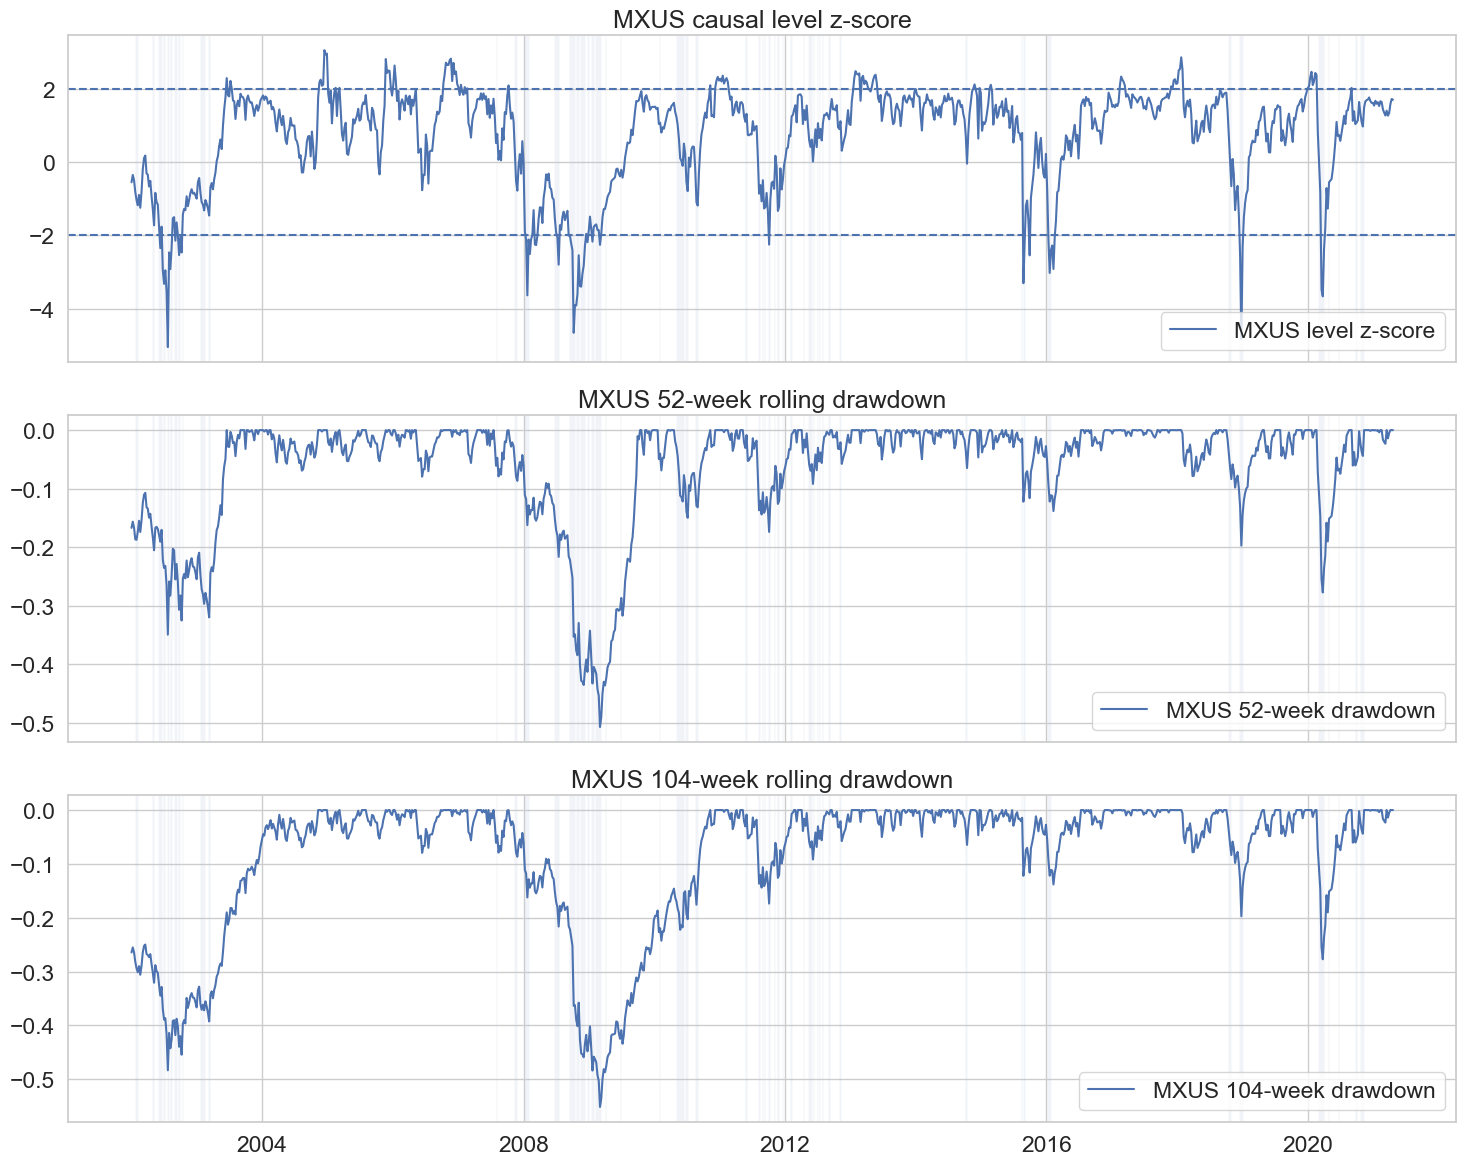

In [49]:
# Diagnostic view: level and drawdown features are not used as hand-written thresholds.
# The +/-2 lines are visual references only; the classifier learns a multivariate rule.
if "MXUS_level_z" in X_level.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

    axes[0].plot(X_level.index, X_level["MXUS_level_z"], label="MXUS level z-score")
    axes[0].axhline(2, linestyle="--")
    axes[0].axhline(-2, linestyle="--")
    axes[0].set_title("MXUS causal level z-score")
    axes[0].legend()

    axes[1].plot(X_level.index, X_level["MXUS_drawdown_52w"], label="MXUS 52-week drawdown")
    axes[1].set_title("MXUS 52-week rolling drawdown")
    axes[1].legend()

    axes[2].plot(X_level.index, X_level["MXUS_drawdown_104w"], label="MXUS 104-week drawdown")
    axes[2].set_title("MXUS 104-week rolling drawdown")
    axes[2].legend()

    anomaly_dates_plot = y_level.index[y_level.eq(1)]
    for ax in axes:
        for d in anomaly_dates_plot:
            ax.axvspan(d, d + pd.Timedelta(days=7), alpha=0.08)

    plt.tight_layout()
    plt.show()


In [50]:
X_train_level, y_train_level, X_val_level, y_val_level, X_test_level, y_test_level = (
    preparer_level.prepare(X_level, y_level)
)

print("\nLEVEL TRAIN")
print(X_train_level.index.min(), "->", X_train_level.index.max())
print(y_train_level.value_counts().sort_index())

print("\nLEVEL VALIDATION")
print(X_val_level.index.min(), "->", X_val_level.index.max())
print(y_val_level.value_counts().sort_index())

print("\nLEVEL TEST")
print(X_test_level.index.min(), "->", X_test_level.index.max())
print(y_test_level.value_counts().sort_index())


Training set size: 522 (444 normal, 78 anomalies)
Validation set size: 261 (242 normal, 19 anomalies)
Test set size: 225 (208 normal, 17 anomalies)

LEVEL TRAIN
2002-01-01 00:00:00 -> 2011-12-27 00:00:00
Y
0    444
1     78
Name: count, dtype: int64

LEVEL VALIDATION
2012-01-03 00:00:00 -> 2016-12-27 00:00:00
Y
0    242
1     19
Name: count, dtype: int64

LEVEL TEST
2017-01-03 00:00:00 -> 2021-04-20 00:00:00
Y
0    208
1     17
Name: count, dtype: int64


### 4.6.1 Optuna-Tuned MLP on Level / Regime Features

The level detector is trained and calibrated exactly like the tuned shock MLP: model parameters and the classification threshold are chosen on the validation sample, the final evaluation model is fitted on the training sample only, and the test set is used only for reporting.

The business-oriented Financial Score is deliberately calibrated from the same original training market data used for the shock branch, so its economic cost scale is held constant across the two feature representations.


  0%|          | 0/5 [00:00<?, ?it/s]

Best validation F1: 0.39344262295081966
Best hyperparameters: {'n_layers': 3, 'n_units_l0': 240, 'n_units_l1': 100, 'n_units_l2': 98, 'learning_rate_init': 0.00044995536929798915, 'alpha': 1.1311651182141531e-05}
Best validation threshold: 0.0015877405909751612
Test set performance:
Precision: 0.6666666666666666
Recall: 0.35294117647058826
F1 Score: 0.46153846153846156

--- Level / Regime MLP (Test) ---

MLP Level / Regime Performance:
Precision: 0.6667
Recall:    0.3529
F1 Score:  0.4615
Financial Score: 0.5178


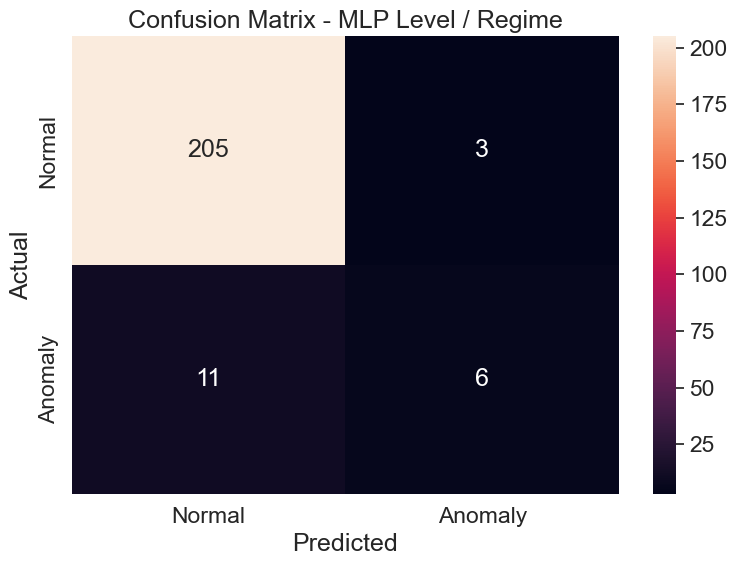

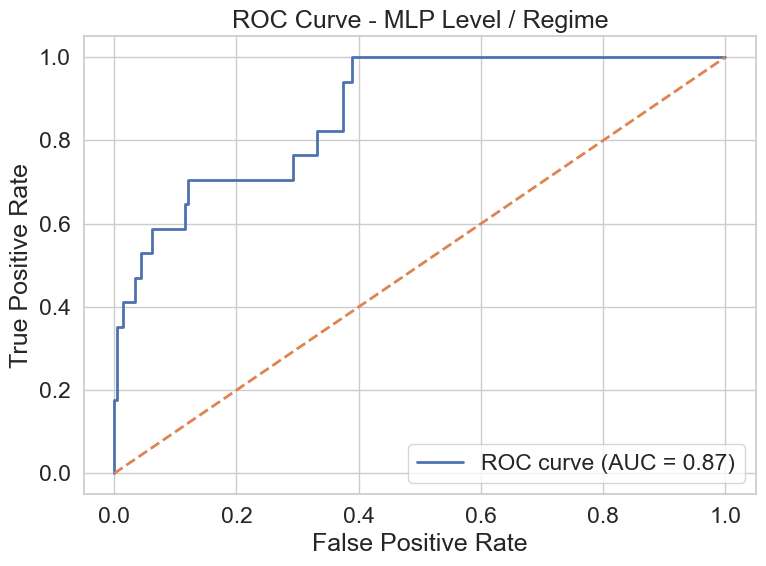

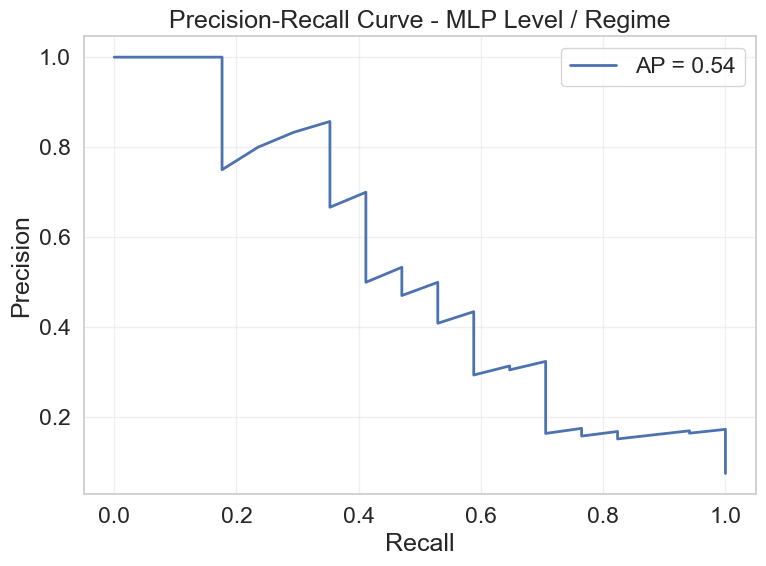

Validation F1 (recomputed): 0.3667
Test PR-AUC: 0.5380
Test ROC-AUC: 0.8725
Random PR baseline: 0.0756


In [51]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
)
from AnomalyDetectionHelper import DetectionMethodsEvaluation

mlp_level = MLPAnomalyDetector(input_dim=X_train_level.shape[1])

db_file_path_level = os.path.join(
    optuna_studies_dir,
    f"optuna_MLP_LEVEL_{str_flag}_v2.db",
)

study_MLP_level = mlp_level.tune_hyperparameters(
    X_train_level,
    y_train_level,
    X_val_level,
    y_val_level,
    n_trials=optuna_n_trials,
    storage=f"sqlite:///{db_file_path_level}",
)
val_f1_level_study = float(study_MLP_level.best_value)

# Keep the validation-calibrated threshold consistent with the train-only final fit.
mlp_level.train_final_model(X_train_level, y_train_level)

y_prob_level_val = mlp_level.predict_scores(X_val_level)
y_pred_level_val = (y_prob_level_val > mlp_level.best_threshold).astype(int)
val_f1_level = float(f1_score(y_val_level, y_pred_level_val, zero_division=0))

y_pred_level, y_prob_level = mlp_level.evaluate_on_test(
    X_test_level,
    y_test_level,
)

# Reuse the same economic-cost calibration as the shock branch.
evaluator_level = DetectionMethodsEvaluation(
    preparer=preparer_MLP,
    metadata_df=metadata_df,
    X_df=X_df,
    y=y,
)

print("\n--- Level / Regime MLP (Test) ---")
precision_level, recall_level, f1_level, fin_score_level = evaluator_level.evaluate_model(
    y_true=y_test_level.values,
    y_pred=y_pred_level,
    y_score=y_prob_level,
    model_name="MLP Level / Regime",
)

ap_level = average_precision_score(y_test_level, y_prob_level)
roc_level = roc_auc_score(y_test_level, y_prob_level)
random_pr_baseline_level = float(np.mean(np.asarray(y_test_level) == 1))

print(f"Validation F1 (recomputed): {val_f1_level:.4f}")
print(f"Test PR-AUC: {ap_level:.4f}")
print(f"Test ROC-AUC: {roc_level:.4f}")
print(f"Random PR baseline: {random_pr_baseline_level:.4f}")

level_prediction_path = os.path.join(
    current_dir,
    "AnomalyDetection",
    "CSVCalibbratedResults",
    f"{str_flag}_LevelMLP_predictions.csv",
)
os.makedirs(os.path.dirname(level_prediction_path), exist_ok=True)
pd.DataFrame(
    {
        "y_pred": y_pred_level,
        "y_score": y_prob_level,
    },
    index=y_test_level.index,
).to_csv(level_prediction_path)


### 4.6.2 Shock vs Level and Final Dual-Signal Rule

The two channels answer different questions:

- **Shock**: is the current market move unusually large?
- **Level / regime**: is the current market state unusually far from its recent historical regime?

The best shock architecture has already been selected using validation F1 in Section 4.5. We now compare that frozen shock detector with the level MLP and with the pre-specified binary rule

$$
A_t^{\mathrm{OR}} = \mathbf{1}\{A_t^{\mathrm{shock}}=1 \;\lor\; A_t^{\mathrm{level}}=1\}.
$$

If a single signal is required by the portfolio overlay, the choice among **Shock**, **Level**, and **Shock OR Level** is made on validation F1 only. Test metrics remain reporting-only.


In [52]:
# ------------------------------------------------------------------
# Recover validation/test predictions from the shock model selected
# in Section 4.5. All shock models use the same chronological,
# stationary and train-scaled representation.
# ------------------------------------------------------------------

# Continuous validation scores for each shock model.
shock_val_score_map = {
    "MLP (Basic)": np.asarray(Y_val_prob, dtype=float),
    "MLP (Optuna Tuning)": np.asarray(mlp_detector.predict_scores(X_val), dtype=float),
    "LSTM Autoencoder": np.asarray(
        LSTM_detector.predict_scores(X_val.values, X_context=X_train.values),
        dtype=float,
    ),
    "LSTM Classifier": np.asarray(y_val_proba_LSTM_cls, dtype=float),
    "LSTM Classifier with Validation-Calibrated Threshold": np.asarray(
        y_val_proba_LSTM_cls,
        dtype=float,
    ),
}

shock_val_pred_map = {
    "MLP (Basic)": (shock_val_score_map["MLP (Basic)"] > best_thresh).astype(int),
    "MLP (Optuna Tuning)": (
        shock_val_score_map["MLP (Optuna Tuning)"] > mlp_detector.best_threshold
    ).astype(int),
    "LSTM Autoencoder": (
        shock_val_score_map["LSTM Autoencoder"] > LSTM_detector.best_threshold
    ).astype(int),
    "LSTM Classifier": (
        shock_val_score_map["LSTM Classifier"] > 0.5
    ).astype(int),
    "LSTM Classifier with Validation-Calibrated Threshold": (
        shock_val_score_map["LSTM Classifier with Validation-Calibrated Threshold"]
        > classifier.best_threshold
    ).astype(int),
}

shock_test_score_map = {
    "MLP (Basic)": np.asarray(Y_test_prob_SimpleMLP, dtype=float),
    "MLP (Optuna Tuning)": np.asarray(y_prob_MLP_Optuna, dtype=float),
    "LSTM Autoencoder": np.asarray(test_err_LSTM, dtype=float),
    "LSTM Classifier": np.asarray(y_pred_proba_LSTM_cls, dtype=float),
    "LSTM Classifier with Validation-Calibrated Threshold": np.asarray(
        y_pred_proba_LSTM_cls,
        dtype=float,
    ),
}

shock_test_pred_map = {
    "MLP (Basic)": np.asarray(Y_test_pred_SimpleMLP, dtype=int),
    "MLP (Optuna Tuning)": np.asarray(y_pred_MLP_Optuna, dtype=int),
    "LSTM Autoencoder": np.asarray(y_pred_LSTM, dtype=int),
    "LSTM Classifier": np.asarray(y_pred_LSTM_cls, dtype=int),
    "LSTM Classifier with Validation-Calibrated Threshold": np.asarray(
        y_pred_LSTM_cls_T,
        dtype=int,
    ),
}

shock_val_pred = pd.Series(
    shock_val_pred_map[selected_anomaly_model],
    index=y_val.index,
    name="shock_pred",
)
shock_val_score = pd.Series(
    shock_val_score_map[selected_anomaly_model],
    index=y_val.index,
    name="shock_score",
)

shock_test_pred = pd.Series(
    shock_test_pred_map[selected_anomaly_model],
    index=y_test.index,
    name="shock_pred",
)
shock_test_score = pd.Series(
    shock_test_score_map[selected_anomaly_model],
    index=y_test.index,
    name="shock_score",
)

level_val_pred = pd.Series(
    y_pred_level_val,
    index=y_val_level.index,
    name="level_pred",
)
level_test_pred = pd.Series(
    y_pred_level,
    index=y_test_level.index,
    name="level_pred",
)
level_test_score = pd.Series(
    y_prob_level,
    index=y_test_level.index,
    name="level_score",
)

# ------------------------------------------------------------------
# Validation-only signal-family selection.
# ------------------------------------------------------------------
common_val = (
    shock_val_pred.index
    .intersection(level_val_pred.index)
    .intersection(y_val_level.index)
)
y_val_signal = y_val_level.loc[common_val].astype(int)
shock_val_common = shock_val_pred.loc[common_val].astype(int)
level_val_common = level_val_pred.loc[common_val].astype(int)
combined_val_common = (
    (shock_val_common == 1) | (level_val_common == 1)
).astype(int)

signal_validation_f1 = {
    "Shock": float(f1_score(y_val_signal, shock_val_common, zero_division=0)),
    "Level": float(f1_score(y_val_signal, level_val_common, zero_division=0)),
    "Shock OR Level": float(
        f1_score(y_val_signal, combined_val_common, zero_division=0)
    ),
}

selected_risk_signal = max(signal_validation_f1, key=signal_validation_f1.get)

print("Selected shock architecture:", selected_anomaly_model)
print("\nValidation F1 by signal family:")
for name, value in signal_validation_f1.items():
    print(f"  {name}: {value:.4f}")
print("\nSelected risk signal from validation only:", selected_risk_signal)

# ------------------------------------------------------------------
# Test reporting. These test results DO NOT affect selection.
# ------------------------------------------------------------------
common_test = (
    shock_test_pred.index
    .intersection(level_test_pred.index)
    .intersection(y_test_level.index)
)
y_test_signal = y_test_level.loc[common_test].astype(int)
shock_test_common = shock_test_pred.loc[common_test].astype(int)
level_test_common = level_test_pred.loc[common_test].astype(int)
combined_test_common = (
    (shock_test_common == 1) | (level_test_common == 1)
).astype(int)

signal_test_predictions = {
    "Shock": shock_test_common,
    "Level": level_test_common,
    "Shock OR Level": combined_test_common,
}
selected_test_pred = signal_test_predictions[selected_risk_signal].astype(int)

def _signal_metric_row(name, pred, score=None):
    pred = pd.Series(pred, index=common_test).astype(int)
    row = {
        "Signal": name,
        "# Anomalies Detected": int(pred.sum()),
        "Precision": float(precision_score(y_test_signal, pred, zero_division=0)),
        "Recall": float(recall_score(y_test_signal, pred, zero_division=0)),
        "F1 Score": float(f1_score(y_test_signal, pred, zero_division=0)),
        "Financial Score": float(evaluator_level.financial_score(y_test_signal, pred)),
        "PR-AUC": np.nan,
        "ROC-AUC": np.nan,
    }
    if score is not None:
        score = pd.Series(score, index=common_test).astype(float)
        row["PR-AUC"] = float(average_precision_score(y_test_signal, score))
        row["ROC-AUC"] = float(roc_auc_score(y_test_signal, score))
    return row

signal_summary_df = pd.DataFrame(
    [
        _signal_metric_row(
            "Shock",
            shock_test_common,
            shock_test_score.reindex(common_test),
        ),
        _signal_metric_row(
            "Level",
            level_test_common,
            level_test_score.reindex(common_test),
        ),
        # OR is a binary decision rule, so probability-ranking metrics are omitted.
        _signal_metric_row(
            "Shock OR Level",
            combined_test_common,
            score=None,
        ),
    ]
)

display(
    signal_summary_df.style
    .background_gradient(cmap="Greens", subset=["Precision", "Recall", "F1 Score", "Financial Score"])
    .format(
        {
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1 Score": "{:.4f}",
            "Financial Score": "{:.4f}",
            "PR-AUC": "{:.4f}",
            "ROC-AUC": "{:.4f}",
        },
        na_rep="-",
    )
    .set_caption(
        "Test comparison of complementary anomaly signals "
        "(signal selection performed on validation only)"
    )
)

final_risk_signal_df = pd.DataFrame(
    {
        "Y": y_test_signal,
        "shock_pred": shock_test_common,
        "level_pred": level_test_common,
        "combined_or_pred": combined_test_common,
        "y_pred": selected_test_pred,
    },
    index=common_test,
)
final_risk_signal_df["case"] = np.select(
    [
        (final_risk_signal_df["shock_pred"] == 1)
        & (final_risk_signal_df["level_pred"] == 1),
        (final_risk_signal_df["shock_pred"] == 1)
        & (final_risk_signal_df["level_pred"] == 0),
        (final_risk_signal_df["shock_pred"] == 0)
        & (final_risk_signal_df["level_pred"] == 1),
    ],
    ["both", "shock_only", "level_only"],
    default="neither",
)
final_risk_signal_df["selected_signal"] = selected_risk_signal
final_risk_signal_df["selected_shock_model"] = selected_anomaly_model

print("\nShock/level agreement on the test period:")
print(final_risk_signal_df["case"].value_counts())

print("\nDates where shock and level disagree:")
display(
    final_risk_signal_df.loc[
        final_risk_signal_df["case"].isin(["shock_only", "level_only"]),
        ["Y", "shock_pred", "level_pred", "case"],
    ]
)

final_signal_path = os.path.join(
    current_dir,
    "AnomalyDetection",
    "CSVCalibbratedResults",
    f"{str_flag}_FinalRiskSignal_predictions.csv",
)
os.makedirs(os.path.dirname(final_signal_path), exist_ok=True)
final_risk_signal_df.to_csv(final_signal_path)
print("\nFinal risk signal saved to:", final_signal_path)


Selected shock architecture: LSTM Classifier with Validation-Calibrated Threshold

Validation F1 by signal family:
  Shock: 0.5714
  Level: 0.3667
  Shock OR Level: 0.3934

Selected risk signal from validation only: Shock


,Signal,# Anomalies Detected,Precision,Recall,F1 Score,Financial Score,PR-AUC,ROC-AUC
0,Shock,17,0.4706,0.4706,0.4706,0.5973,0.5075,0.8761
1,Level,9,0.6667,0.3529,0.4615,0.5178,0.5380,0.8725
2,Shock OR Level,22,0.4545,0.5882,0.5128,0.6805,-,-



Shock/level agreement on the test period:
case
neither       203
shock_only     13
level_only      5
both            4
Name: count, dtype: int64

Dates where shock and level disagree:


,Y,shock_pred,level_pred,case
Data,,,,
2018-02-06,0,0,1,level_only
2018-10-23,1,1,0,shock_only
2018-10-30,0,1,0,shock_only
2018-12-11,1,1,0,shock_only
2018-12-18,1,0,1,level_only
2019-01-01,0,0,1,level_only
2019-05-28,0,1,0,shock_only
2019-07-30,0,1,0,shock_only
2019-08-06,0,1,0,shock_only



Final risk signal saved to: c:\Users\andre\git_repos\Projects\Big_Levy_Investments\AnomalyDetection\CSVCalibbratedResults\Equity_FinalRiskSignal_predictions.csv


---
<a id="sec-5-combination"></a>
# 5. Replica and Anomaly Detection Combination - Active Risk Management

The replica is overlaid with the **final anomaly signal selected on validation data only** in Section 4.6. The candidate signal families are the best shock detector, the level/regime MLP, and the fixed `Shock OR Level` rule.

A signal observed at date `t` is information that becomes available at `t`. It therefore cannot improve the return already earned at `t`; the defensive action is applied only to the next executable portfolio period. When the signal is active, the implementation below moves the replica to **cash by setting its risky positions to zero**.

Both discrete and fractional implementations are shown. Transaction costs are charged on actual turnover and only once on the execution date.


In [54]:
# Load the final signal produced in Section 4.6.
# Keeping a CSV fallback makes Section 5 re-runnable without repeating model training.
current_dir = os.getcwd()
final_signal_path = os.path.join(
    current_dir,
    "AnomalyDetection",
    "CSVCalibbratedResults",
    f"{str_flag}_FinalRiskSignal_predictions.csv",
)

if "final_risk_signal_df" in globals():
    anomaly_df = final_risk_signal_df.copy()
else:
    anomaly_df = pd.read_csv(final_signal_path, index_col=0, parse_dates=True)

anomaly_df.index = pd.to_datetime(anomaly_df.index)
anomaly_df = anomaly_df.sort_index()

if "y_pred" not in anomaly_df.columns:
    raise ValueError("Final anomaly signal must contain a 'y_pred' column.")

print("Portfolio overlay signal:", anomaly_df.get("selected_signal", pd.Series(["stored"])).iloc[0])
print("Active anomaly dates:", int((anomaly_df["y_pred"] == 1).sum()))

if selected_flag == 1:  # Equity portfolio
    base_positions = positions_history_df_EnKF.copy()
    model_results = result_EnKF.copy()
elif selected_flag == 2:  # Bond portfolio
    base_positions = positions_history_df_EnKF.copy()
    model_results = result_EnKF.copy()
elif selected_flag == 3:  # LifeStrategy 80/20 portfolio
    base_positions = positions_history_df_EN.copy()
    model_results = results_EN.copy()
else:
    raise ValueError("Invalid portfolio selection for anomaly detection dataset.")


Portfolio overlay signal: Shock
Active anomaly dates: 17


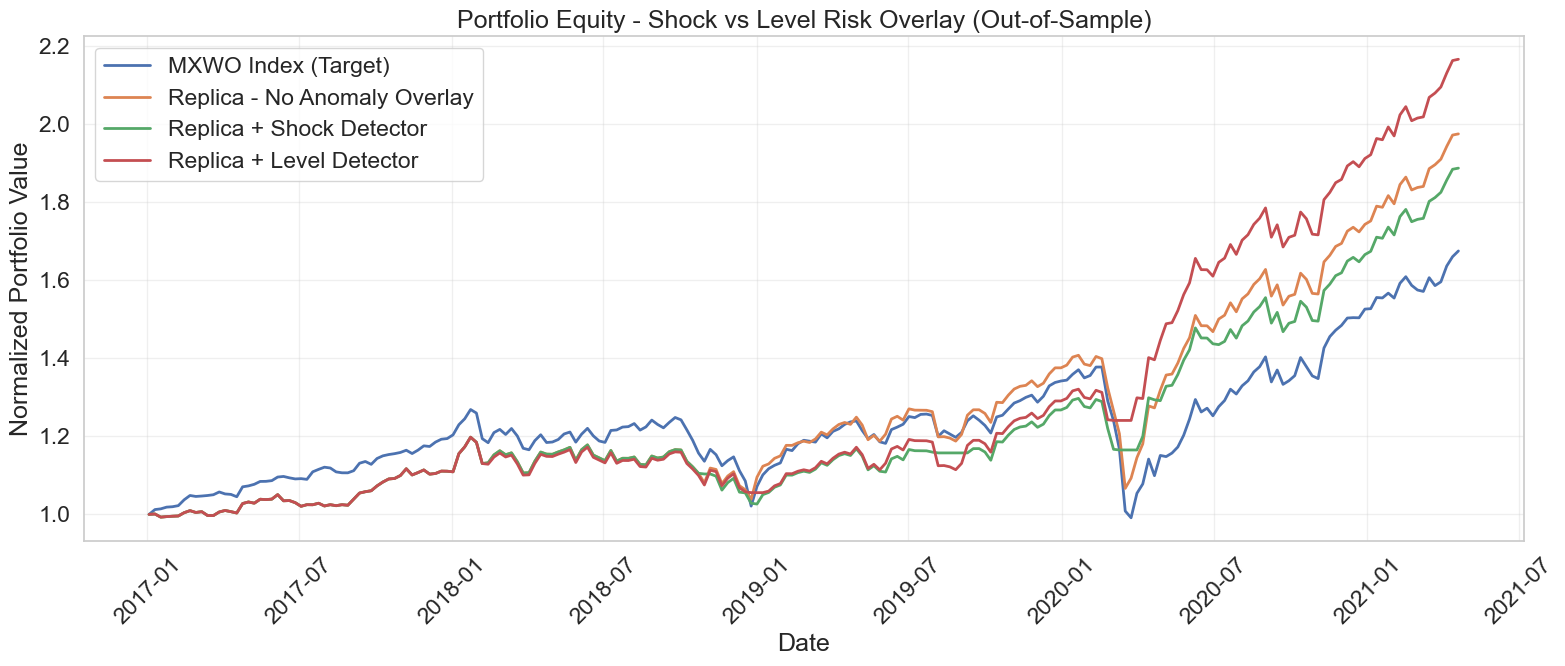

In [58]:
# ================================================================
# Shock vs Level: Out-of-Sample Portfolio Replication Comparison
# ================================================================

def build_fractional_overlay_curve(signal, signal_name):
    """
    Apply a binary anomaly signal to the replica weights causally.

    A signal observed at date t moves the portfolio to cash at the
    first portfolio date strictly AFTER t.

    Returns
    -------
    cumulative_curve : pd.Series
        Cumulative value of the strategy.
    strategy_returns : pd.Series
        Net returns after transaction costs.
    """

    # ------------------------------------------------------------
    # 1. Rebuild ORIGINAL replica weights
    #    Do not reuse fractional_weights_df because Section 5.2
    #    may already have modified it using the selected signal.
    # ------------------------------------------------------------
    weights = pd.DataFrame(
        model_results["weights_history"],
        index=pd.DatetimeIndex(base_positions.index),
        columns=base_positions.columns,
    ).sort_index()

    # ------------------------------------------------------------
    # 2. Align the signal
    # ------------------------------------------------------------
    signal = pd.Series(signal).astype(int).copy()
    signal.index = pd.to_datetime(signal.index)
    signal = signal.sort_index()

    anomaly_dates = pd.DatetimeIndex(
        signal.index[signal == 1]
    )

    # ------------------------------------------------------------
    # 3. Causal execution:
    #    signal at t -> first available portfolio weight AFTER t
    # ------------------------------------------------------------
    weight_index = weights.index

    locs = weight_index.searchsorted(
        anomaly_dates,
        side="right",
    )

    locs = locs[locs < len(weight_index)]

    execution_dates = weight_index[
        np.unique(locs)
    ]

    weights.loc[execution_dates, :] = 0.0

    # ------------------------------------------------------------
    # 4. Compute portfolio returns
    # ------------------------------------------------------------
    prices = data.loc[
        weights.index,
        futures_contracts
    ].copy()

    prices = prices[weights.columns]

    underlying_returns = (
        prices
        .pct_change()
        .fillna(0.0)
    )

    gross_returns = (
        weights * underlying_returns
    ).sum(axis=1)

    # ------------------------------------------------------------
    # 5. Transaction costs on actual turnover
    # ------------------------------------------------------------
    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .fillna(0.0)
    )

    costs = transaction_cost * turnover

    strategy_returns = (
        gross_returns - costs
    )

    cumulative_curve = (
        1.0 + strategy_returns
    ).cumprod()

    cumulative_curve.name = signal_name

    return cumulative_curve, strategy_returns


# ================================================================
# 1. Shock overlay
# ================================================================

shock_curve, shock_returns = build_fractional_overlay_curve(
    shock_test_common,
    "Shock detector",
)


# ================================================================
# 2. Level overlay
# ================================================================

level_curve, level_returns = build_fractional_overlay_curve(
    level_test_common,
    "Level detector",
)


# ================================================================
# 3. Replica with NO anomaly overlay
# ================================================================

base_weights = pd.DataFrame(
    model_results["weights_history"],
    index=pd.DatetimeIndex(base_positions.index),
    columns=base_positions.columns,
).sort_index()

base_prices = data.loc[
    base_weights.index,
    futures_contracts
].copy()

base_prices = base_prices[
    base_weights.columns
]

base_underlying_returns = (
    base_prices
    .pct_change()
    .fillna(0.0)
)

base_gross_returns = (
    base_weights * base_underlying_returns
).sum(axis=1)

base_turnover = (
    base_weights
    .diff()
    .abs()
    .sum(axis=1)
    .fillna(0.0)
)

base_costs = (
    transaction_cost * base_turnover
)

base_returns = (
    base_gross_returns - base_costs
)

base_curve = (
    1.0 + base_returns
).cumprod()


# ================================================================
# 4. Restrict comparison to COMMON OUT-OF-SAMPLE TEST PERIOD
# ================================================================

test_start = common_test.min()
test_end = common_test.max()

shock_curve_test = shock_curve.loc[
    test_start:test_end
]

level_curve_test = level_curve.loc[
    test_start:test_end
]

base_curve_test = base_curve.loc[
    test_start:test_end
]


# Normalize all curves to 1 at beginning of test
shock_curve_test = (
    shock_curve_test /
    shock_curve_test.iloc[0]
)

level_curve_test = (
    level_curve_test /
    level_curve_test.iloc[0]
)

base_curve_test = (
    base_curve_test /
    base_curve_test.iloc[0]
)


# ================================================================
# 5. Target index over same period
# ================================================================

target_curve = (
    model_results["cumulative_target"]
    .loc[test_start:test_end]
)

target_curve = (
    target_curve /
    target_curve.iloc[0]
)


# ================================================================
# 6. Plot
# ================================================================

plt.figure(figsize=(16, 7))

plt.plot(
    target_curve.index,
    target_curve.values,
    label=f"{index_name_str} (Target)",
    linewidth=2.0,
)

plt.plot(
    base_curve_test.index,
    base_curve_test.values,
    label="Replica - No Anomaly Overlay",
    linewidth=2.0,
)

plt.plot(
    shock_curve_test.index,
    shock_curve_test.values,
    label="Replica + Shock Detector",
    linewidth=2.0,
)

plt.plot(
    level_curve_test.index,
    level_curve_test.values,
    label="Replica + Level Detector",
    linewidth=2.0,
)

plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")

plt.title(
    f"{get_selected_portfolio()} - "
    "Shock vs Level Risk Overlay (Out-of-Sample)"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
# ================================================================
# Performance comparison
# ================================================================

def strategy_stats(returns, name):
    returns = returns.loc[test_start:test_end].dropna()

    ann_return = (
        returns.mean() * rep.annual_factor
    )

    ann_vol = (
        returns.std() *
        np.sqrt(rep.annual_factor)
    )

    sharpe = (
        ann_return / ann_vol
        if ann_vol > 0
        else np.nan
    )

    cumulative = (
        1.0 + returns
    ).cumprod()

    drawdown = (
        cumulative /
        cumulative.cummax()
        - 1.0
    )

    return {
        "Strategy": name,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": drawdown.min(),
    }


comparison_replication_df = pd.DataFrame([
    strategy_stats(
        base_returns,
        "Replica"
    ),
    strategy_stats(
        shock_returns,
        "Replica + Shock"
    ),
    strategy_stats(
        level_returns,
        "Replica + Level"
    ),
])

display(
    comparison_replication_df.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Max Drawdown": "{:.2%}",
    }).set_caption(
        "Out-of-Sample Portfolio Performance: Shock vs Level Overlay"
    )
)

,Strategy,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
0,Replica,16.76%,14.18%,1.182,-24.22%
1,Replica + Shock,15.35%,11.49%,1.336,-14.30%
2,Replica + Level,18.61%,12.03%,1.547,-11.86%


<a id="sec-51-disc"></a>
## 5.1 Discrete Approach


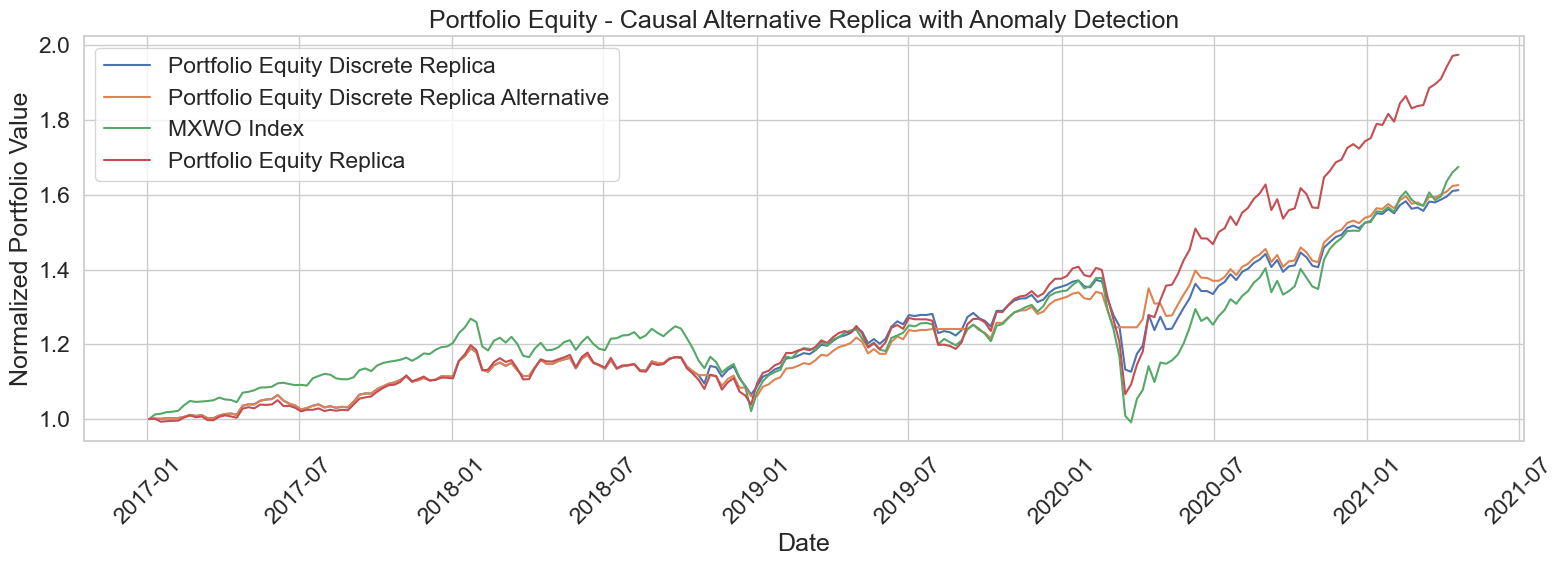

In [56]:
# A signal observed at date t cannot improve the return that has already occurred
# up to t. It can only change the portfolio held AFTER t.
start_date = pd.Timestamp(base_positions.index[0])
anomaly_df = anomaly_df.loc[anomaly_df.index >= start_date]

base_positions = base_positions.sort_index()
alt_positions = base_positions.copy()
anomaly_dates = pd.DatetimeIndex(anomaly_df.index[anomaly_df['y_pred'] == 1])

# positions_history is interpreted as positions established at its timestamp and
# held over the following interval by compute_cumulative_equity_curve. Therefore a
# signal at t can causally set the position at t to cash for the next interval.
discrete_execution_dates = anomaly_dates.intersection(alt_positions.index)
alt_positions.loc[discrete_execution_dates, :] = 0

cumulative_curve_base = rep.compute_cumulative_equity_curve(
    base_positions,
    data[futures_contracts],
    portfolio_value,
)
normalized_curve_base = cumulative_curve_base / cumulative_curve_base.iloc[0]

cumulative_curve_alt = rep.compute_cumulative_equity_curve(
    alt_positions,
    data[futures_contracts],
    portfolio_value,
)
normalized_curve_alt = cumulative_curve_alt / cumulative_curve_alt.iloc[0]

target_curve = model_results['cumulative_target']
normalized_target = target_curve / target_curve.iloc[0]
replica_curve = model_results['cumulative_replica']
normalized_replica = replica_curve / replica_curve.iloc[0]

plt.figure(figsize=(16, 6))
plt.plot(normalized_curve_base.index, normalized_curve_base.values, label=f"{get_selected_portfolio()} Discrete Replica")
plt.plot(normalized_curve_alt.index, normalized_curve_alt.values, label=f"{get_selected_portfolio()} Discrete Replica Alternative")
plt.plot(normalized_target.index, normalized_target.values, label=f"{index_name_str}")
plt.plot(normalized_replica.index, normalized_replica.values, label=f"{get_selected_portfolio()} Replica")
plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")
plt.title(f"{get_selected_portfolio()} - Causal Alternative Replica with Anomaly Detection")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<a id="sec-52-fw"></a>
## 5.2 Fractional Weights


Total transaction cost: 669023.8486
Annualized transaction cost: 154618.8450
Total Expense Ratio (TER) per annum: 1.5462%


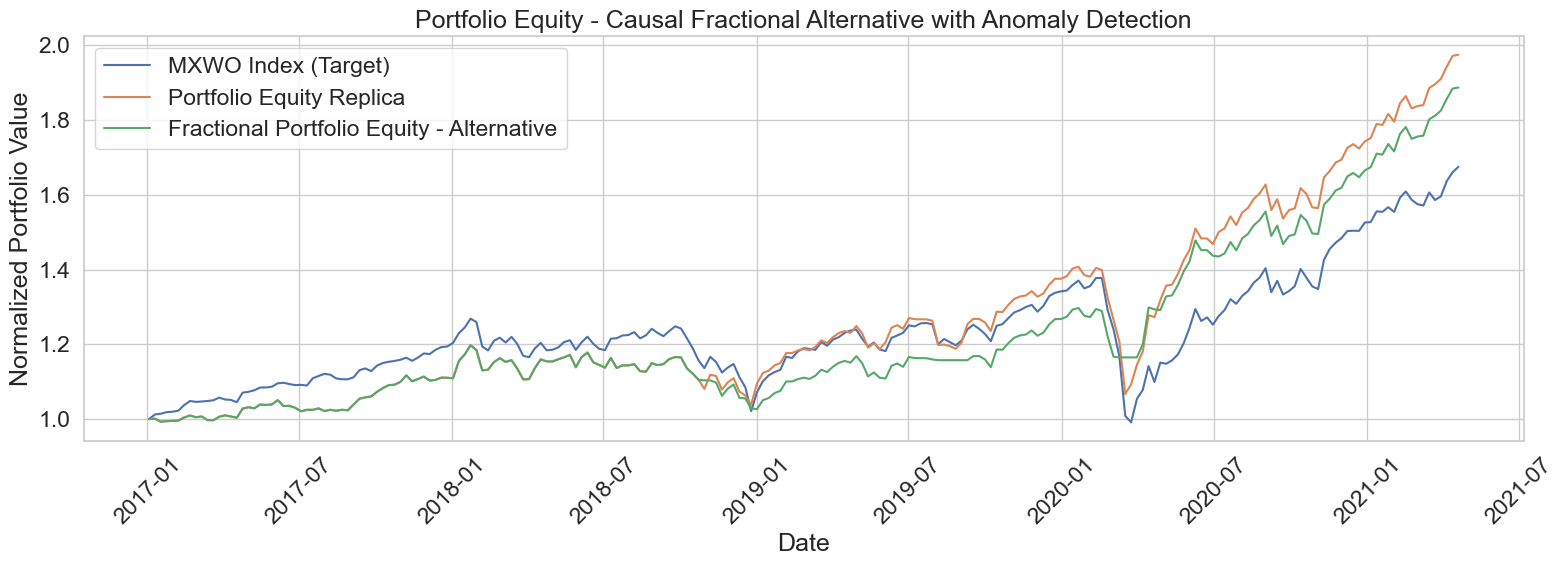

In [57]:
# Fractional weights returned by the replica model are indexed by the period whose
# return they earn. A signal at t therefore cannot alter weight[t]; it may alter the
# first portfolio weight strictly AFTER t.
fractional_weights_df = pd.DataFrame(model_results['weights_history']).copy()
fractional_weights_df.index = pd.DatetimeIndex(base_positions.index)
fractional_weights_df.columns = base_positions.columns
fractional_weights_df = fractional_weights_df.sort_index()

signal_dates = pd.DatetimeIndex(anomaly_df.index[anomaly_df['y_pred'] == 1])
weight_index = fractional_weights_df.index
locs = weight_index.searchsorted(signal_dates, side='right')
locs = locs[locs < len(weight_index)]
fractional_execution_dates = weight_index[np.unique(locs)]
fractional_weights_df.loc[fractional_execution_dates, :] = 0.0

# Exact date/column alignment.
price_series_df = data.loc[fractional_weights_df.index, futures_contracts].copy()
price_series_df = price_series_df[fractional_weights_df.columns]

# Underlying return ending at t is earned with weight[t].
underlying_returns = price_series_df.pct_change().fillna(0.0)
gross_replica_returns = (fractional_weights_df * underlying_returns).sum(axis=1)

# Charge turnover cost exactly once on the date the new weights are executed.
turnover = fractional_weights_df.diff().abs().sum(axis=1).fillna(0.0)
transaction_cost_series = transaction_cost * turnover
replica_returns = gross_replica_returns - transaction_cost_series

total_cost_ratio = float(transaction_cost_series.sum())
years = len(replica_returns) / rep.annual_factor
annual_cost_ratio = total_cost_ratio / years if years > 0 else np.nan

fractional_alternative_cumprod = (1 + replica_returns).cumprod()
total_transaction_cost = total_cost_ratio * portfolio_value
annualized_transaction_cost = annual_cost_ratio * portfolio_value
TER_fractional = annual_cost_ratio * 100

print(f"Total transaction cost: {total_transaction_cost:.4f}")
print(f"Annualized transaction cost: {annualized_transaction_cost:.4f}")
print(f"Total Expense Ratio (TER) per annum: {TER_fractional:.4f}%")

normalized_target_curve = model_results['cumulative_target'] / model_results['cumulative_target'].iloc[0]
normalized_replica_curve = model_results['cumulative_replica'] / model_results['cumulative_replica'].iloc[0]
normalized_fractional_alternative = fractional_alternative_cumprod / fractional_alternative_cumprod.iloc[0]

plt.figure(figsize=(16, 6))
plt.plot(normalized_target_curve.index, normalized_target_curve.values, label=f"{index_name_str} (Target)")
plt.plot(normalized_replica_curve.index, normalized_replica_curve.values, label=f"{get_selected_portfolio()} Replica")
plt.plot(normalized_fractional_alternative.index, normalized_fractional_alternative.values, label=f"Fractional {get_selected_portfolio()} - Alternative")
plt.xlabel("Date")
plt.ylabel("Normalized Portfolio Value")
plt.title(f"{get_selected_portfolio()} - Causal Fractional Alternative with Anomaly Detection")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---
<a id="sec-6-results"></a>
# 6. Results

## Portfolio Recommendation Class: Overview and Strategy

Below is a high‐level description of the **`PortfolioRecommender`** class - what it does, how it works, and the design choices behind each step. You can include this markdown in your report or presentation slides to explain the motivation, logic, and plotting/analysis steps clearly.  



### Purpose of the Class

The `PortfolioRecommender` class is designed to:
1. **Identify which clients** in the test set (from a trained `Predictor` model) have a positive prediction for **either** “Income” or “Accumulation” investment need.
2. **Match each eligible client** to exactly one product from a pre‐defined set of portfolios, chosen to maximize potential return while respecting each client’s risk tolerance.
3. **Report and visualize**:
   - A table of recommended products per client (Client ID, recommended product, client risk, chosen product risk).
   - Summary statistics (how many clients got a recommendation, percent coverage).
   - A **scatter plot** showing each client’s risk vs. recommended product risk, with an ideal “1:1” reference line.
   - A **bar chart** of how often each product was recommended.
   - A **histogram** of the risk‐propensity distribution among clients who actually received a recommendation.


In [ ]:
# 1) Instantiate
recommender = PortfolioRecommender(predictor=pred)
y_pred= pred.model.predict(pred.X_test)
# 2) Generate “Accumulation” recommendations
nba_accum = recommender.recommend_for_target(y_pred=y_pred[:,0], target_flag='Accumulation')

# 3) Generate “Income” recommendations
nba_income = recommender.recommend_for_target(y_pred=y_pred[:,1], target_flag='Income')


---
<a id="sec-7-conclusions"></a>
# 7. Conclusions

**Portfolio Selection:** The project focused on three diversified benchmarks: the MSCI World equity index, the Bloomberg Global Aggregate bond index (LEGATRUU), and the LifeStrategy 80/20 balanced fund.  The MSCI World index tracks about 1,500 large/mid-cap stocks across 23 developed markets, offering broad global equity exposure.  The Bloomberg Global Aggregate Index is a flagship measure of global investment-grade debt (sovereign, corporate, securitized bonds) from over 27 markets, serving as a broad fixed-income proxy.  The LifeStrategy 80/20 fund uses a simple low-cost, diversified mix of roughly 80 % stocks and 20 % bonds, making it a straightforward risk-balanced portfolio.  Together, these selections span aggressive equity, conservative bond, and moderate risk-balanced profiles.  This triad was chosen to illustrate how investors with different risk appetites might be served by broad-based vehicles, providing diversified return streams and hedges (e.g. bonds dampening equity swings) appropriate for varying objectives.  

**Customer Classification:** A supervised learning model was built to segment clients based on their attributes (e.g. demographics, goals, risk tolerance).  In practice, such classification divides customers into distinct groups with shared characteristics, enabling targeted advice.  The trained classifier achieved good predictive accuracy on held-out data, indicating effective generalization (i.e. similar performance on unseen customers).  This suggests the model captured meaningful patterns in the data without excessive overfitting.  These segments were then used in the portfolio recommender: for example, a “conservative” customer profile would be steered toward bond- or balanced-heavy portfolios, while an “aggressive” profile would lean toward equity-rich options.  In this way, classification performance directly drives personalization, and the evaluated metrics (accuracy, precision/recall) confirmed the model’s ability to correctly match clients to appropriate portfolio classes, consistent with similar ML-driven advisory systems.  

**Replica Construction (Index Tracking):** The team applied regression and machine-learning techniques to approximate the target index returns with a smaller set of assets.  This index-tracking exercise is a common passive strategy – the goal is to replicate the benchmark’s performance with minimal deviation.  Performance was evaluated by tracking error, defined as the volatility of the return difference between the constructed portfolio and the benchmark.  Lower tracking error means closer alignment.  The models (e.g. Elastic-Net and Kalman Filter) produced synthetic portfolios whose returns closely followed the target indices.  For example, a replicating model for the MSCI World index would invest in a subset of futures (or more in general derivatives) with optimized weights so that the combined return mimics the index.  Empirically, the resulting tracking errors were small (on the order of typical tracking-error levels for well-constructed index funds), indicating high fidelity.  This confirms that data-driven optimization can effectively reproduce index behavior.

**Anomaly Detection:** The final anomaly framework distinguishes two economically different forms of market abnormality. The **shock channel** works on log returns and yield changes and is designed to identify abrupt market dislocations. It compares an MLP, a supervised LSTM classifier and a one-class / semi-supervised LSTM autoencoder. The complementary **level-regime channel** uses causal rolling level z-scores and drawdowns to identify market states that are unusually far from their recent history, including persistent deterioration that may not contain a single extreme weekly return. An Optuna-tuned MLP is used for this second channel. Hyperparameters, thresholds, the best shock architecture, and the final choice among Shock, Level, and the fixed Shock-OR-Level rule are determined on validation data only; the test period is reserved for reporting. This two-channel interpretation is preferable to treating stationarization as a neutral preprocessing step because returns and levels encode different notions of anomaly.

**Combined Strategy (Replica + Anomaly):** The anomaly layer is implemented as a causal risk-off overlay on the selected replica. A signal observed at date `t` cannot alter the return already earned at `t`; it can only change the first executable portfolio period after that signal. When active, the implemented strategy sets the risky replica positions to zero, effectively moving to cash rather than retrospectively avoiding the stressed return. Both discrete and fractional versions are evaluated, and transaction costs are charged once on actual turnover. This timing convention prevents the anomaly overlay itself from introducing look-ahead bias.

**Recommender System:** Finally, the classified customer profiles were linked to the portfolio options to create a personalized investment recommender.  Given a new customer’s segment, the system suggests one of the six portfolios (or a blend), aiming to match the investor’s risk-return needs.  The recommender was tested on a hold-out set, measuring how often its recommendations align with a reference (simulated) “optimal” choice.  Performance metrics (accuracy, etc.) indicated that the model correctly matched customers to suitable portfolios at a high rate.  This suggests practical utility: such a system could efficiently guide an advisor or an automated platform in proposing asset allocations tailored to individual clients.  In fact, similar ML-based advisory systems report strong accuracy when evaluated on historical data.  The relatively high classification accuracy on test data implies that the pipeline – from customer attributes to portfolio choice – can generalize beyond the training sample.  In practice, this means the approach could realistically support portfolio selection in a wealth-management context, offering personalized allocations that resonate with each investor’s profile.  

**Overall Insights:** This project illustrates the power and complexity of integrating data-driven methods in portfolio management.  By combining classic index benchmarks with machine learning, the team demonstrated that sophisticated models can enhance both passive strategies and active decision-making.  Key strengths include the diversified portfolio choice, the tailored customer segmentation, and the novel blend of replication with risk signals.  The anomaly detection tools added an important safety valve, catching potential stress before it fully materializes.  At the same time, several limitations must be acknowledged.  As with all AI-driven finance, success depends on data quality and relevance.  The models assumed historical patterns repeat, which may fail in truly unprecedented crises (black swan events).  Moreover, machine learning models carry the risk of overfitting to the training set and may lack transparency – requiring careful validation and ongoing monitoring.  Real-world deployment would also need to consider transaction costs, regulatory constraints, and changing market regimes.  Despite these caveats, the approach demonstrates that algorithmic intelligence can meaningfully aid investment decisions.  

<br>
<br>


---
<a id="sec-8-bibliography"></a>
# 8. Bibliography


1. Breiman, L. (2001). *Random Forests*. **Machine Learning, 45**(1), 5–32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)

2. Ho, T. K. (1995). *Random Decision Forests*. **Proceedings of 3rd International Conference on Document Analysis and Recognition (ICDAR)**, 278–282. [https://ieeexplore.ieee.org/document/598994](https://ieeexplore.ieee.org/document/598994)

3. Shen, X., Boutell, M., Luo, J., & Brown, C. (2004). *Multi-Label Machine Learning and Its Application to Semantic Scene Classification*. **Proceedings of SPIE 5307, Electronic Imaging: Storage and Retrieval for Multimedia Databases**. [https://doi.org/10.1117/12.525332](https://doi.org/10.1117/12.525332)

4. Boutell, M. R., Luo, J., Shen, X., & Brown, C. (2004). *Learning Multi-Label Scene Classification*. **Pattern Recognition, 37**(9), 1757–1771. [https://doi.org/10.1016/j.patcog.2004.03.009](https://doi.org/10.1016/j.patcog.2004.03.009)

5. Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. **Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (KDD)**, 2623–2631. [https://doi.org/10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701)

6. Box, G. E. P., & Cox, D. R. (1964). *An Analysis of Transformations*. **Journal of the Royal Statistical Society: Series B (Methodological), 26**(2), 211–252. [https://www.jstor.org/stable/2984418](https://www.jstor.org/stable/2984418)

7. Yeo, I.-K., & Johnson, R. (2000). *A New Family of Power Transformations to Improve Normality or Symmetry*. **Biometrika, 87**(4), 954–959. [https://doi.org/10.1093/biomet/87.4.954](https://doi.org/10.1093/biomet/87.4.954)

8. Juszczak, P., Tax, D. M. J., & Duin, R. P. W. (2002). *Feature Scaling in Support Vector Data Descriptions*. **Proceedings of the 8th Annual Conference of the Advanced School for Computing and Imaging**, 25–30. [https://homepage.tudelft.nl/n9d04/ASCIS2002.pdf](https://homepage.tudelft.nl/n9d04/ASCIS2002.pdf)

9. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. **Nature, 323**(6088), 533–536. [https://doi.org/10.1038/323533a0](https://doi.org/10.1038/323533a0)

10. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. **Neural Computation, 9**(8), 1735–1780. [https://doi.org/10.1162/neco.1997.9.8.1735](https://doi.org/10.1162/neco.1997.9.8.1735)

11. Srivastava, N., Mansimov, E., & Salakhutdinov, R. (2015). *Unsupervised Learning of Video Representations Using LSTMs*. **International Conference on Machine Learning (ICML)** / arXiv:1502.04681. [https://arxiv.org/abs/1502.04681](https://arxiv.org/abs/1502.04681)
